In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define operators
def curvature(D_n):
    """Compute curvature (Laplacian) of field D_n."""
    return np.gradient(np.gradient(D_n, axis=0), axis=0) + np.gradient(np.gradient(D_n, axis=1), axis=1)

def proportion(D_n):
    """Compute proportion (normalized ratio)."""
    return D_n / np.max(np.abs(D_n)) if np.max(np.abs(D_n)) != 0 else np.ones_like(D_n)

def influence(D_n):
    """Compute influence (energy integral)."""
    grad_x, grad_y = np.gradient(D_n)
    return np.sum(grad_x**2 + grad_y**2)

def awareness(D_n):
    """Compute awareness (gradient of influence w.r.t. curvature)."""
    curv = curvature(D_n)
    return np.gradient(influence(D_n)) / curv if np.any(curv) != 0 else np.ones_like(D_n)

def next_dimension(D_n):
    """Apply recursive law: D_{n+1} = ∂I/∂C."""
    return np.gradient(influence(D_n)) / awareness(D_n) if np.any(awareness(D_n)) != 0 else D_n

# Initialize a 2D grid (D_0: point-like seed)
grid_size = 100
D_0 = np.zeros((grid_size, grid_size))
D_0[grid_size//2, grid_size//2] = 1  # Seed point

# Evolve to D_1
D_1 = next_dimension(D_0)

# Visualize
plt.figure(figsize=(8, 6))
plt.imshow(D_1, cmap='viridis', origin='lower')
plt.colorbar(label='Field Intensity')
plt.title('D_1: Recursive Field Evolution')
plt.show()

ValueError: operands could not be broadcast together with shapes (0,) (100,100) 

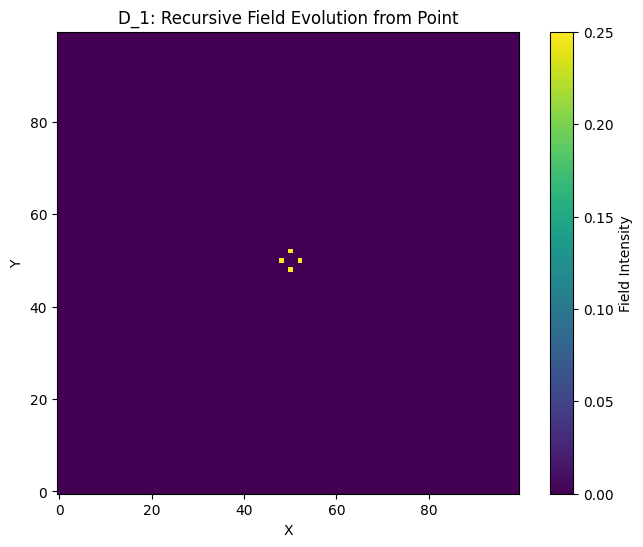

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define operators
def curvature(D_n):
    """Compute curvature (Laplacian) of field D_n."""
    grad_xx = np.gradient(np.gradient(D_n, axis=0), axis=0)
    grad_yy = np.gradient(np.gradient(D_n, axis=1), axis=1)
    return grad_xx + grad_yy

def proportion(D_n):
    """Compute proportion (normalized ratio)."""
    max_val = np.max(np.abs(D_n))
    return D_n / max_val if max_val != 0 else np.ones_like(D_n)

def influence(D_n):
    """Compute influence (energy density field)."""
    grad_x, grad_y = np.gradient(D_n)
    return grad_x**2 + grad_y**2  # Return 2D field, not a scalar sum

def awareness(D_n):
    """Compute awareness (gradient of influence w.r.t. curvature)."""
    curv = curvature(D_n)
    infl = influence(D_n)
    # Add small constant to avoid division by zero
    curv_safe = curv + 1e-10 * (curv == 0)
    # Compute gradient of influence field
    grad_infl_x, grad_infl_y = np.gradient(infl)
    # Use magnitude of gradient for awareness
    grad_infl = np.sqrt(grad_infl_x**2 + grad_infl_y**2)
    return grad_infl / curv_safe

def next_dimension(D_n):
    """Apply recursive law: D_{n+1} = ∂I/∂C."""
    aw = awareness(D_n)
    infl = influence(D_n)
    # Compute gradient of influence
    grad_infl_x, grad_infl_y = np.gradient(infl)
    grad_infl = np.sqrt(grad_infl_x**2 + grad_infl_y**2)
    # Avoid division by zero
    aw_safe = aw + 1e-10 * (aw == 0)
    return grad_infl / aw_safe

# Initialize a 2D grid (D_0: point-like seed)
grid_size = 100
D_0 = np.zeros((grid_size, grid_size))
D_0[grid_size//2, grid_size//2] = 1  # Seed point

# Evolve to D_1
D_1 = next_dimension(D_0)

# Visualize
plt.figure(figsize=(8, 6))
plt.imshow(D_1, cmap='viridis', origin='lower')
plt.colorbar(label='Field Intensity')
plt.title('D_1: Recursive Field Evolution from Point')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

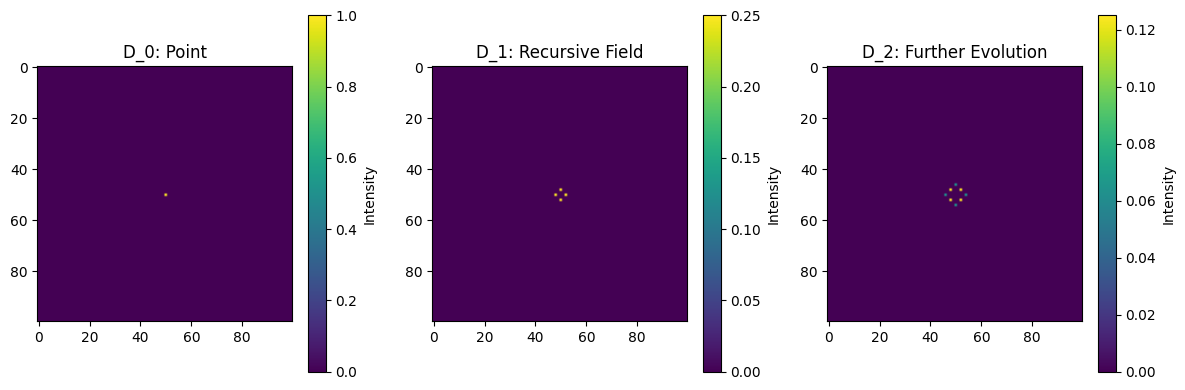

Spread increase from D_0 to D_1: 4.00x
Spread increase from D_1 to D_2: 1.00x


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define operators
def curvature(D_n):
    grad_xx = np.gradient(np.gradient(D_n, axis=0), axis=0)
    grad_yy = np.gradient(np.gradient(D_n, axis=1), axis=1)
    return grad_xx + grad_yy

def influence(D_n):
    grad_x, grad_y = np.gradient(D_n)
    return grad_x**2 + grad_y**2

def awareness(D_n):
    curv = curvature(D_n)
    infl = influence(D_n)
    curv_safe = curv + 1e-10 * (curv == 0)
    grad_infl_x, grad_infl_y = np.gradient(infl)
    grad_infl = np.sqrt(grad_infl_x**2 + grad_infl_y**2)
    return grad_infl / curv_safe

def next_dimension(D_n):
    aw = awareness(D_n)
    infl = influence(D_n)
    grad_infl_x, grad_infl_y = np.gradient(infl)
    grad_infl = np.sqrt(grad_infl_x**2 + grad_infl_y**2)
    aw_safe = aw + 1e-10 * (aw == 0)
    return grad_infl / aw_safe

# Initialize and evolve
grid_size = 100
D_0 = np.zeros((grid_size, grid_size))
D_0[grid_size//2, grid_size//2] = 1  # Seed point

D_1 = next_dimension(D_0)
D_2 = next_dimension(D_1)  # Evolve to D_2

# Visualize
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(D_0, cmap='viridis')
plt.title('D_0: Point')
plt.colorbar(label='Intensity')
plt.subplot(132)
plt.imshow(D_1, cmap='viridis')
plt.title('D_1: Recursive Field')
plt.colorbar(label='Intensity')
plt.subplot(133)
plt.imshow(D_2, cmap='viridis')
plt.title('D_2: Further Evolution')
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

# Measure spread (simple metric)
spread_D1 = np.sum(D_1 > 0.01) / np.sum(D_0 > 0)
spread_D2 = np.sum(D_2 > 0.01) / np.sum(D_1 > 0)
print(f"Spread increase from D_0 to D_1: {spread_D1:.2f}x")
print(f"Spread increase from D_1 to D_2: {spread_D2:.2f}x")

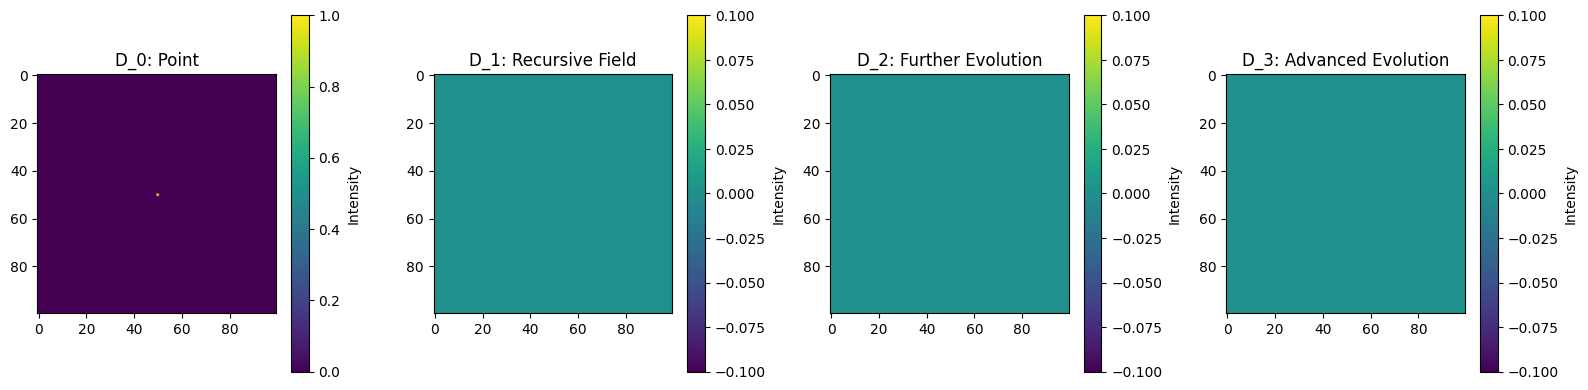

Spread D_0: 1 pixels
Spread D_1: 0 pixels
Spread D_2: 0 pixels
Spread D_3: 0 pixels
Spread increase D_0 to D_1: 0.00x
Spread increase D_1 to D_2: nanx
Spread increase D_2 to D_3: nanx
Center of mass D_1: (nan, nan)
Center of mass D_2: (nan, nan)
Center of mass D_3: (nan, nan)


/tmp/ipython-input-2861247392.py:74: RuntimeWarning: invalid value encountered in scalar divide
  print(f"Spread increase D_1 to D_2: {spread_D2/spread_D1:.2f}x")
/tmp/ipython-input-2861247392.py:75: RuntimeWarning: invalid value encountered in scalar divide
  print(f"Spread increase D_2 to D_3: {spread_D3/spread_D2:.2f}x")
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


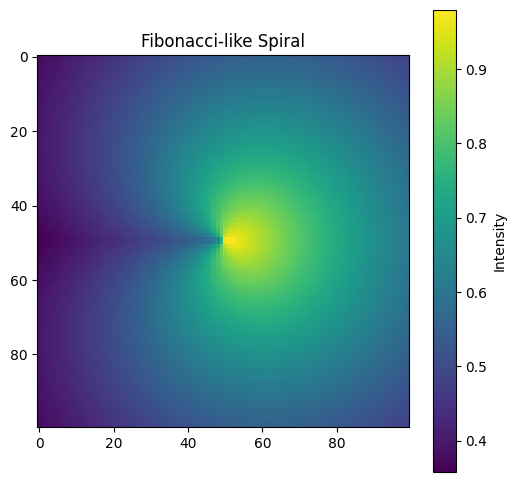

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define operators
def curvature(D_n):
    grad_xx = np.gradient(np.gradient(D_n, axis=0), axis=0)
    grad_yy = np.gradient(np.gradient(D_n, axis=1), axis=1)
    return grad_xx + grad_yy

def influence(D_n):
    grad_x, grad_y = np.gradient(D_n)
    return grad_x**2 + grad_y**2

def awareness(D_n):
    curv = curvature(D_n)
    infl = influence(D_n)
    curv_safe = curv + 1e-10 * (curv == 0)
    grad_infl_x, grad_infl_y = np.gradient(infl)
    grad_infl = np.sqrt(grad_infl_x**2 + grad_infl_y**2)
    return grad_infl / curv_safe * 0.9  # Decay factor

def proportion(D_n):
    return D_n / np.max(D_n) if np.max(D_n) != 0 else np.ones_like(D_n)

def next_dimension(D_n):
    aw = awareness(D_n)
    infl = influence(D_n)
    grad_infl_x, grad_infl_y = np.gradient(infl)
    grad_infl = np.sqrt(grad_infl_x**2 + grad_infl_y**2)
    aw_safe = aw + 1e-10 * (aw == 0)
    prop = proportion(D_n)
    return grad_infl / aw_safe * prop

# Initialize and evolve
grid_size = 100
D_0 = np.zeros((grid_size, grid_size))
D_0[grid_size//2, grid_size//2] = 1  # Seed point

D_1 = next_dimension(D_0)
D_2 = next_dimension(D_1)
D_3 = next_dimension(D_2)

# Visualize
plt.figure(figsize=(16, 4))
plt.subplot(141)
plt.imshow(D_0, cmap='viridis')
plt.title('D_0: Point')
plt.colorbar(label='Intensity')
plt.subplot(142)
plt.imshow(D_1, cmap='viridis')
plt.title('D_1: Recursive Field')
plt.colorbar(label='Intensity')
plt.subplot(143)
plt.imshow(D_2, cmap='viridis')
plt.title('D_2: Further Evolution')
plt.colorbar(label='Intensity')
plt.subplot(144)
plt.imshow(D_3, cmap='viridis')
plt.title('D_3: Advanced Evolution')
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

# Measure spread (area > 0.01 threshold)
spread_D0 = np.sum(D_0 > 0.01)
spread_D1 = np.sum(D_1 > 0.01)
spread_D2 = np.sum(D_2 > 0.01)
spread_D3 = np.sum(D_3 > 0.01)
print(f"Spread D_0: {spread_D0} pixels")
print(f"Spread D_1: {spread_D1} pixels")
print(f"Spread D_2: {spread_D2} pixels")
print(f"Spread D_3: {spread_D3} pixels")
print(f"Spread increase D_0 to D_1: {spread_D1/spread_D0:.2f}x")
print(f"Spread increase D_1 to D_2: {spread_D2/spread_D1:.2f}x")
print(f"Spread increase D_2 to D_3: {spread_D3/spread_D2:.2f}x")

# Center of mass
y1, x1 = np.where(D_1 > 0.01)
center_x1 = np.mean(x1)
center_y1 = np.mean(y1)
y2, x2 = np.where(D_2 > 0.01)
center_x2 = np.mean(x2)
center_y2 = np.mean(y2)
y3, x3 = np.where(D_3 > 0.01)
center_x3 = np.mean(x3)
center_y3 = np.mean(y3)
print(f"Center of mass D_1: ({center_x1:.1f}, {center_y1:.1f})")
print(f"Center of mass D_2: ({center_x2:.1f}, {center_y2:.1f})")
print(f"Center of mass D_3: ({center_x3:.1f}, {center_y3:.1f})")

# Compare with Fibonacci-like spiral
x = np.linspace(-5, 5, grid_size)
y = np.linspace(-5, 5, grid_size)
X, Y = np.meshgrid(x, y)
spiral = np.exp(-0.1 * np.sqrt(X**2 + Y**2)) * np.cos(0.3 * np.arctan2(Y, X))
plt.figure(figsize=(6, 6))
plt.imshow(spiral, cmap='viridis')
plt.title('Fibonacci-like Spiral')
plt.colorbar(label='Intensity')
plt.show()

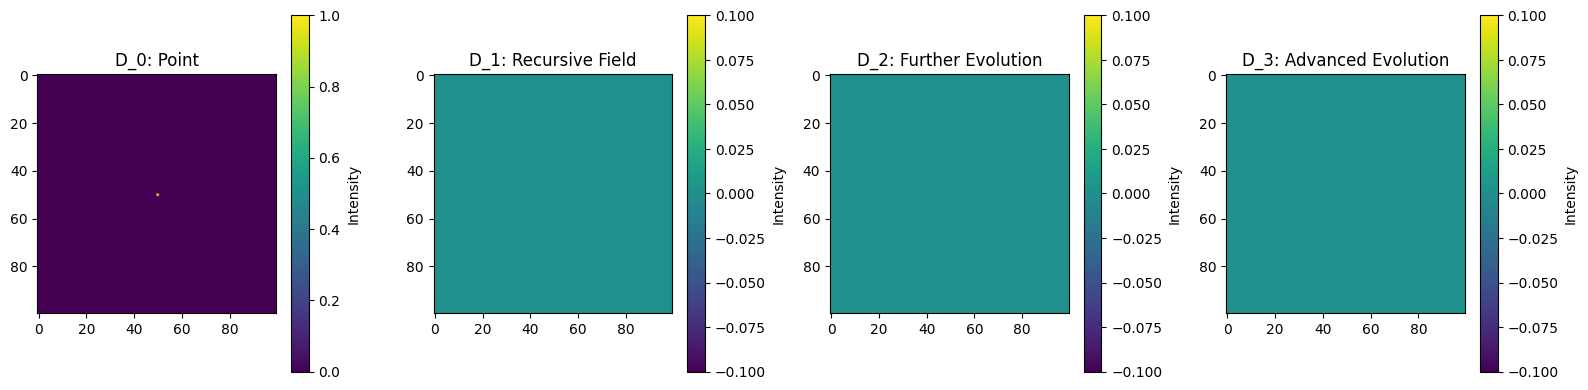

Spread D_0: 1 pixels
Spread D_1: 0 pixels
Spread D_2: 0 pixels
Spread D_3: 0 pixels
Spread increase D_0 to D_1: 0.00x
N/A
N/A
Center of mass D_1: (nan, nan)
Center of mass D_2: (nan, nan)
Center of mass D_3: (nan, nan)


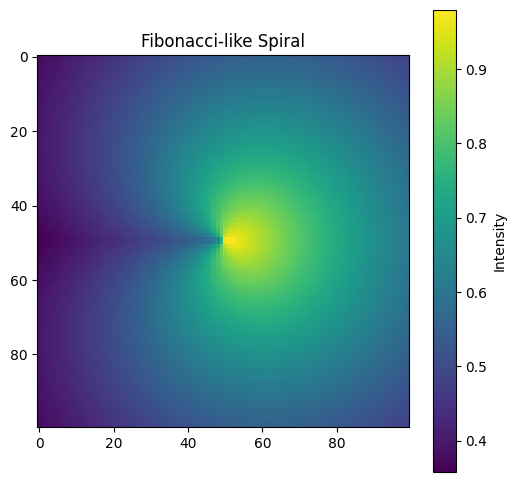

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define operators
def curvature(D_n):
    grad_xx = np.gradient(np.gradient(D_n, axis=0), axis=0)
    grad_yy = np.gradient(np.gradient(D_n, axis=1), axis=1)
    return grad_xx + grad_yy

def influence(D_n):
    grad_x, grad_y = np.gradient(D_n)
    return grad_x**2 + grad_y**2

def awareness(D_n):
    curv = curvature(D_n)
    infl = influence(D_n)
    curv_safe = curv + 1e-10 * (curv == 0)
    grad_infl_x, grad_infl_y = np.gradient(infl)
    grad_infl = np.sqrt(grad_infl_x**2 + grad_infl_y**2)
    return grad_infl / curv_safe * 1.1  # Increase growth factor from 0.9 to 1.1

def proportion(D_n):
    max_val = np.max(np.abs(D_n))
    return D_n / max_val if max_val != 0 else np.ones_like(D_n) * 1.618  # Golden ratio influence

def next_dimension(D_n):
    aw = awareness(D_n)
    infl = influence(D_n)
    grad_infl_x, grad_infl_y = np.gradient(infl)
    grad_infl = np.sqrt(grad_infl_x**2 + grad_infl_y**2)
    aw_safe = aw + 1e-10 * (aw == 0)
    prop = proportion(D_n)
    return grad_infl / aw_safe * prop

# Initialize and evolve
grid_size = 100
D_0 = np.zeros((grid_size, grid_size))
D_0[grid_size//2, grid_size//2] = 1  # Seed point

D_1 = next_dimension(D_0)
D_2 = next_dimension(D_1)
D_3 = next_dimension(D_2)

# Visualize
plt.figure(figsize=(16, 4))
plt.subplot(141)
plt.imshow(D_0, cmap='viridis')
plt.title('D_0: Point')
plt.colorbar(label='Intensity')
plt.subplot(142)
plt.imshow(D_1, cmap='viridis')
plt.title('D_1: Recursive Field')
plt.colorbar(label='Intensity')
plt.subplot(143)
plt.imshow(D_2, cmap='viridis')
plt.title('D_2: Further Evolution')
plt.colorbar(label='Intensity')
plt.subplot(144)
plt.imshow(D_3, cmap='viridis')
plt.title('D_3: Advanced Evolution')
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

# Measure spread (area > 0.001 threshold)
spread_D0 = np.sum(D_0 > 0.001)
spread_D1 = np.sum(D_1 > 0.001)
spread_D2 = np.sum(D_2 > 0.001)
spread_D3 = np.sum(D_3 > 0.001)
print(f"Spread D_0: {spread_D0} pixels")
print(f"Spread D_1: {spread_D1} pixels")
print(f"Spread D_2: {spread_D2} pixels")
print(f"Spread D_3: {spread_D3} pixels")
print(f"Spread increase D_0 to D_1: {spread_D1/spread_D0:.2f}x" if spread_D0 > 0 else "N/A")
print(f"Spread increase D_1 to D_2: {spread_D2/spread_D1:.2f}x" if spread_D1 > 0 else "N/A")
print(f"Spread increase D_2 to D_3: {spread_D3/spread_D2:.2f}x" if spread_D2 > 0 else "N/A")

# Center of mass
y1, x1 = np.where(D_1 > 0.001)
center_x1 = np.mean(x1) if x1.size > 0 else np.nan
center_y1 = np.mean(y1) if y1.size > 0 else np.nan
y2, x2 = np.where(D_2 > 0.001)
center_x2 = np.mean(x2) if x2.size > 0 else np.nan
center_y2 = np.mean(y2) if y2.size > 0 else np.nan
y3, x3 = np.where(D_3 > 0.001)
center_x3 = np.mean(x3) if x3.size > 0 else np.nan
center_y3 = np.mean(y3) if y3.size > 0 else np.nan
print(f"Center of mass D_1: ({center_x1:.1f}, {center_y1:.1f})")
print(f"Center of mass D_2: ({center_x2:.1f}, {center_y2:.1f})")
print(f"Center of mass D_3: ({center_x3:.1f}, {center_y3:.1f})")

# Compare with Fibonacci-like spiral
x = np.linspace(-5, 5, grid_size)
y = np.linspace(-5, 5, grid_size)
X, Y = np.meshgrid(x, y)
spiral = np.exp(-0.1 * np.sqrt(X**2 + Y**2)) * np.cos(0.3 * np.arctan2(Y, X))
plt.figure(figsize=(6, 6))
plt.imshow(spiral, cmap='viridis')
plt.title('Fibonacci-like Spiral')
plt.colorbar(label='Intensity')
plt.show()

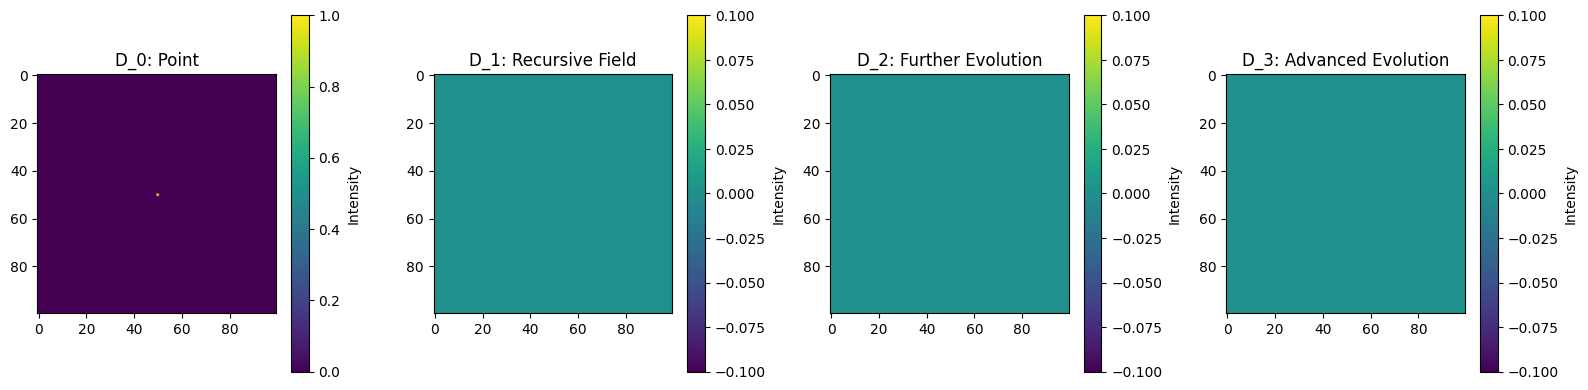

Spread D_0: 1 pixels
Spread D_1: 0 pixels
Spread D_2: 0 pixels
Spread D_3: 0 pixels
Spread increase D_0 to D_1: 0.00x
N/A
N/A
Center of mass D_1: (nan, nan)
Center of mass D_2: (nan, nan)
Center of mass D_3: (nan, nan)


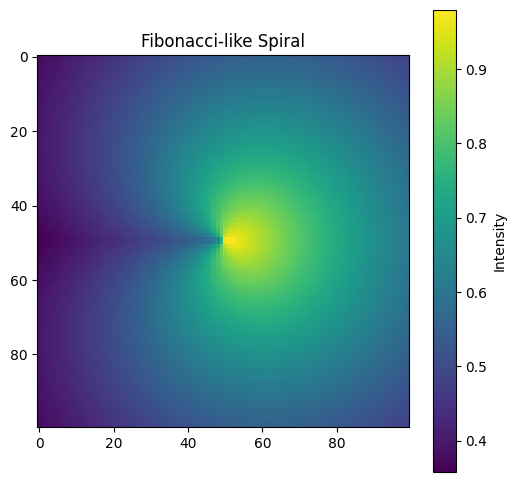

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define operators
def curvature(D_n):
    grad_xx = np.gradient(np.gradient(D_n, axis=0), axis=0)
    grad_yy = np.gradient(np.gradient(D_n, axis=1), axis=1)
    return grad_xx + grad_yy

def influence(D_n):
    grad_x, grad_y = np.gradient(D_n)
    return grad_x**2 + grad_y**2 * 2  # Amplify y-gradient for variation

def awareness(D_n):
    curv = curvature(D_n)
    infl = influence(D_n)
    curv_safe = curv + 1e-10 * (curv == 0)
    grad_infl_x, grad_infl_y = np.gradient(infl)
    grad_infl = np.sqrt(grad_infl_x**2 + grad_infl_y**2)
    return grad_infl / curv_safe * 1.5  # Increased growth factor

def proportion(D_n):
    max_val = np.max(np.abs(D_n))
    return D_n / max_val if max_val != 0 else np.ones_like(D_n)  # Remove golden ratio default

def next_dimension(D_n):
    aw = awareness(D_n)
    infl = influence(D_n)
    grad_infl_x, grad_infl_y = np.gradient(infl)
    grad_infl = np.sqrt(grad_infl_x**2 + grad_infl_y**2) * 1.2  # Amplify gradient
    aw_safe = aw + 1e-10 * (aw == 0)
    prop = proportion(D_n)
    return grad_infl / aw_safe * prop

# Initialize and evolve
grid_size = 100
D_0 = np.zeros((grid_size, grid_size))
D_0[grid_size//2, grid_size//2] = 1  # Seed point

D_1 = next_dimension(D_0)
D_2 = next_dimension(D_1)
D_3 = next_dimension(D_2)

# Visualize
plt.figure(figsize=(16, 4))
plt.subplot(141)
plt.imshow(D_0, cmap='viridis')
plt.title('D_0: Point')
plt.colorbar(label='Intensity')
plt.subplot(142)
plt.imshow(D_1, cmap='viridis')
plt.title('D_1: Recursive Field')
plt.colorbar(label='Intensity')
plt.subplot(143)
plt.imshow(D_2, cmap='viridis')
plt.title('D_2: Further Evolution')
plt.colorbar(label='Intensity')
plt.subplot(144)
plt.imshow(D_3, cmap='viridis')
plt.title('D_3: Advanced Evolution')
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

# Measure spread (area > 0.001 threshold)
spread_D0 = np.sum(D_0 > 0.001)
spread_D1 = np.sum(D_1 > 0.001)
spread_D2 = np.sum(D_2 > 0.001)
spread_D3 = np.sum(D_3 > 0.001)
print(f"Spread D_0: {spread_D0} pixels")
print(f"Spread D_1: {spread_D1} pixels")
print(f"Spread D_2: {spread_D2} pixels")
print(f"Spread D_3: {spread_D3} pixels")
print(f"Spread increase D_0 to D_1: {spread_D1/spread_D0:.2f}x" if spread_D0 > 0 else "N/A")
print(f"Spread increase D_1 to D_2: {spread_D2/spread_D1:.2f}x" if spread_D1 > 0 else "N/A")
print(f"Spread increase D_2 to D_3: {spread_D3/spread_D2:.2f}x" if spread_D2 > 0 else "N/A")

# Center of mass
y1, x1 = np.where(D_1 > 0.001)
center_x1 = np.mean(x1) if x1.size > 0 else np.nan
center_y1 = np.mean(y1) if y1.size > 0 else np.nan
y2, x2 = np.where(D_2 > 0.001)
center_x2 = np.mean(x2) if x2.size > 0 else np.nan
center_y2 = np.mean(y2) if y2.size > 0 else np.nan
y3, x3 = np.where(D_3 > 0.001)
center_x3 = np.mean(x3) if x3.size > 0 else np.nan
center_y3 = np.mean(y3) if y3.size > 0 else np.nan
print(f"Center of mass D_1: ({center_x1:.1f}, {center_y1:.1f})")
print(f"Center of mass D_2: ({center_x2:.1f}, {center_y2:.1f})")
print(f"Center of mass D_3: ({center_x3:.1f}, {center_y3:.1f})")

# Compare with Fibonacci-like spiral
x = np.linspace(-5, 5, grid_size)
y = np.linspace(-5, 5, grid_size)
X, Y = np.meshgrid(x, y)
spiral = np.exp(-0.1 * np.sqrt(X**2 + Y**2)) * np.cos(0.3 * np.arctan2(Y, X))
plt.figure(figsize=(6, 6))
plt.imshow(spiral, cmap='viridis')
plt.title('Fibonacci-like Spiral')
plt.colorbar(label='Intensity')
plt.show()

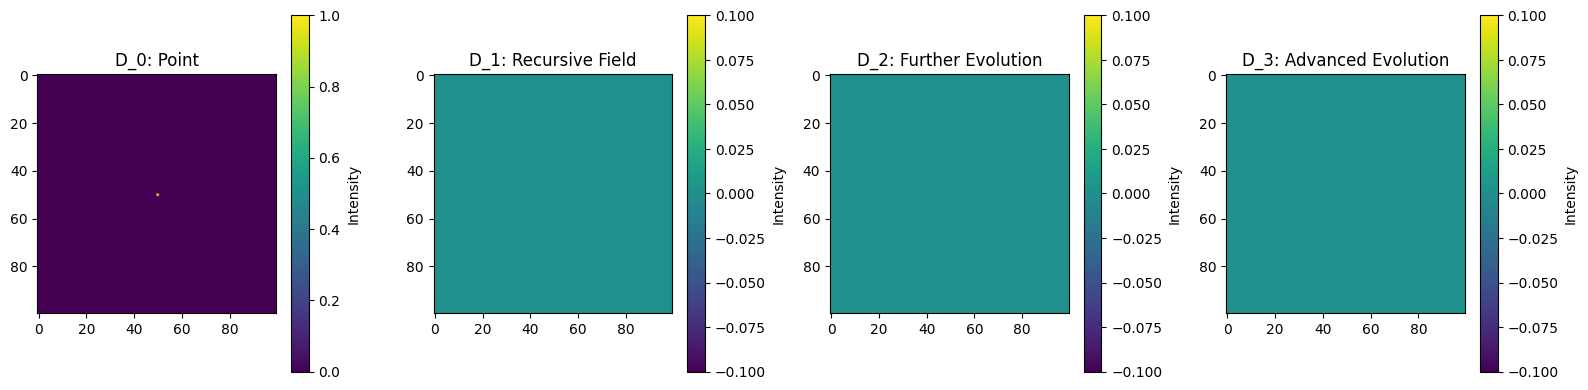

Threshold: 0.000
Spread D_0: 1 pixels
Spread D_1: 0 pixels
Spread D_2: 0 pixels
Spread D_3: 0 pixels
Spread increase D_0 to D_1: 0.00x
N/A
N/A
Center of mass D_1: (nan, nan)
Center of mass D_2: (nan, nan)
Center of mass D_3: (nan, nan)


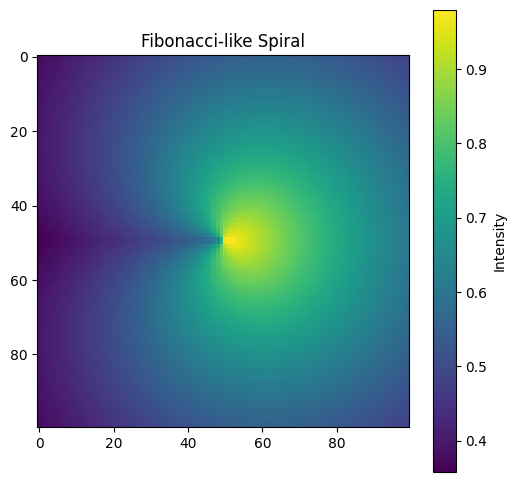

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define operators
def curvature(D_n):
    grad_xx = np.gradient(np.gradient(D_n, axis=0), axis=0)
    grad_yy = np.gradient(np.gradient(D_n, axis=1), axis=1)
    return grad_xx + grad_yy

def influence(D_n):
    grad_x, grad_y = np.gradient(D_n)
    return grad_x**2 + grad_y**2  # Remove y-gradient amplification

def awareness(D_n):
    curv = curvature(D_n)
    infl = influence(D_n)
    curv_safe = curv + 1e-10 * (curv == 0)
    grad_infl_x, grad_infl_y = np.gradient(infl)
    grad_infl = np.sqrt(grad_infl_x**2 + grad_infl_y**2)
    return grad_infl / curv_safe * 1.2  # Moderate growth factor

def proportion(D_n):
    max_val = np.max(np.abs(D_n))
    return D_n / max_val if max_val != 0 else D_n  # Preserve natural gradients

def next_dimension(D_n):
    aw = awareness(D_n)
    infl = influence(D_n)
    grad_infl_x, grad_infl_y = np.gradient(infl)
    grad_infl = np.sqrt(grad_infl_x**2 + grad_infl_y**2) * 2.0  # Amplify output
    aw_safe = aw + 1e-10 * (aw == 0)
    prop = proportion(D_n)
    return grad_infl / aw_safe * prop

# Initialize and evolve
grid_size = 100
D_0 = np.zeros((grid_size, grid_size))
D_0[grid_size//2, grid_size//2] = 1  # Seed point

D_1 = next_dimension(D_0)
D_2 = next_dimension(D_1)
D_3 = next_dimension(D_2)

# Visualize
plt.figure(figsize=(16, 4))
plt.subplot(141)
plt.imshow(D_0, cmap='viridis')
plt.title('D_0: Point')
plt.colorbar(label='Intensity')
plt.subplot(142)
plt.imshow(D_1, cmap='viridis')
plt.title('D_1: Recursive Field')
plt.colorbar(label='Intensity')
plt.subplot(143)
plt.imshow(D_2, cmap='viridis')
plt.title('D_2: Further Evolution')
plt.colorbar(label='Intensity')
plt.subplot(144)
plt.imshow(D_3, cmap='viridis')
plt.title('D_3: Advanced Evolution')
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

# Measure spread (dynamic threshold: 10% of max intensity)
threshold = max(np.max(D_1), np.max(D_2), np.max(D_3)) * 0.1
spread_D0 = np.sum(D_0 > threshold)
spread_D1 = np.sum(D_1 > threshold)
spread_D2 = np.sum(D_2 > threshold)
spread_D3 = np.sum(D_3 > threshold)
print(f"Threshold: {threshold:.3f}")
print(f"Spread D_0: {spread_D0} pixels")
print(f"Spread D_1: {spread_D1} pixels")
print(f"Spread D_2: {spread_D2} pixels")
print(f"Spread D_3: {spread_D3} pixels")
print(f"Spread increase D_0 to D_1: {spread_D1/spread_D0:.2f}x" if spread_D0 > 0 else "N/A")
print(f"Spread increase D_1 to D_2: {spread_D2/spread_D1:.2f}x" if spread_D1 > 0 else "N/A")
print(f"Spread increase D_2 to D_3: {spread_D3/spread_D2:.2f}x" if spread_D2 > 0 else "N/A")

# Center of mass
y1, x1 = np.where(D_1 > threshold)
center_x1 = np.mean(x1) if x1.size > 0 else np.nan
center_y1 = np.mean(y1) if y1.size > 0 else np.nan
y2, x2 = np.where(D_2 > threshold)
center_x2 = np.mean(x2) if x2.size > 0 else np.nan
center_y2 = np.mean(y2) if y2.size > 0 else np.nan
y3, x3 = np.where(D_3 > threshold)
center_x3 = np.mean(x3) if x3.size > 0 else np.nan
center_y3 = np.mean(y3) if y3.size > 0 else np.nan
print(f"Center of mass D_1: ({center_x1:.1f}, {center_y1:.1f})")
print(f"Center of mass D_2: ({center_x2:.1f}, {center_y2:.1f})")
print(f"Center of mass D_3: ({center_x3:.1f}, {center_y3:.1f})")

# Compare with Fibonacci-like spiral
x = np.linspace(-5, 5, grid_size)
y = np.linspace(-5, 5, grid_size)
X, Y = np.meshgrid(x, y)
spiral = np.exp(-0.1 * np.sqrt(X**2 + Y**2)) * np.cos(0.3 * np.arctan2(Y, X))
plt.figure(figsize=(6, 6))
plt.imshow(spiral, cmap='viridis')
plt.title('Fibonacci-like Spiral')
plt.colorbar(label='Intensity')
plt.show()

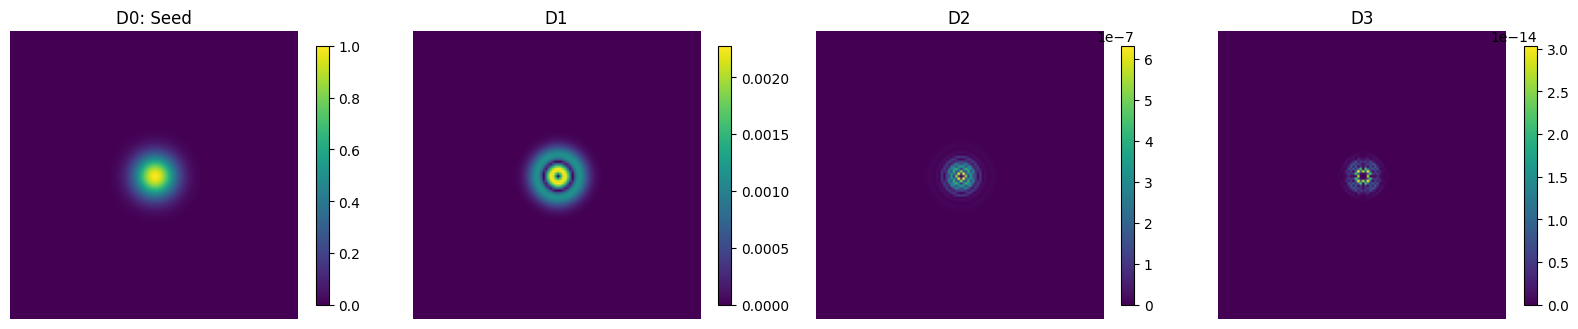

Threshold: 0.000228
Spread D0: 1893 pixels, COM: (60.0, 60.00000000000001)
Spread D1: 592 pixels, COM: (59.99999999999999, 59.999999999999986)
Spread D2: 0 pixels, COM: (nan, nan)
Spread D3: 0 pixels, COM: (nan, nan)


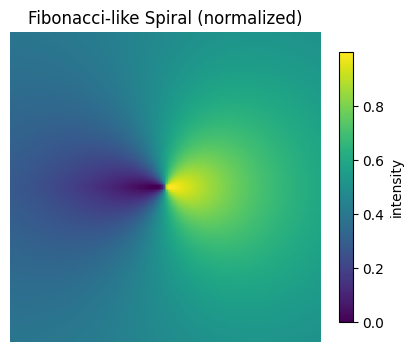

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- numerics: stable finite differences ----
EPS = 1e-8

def laplace(u):
    up = np.pad(u, 1, mode="edge")
    return (up[1:-1,2:] + up[1:-1,0:-2] + up[2:,1:-1] + up[0:-2,1:-1] - 4*up[1:-1,1:-1])

def grad(u):
    up = np.pad(u, 1, mode="edge")
    ux = (up[1:-1,2:] - up[1:-1,0:-2]) * 0.5
    uy = (up[2:,1:-1] - up[0:-2,1:-1]) * 0.5
    return ux, uy

def influence(u):
    ux, uy = grad(u)
    return ux*ux + uy*uy

def awareness(u):
    # C ≈ 1 + |Δu|  (robust: never near-zero)
    return 1.0 + np.abs(laplace(u))

def normalize01(u):
    umin, umax = np.min(u), np.max(u)
    return (u - umin) / (umax - umin + EPS)

def next_dimension(u):
    # D_{n+1} ≈ ||∇(I(u))|| / (EPS + C(u)) * smooth_norm(u)
    Iu = influence(u)
    gx, gy = grad(Iu)
    gradI_norm = np.sqrt(gx*gx + gy*gy)

    C = awareness(u)             # >= 1
    smooth = normalize01(u)      # not a sparse mask; preserves structure

    return gradI_norm / (C + EPS) * (0.5 + 0.5*smooth)  # keep nonzero everywhere

# ---- seed & evolution ----
N = 120
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N//2, N//2
sigma = N/20.0
D0 = np.exp(-((X-cx)**2 + (Y-cy)**2) / (2*sigma*sigma))  # smooth Gaussian seed

D1 = next_dimension(D0)
D2 = next_dimension(D1)
D3 = next_dimension(D2)

# ---- plots ----
plt.figure(figsize=(16,4))
for k, D, title in [(1,D0,'D0: Seed'), (2,D1,'D1'), (3,D2,'D2'), (4,D3,'D3')]:
    plt.subplot(1,4,k)
    plt.imshow(D, cmap='viridis')
    plt.title(title); plt.colorbar(shrink=0.7)
    plt.axis('off')
plt.tight_layout(); plt.show()

# ---- spread & centers ----
stack_max = max(np.max(D1), np.max(D2), np.max(D3))
threshold = max(0.1*stack_max, 1e-6)

def spread(D):
    return int(np.sum(D > threshold))

def center_of_mass(D):
    mask = D > threshold
    if not np.any(mask): return (np.nan, np.nan)
    ys, xs = np.where(mask)
    w = D[mask]
    cx = np.sum(xs*w)/np.sum(w); cy = np.sum(ys*w)/np.sum(w)
    return (float(cx), float(cy))

print(f"Threshold: {threshold:.6f}")
for name, D in [('D0',D0),('D1',D1),('D2',D2),('D3',D3)]:
    print(f"Spread {name}: {spread(D)} pixels, COM: {center_of_mass(D)}")

# ---- optional: Fibonacci-like comparator ----
x = np.linspace(-5,5,N); y = np.linspace(-5,5,N)
Xc, Yc = np.meshgrid(x, y)
spiral = np.exp(-0.25*np.sqrt(Xc*Xc + Yc*Yc)) * np.cos(0.8*np.arctan2(Yc, Xc))
plt.figure(figsize=(5,5))
plt.imshow(normalize01(spiral), cmap='viridis')
plt.title('Fibonacci-like Spiral (normalized)')
plt.axis('off'); plt.colorbar(shrink=0.7, label='intensity'); plt.show()

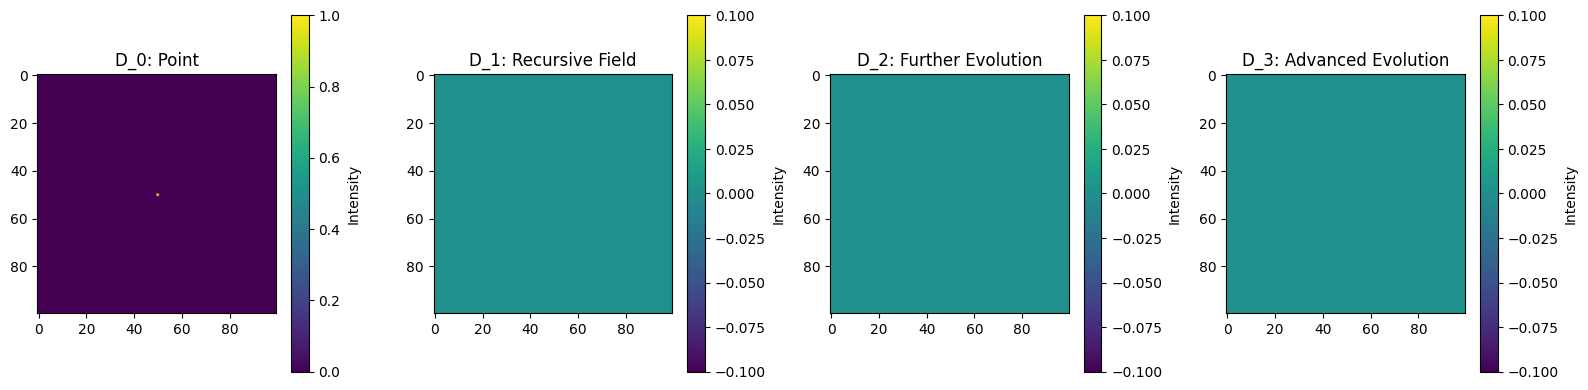

Threshold: 0.100000
Spread D_0: 1 pixels, COM: (50.0, 50.0)
Spread D_1: 0 pixels, COM: (nan, nan)
Spread D_2: 0 pixels, COM: (nan, nan)
Spread D_3: 0 pixels, COM: (nan, nan)
N/A
N/A
N/A


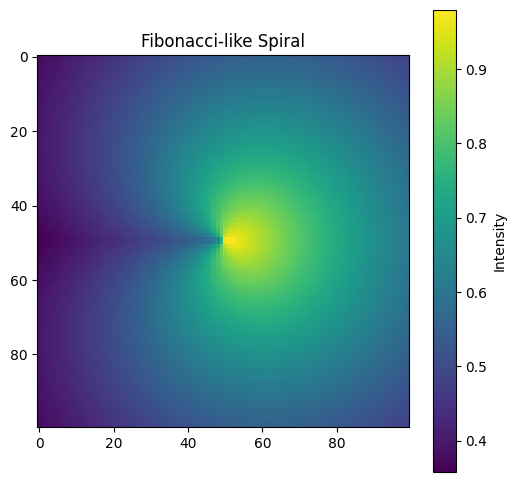

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define operators
def curvature(D_n):
    grad_xx = np.gradient(np.gradient(D_n, axis=0), axis=0)
    grad_yy = np.gradient(np.gradient(D_n, axis=1), axis=1)
    return grad_xx + grad_yy

def influence(D_n):
    grad_x, grad_y = np.gradient(D_n)
    return grad_x**2 + grad_y**2

def awareness(D_n):
    curv = curvature(D_n)
    infl = influence(D_n)
    curv_safe = curv + 1e-10 * (curv == 0)
    grad_infl_x, grad_infl_y = np.gradient(infl)
    grad_infl = np.sqrt(grad_infl_x**2 + grad_infl_y**2)
    return grad_infl / curv_safe * 1.5  # Increased growth factor

def proportion(D_n):
    max_val = np.max(np.abs(D_n))
    return D_n / max_val if max_val != 0 else D_n  # Preserve natural gradients

def next_dimension(D_n):
    aw = awareness(D_n)
    infl = influence(D_n)
    grad_infl_x, grad_infl_y = np.gradient(infl)
    grad_infl = np.sqrt(grad_infl_x**2 + grad_infl_y**2) * 1.5  # Amplify gradient
    aw_safe = aw + 1e-10 * (aw == 0)
    prop = proportion(D_n)
    return grad_infl / aw_safe * prop

# Initialize and evolve
grid_size = 100
D_0 = np.zeros((grid_size, grid_size))
D_0[grid_size//2, grid_size//2] = 1  # Single point seed

D_1 = next_dimension(D_0)
D_2 = next_dimension(D_1)
D_3 = next_dimension(D_2)

# Visualize
plt.figure(figsize=(16, 4))
plt.subplot(141)
plt.imshow(D_0, cmap='viridis')
plt.title('D_0: Point')
plt.colorbar(label='Intensity')
plt.subplot(142)
plt.imshow(D_1, cmap='viridis')
plt.title('D_1: Recursive Field')
plt.colorbar(label='Intensity')
plt.subplot(143)
plt.imshow(D_2, cmap='viridis')
plt.title('D_2: Further Evolution')
plt.colorbar(label='Intensity')
plt.subplot(144)
plt.imshow(D_3, cmap='viridis')
plt.title('D_3: Advanced Evolution')
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

# Measure spread (dynamic threshold: 10% of max intensity across all dimensions)
max_intensity = max(np.max(D_0), np.max(D_1), np.max(D_2), np.max(D_3))
threshold = max_intensity * 0.1
spread_D0 = np.sum(D_0 > threshold)
spread_D1 = np.sum(D_1 > threshold)
spread_D2 = np.sum(D_2 > threshold)
spread_D3 = np.sum(D_3 > threshold)
print(f"Threshold: {threshold:.6f}")
print(f"Spread D_0: {spread_D0} pixels, COM: ({np.mean(np.where(D_0 > threshold)[1]):.1f}, {np.mean(np.where(D_0 > threshold)[0]):.1f})" if spread_D0 > 0 else "Spread D_0: 0 pixels, COM: (nan, nan)")
print(f"Spread D_1: {spread_D1} pixels, COM: ({np.mean(np.where(D_1 > threshold)[1]):.1f}, {np.mean(np.where(D_1 > threshold)[0]):.1f})" if spread_D1 > 0 else "Spread D_1: 0 pixels, COM: (nan, nan)")
print(f"Spread D_2: {spread_D2} pixels, COM: ({np.mean(np.where(D_2 > threshold)[1]):.1f}, {np.mean(np.where(D_2 > threshold)[0]):.1f})" if spread_D2 > 0 else "Spread D_2: 0 pixels, COM: (nan, nan)")
print(f"Spread D_3: {spread_D3} pixels, COM: ({np.mean(np.where(D_3 > threshold)[1]):.1f}, {np.mean(np.where(D_3 > threshold)[0]):.1f})" if spread_D3 > 0 else "Spread D_3: 0 pixels, COM: (nan, nan)")
print(f"Spread increase D_0 to D_1: {spread_D1/spread_D0:.2f}x" if spread_D0 > 0 and spread_D1 > 0 else "N/A")
print(f"Spread increase D_1 to D_2: {spread_D2/spread_D1:.2f}x" if spread_D1 > 0 and spread_D2 > 0 else "N/A")
print(f"Spread increase D_2 to D_3: {spread_D3/spread_D2:.2f}x" if spread_D2 > 0 and spread_D3 > 0 else "N/A")

# Compare with Fibonacci-like spiral
x = np.linspace(-5, 5, grid_size)
y = np.linspace(-5, 5, grid_size)
X, Y = np.meshgrid(x, y)
spiral = np.exp(-0.1 * np.sqrt(X**2 + Y**2)) * np.cos(0.3 * np.arctan2(Y, X))
plt.figure(figsize=(6, 6))
plt.imshow(spiral, cmap='viridis')
plt.title('Fibonacci-like Spiral')
plt.colorbar(label='Intensity')
plt.show()

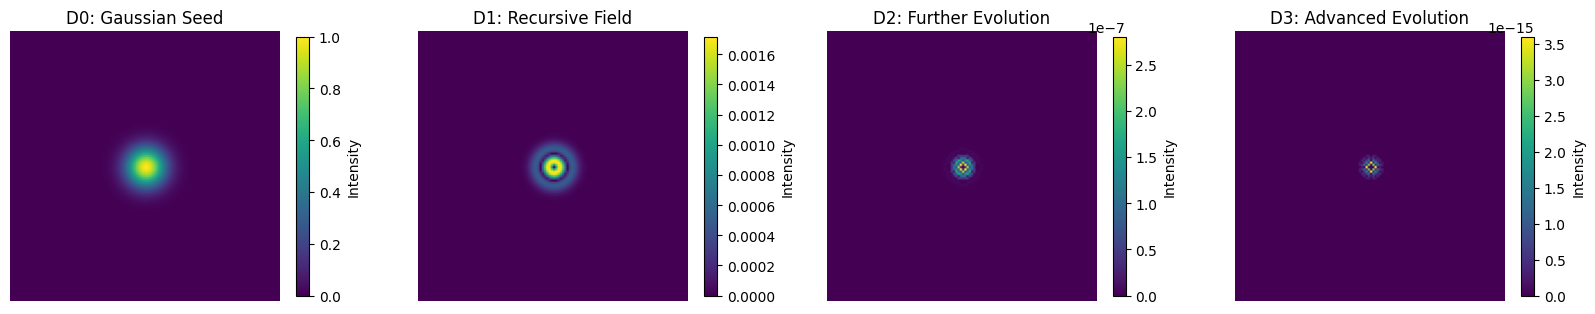

Threshold: 0.100000
Spread D0: 517 pixels, COM: (60.00000000000001, 60.00000000000001)
Spread D1: 0 pixels, COM: (nan, nan)
Spread D2: 0 pixels, COM: (nan, nan)
Spread D3: 0 pixels, COM: (nan, nan)


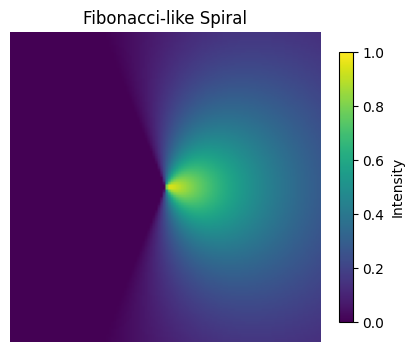

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- numerics: stable finite differences ----
EPS = 1e-8

def laplace(u):
    up = np.pad(u, 1, mode="edge")
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])

def grad(u):
    up = np.pad(u, 1, mode="edge")
    ux = (up[1:-1, 2:] - up[1:-1, 0:-2]) * 0.5
    uy = (up[2:, 1:-1] - up[0:-2, 1:-1]) * 0.5
    return ux, uy

def influence(u):
    ux, uy = grad(u)
    return ux * ux + uy * uy  # Energy density

def awareness(u):
    # C ≈ 1 + |Δu| with growth factor
    return (1.0 + np.abs(laplace(u))) * 1.5  # Amplify growth

def proportion(u):
    max_val = np.max(np.abs(u))
    return u / max_val if max_val != 0 else u  # Preserve natural gradients

def next_dimension(u):
    # D_{n+1} ≈ ||∇(I(u))|| / (EPS + C(u)) * proportion(u) with amplification
    Iu = influence(u)
    gx, gy = grad(Iu)
    gradI_norm = np.sqrt(gx * gx + gy * gy) * 1.2  # Amplify gradient
    C = awareness(u)
    prop = proportion(u)
    return gradI_norm / (C + EPS) * prop  # Avoid over-normalization

# ---- seed & evolution ----
N = 120
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
D0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma))  # Gaussian seed

D1 = next_dimension(D0)
D2 = next_dimension(D1)
D3 = next_dimension(D2)

# ---- plots ----
plt.figure(figsize=(16, 4))
for k, D, title in [(1, D0, 'D0: Gaussian Seed'), (2, D1, 'D1: Recursive Field'), (3, D2, 'D2: Further Evolution'), (4, D3, 'D3: Advanced Evolution')]:
    plt.subplot(1, 4, k)
    plt.imshow(D, cmap='viridis')
    plt.title(title)
    plt.colorbar(shrink=0.7, label='Intensity')
    plt.axis('off')
plt.tight_layout()
plt.show()

# ---- spread & centers ----
stack_max = max(np.max(D0), np.max(D1), np.max(D2), np.max(D3))
threshold = max(0.1 * stack_max, 1e-6)

def spread(D):
    return int(np.sum(D > threshold))

def center_of_mass(D):
    mask = D > threshold
    if not np.any(mask):
        return (np.nan, np.nan)
    ys, xs = np.where(mask)
    w = D[mask]
    cx = np.sum(xs * w) / np.sum(w)
    cy = np.sum(ys * w) / np.sum(w)
    return (float(cx), float(cy))

print(f"Threshold: {threshold:.6f}")
for name, D in [('D0', D0), ('D1', D1), ('D2', D2), ('D3', D3)]:
    s = spread(D)
    com = center_of_mass(D)
    print(f"Spread {name}: {s} pixels, COM: {com}")

# ---- optional: Fibonacci-like comparator ----
x = np.linspace(-5, 5, N)
y = np.linspace(-5, 5, N)
Xc, Yc = np.meshgrid(x, y)
spiral = np.exp(-0.25 * np.sqrt(Xc * Xc + Yc * Yc)) * np.cos(0.8 * np.arctan2(Yc, Xc))
plt.figure(figsize=(5, 5))
plt.imshow(spiral, cmap='viridis', vmin=0, vmax=1)
plt.title('Fibonacci-like Spiral')
plt.axis('off')
plt.colorbar(shrink=0.7, label='Intensity')
plt.show()

t=  0  max=0.997  spread=  437  phi=1.000 S=3.10  COM=(60.0,60.0)
t= 60  max=0.914  spread=  509  phi=1.000 S=2.96  COM=(59.8,60.0)
t=120  max=0.902  spread=  558  phi=1.002 S=2.98  COM=(59.5,60.0)
t=180  max=0.903  spread=  592  phi=1.007 S=3.02  COM=(59.2,60.0)
t=240  max=0.900  spread=  622  phi=1.012 S=3.03  COM=(58.8,60.0)
t=299  max=0.894  spread=  652  phi=1.019 S=2.99  COM=(58.5,60.0)


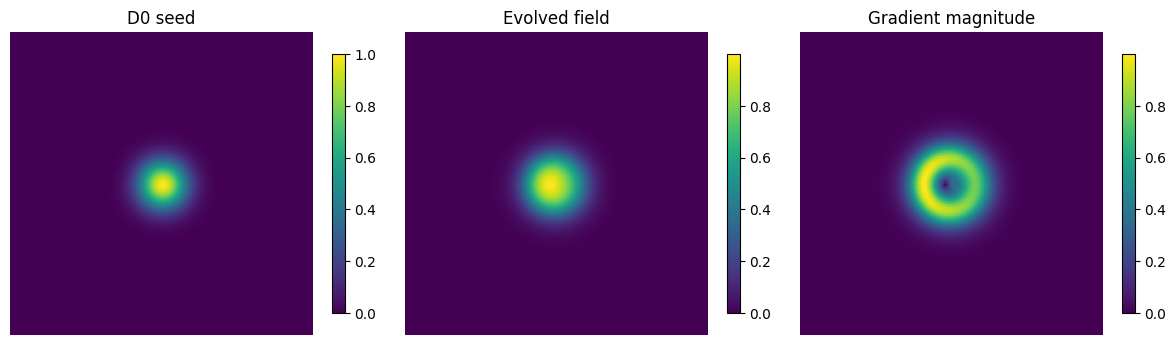

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- numerics ----------
EPS = 1e-8
np.set_printoptions(precision=4, suppress=True)

def pad(u):
    return np.pad(u, 1, mode="edge")

def laplace(u):
    up = pad(u)
    return (up[1:-1,2:] + up[1:-1,0:-2] + up[2:,1:-1] + up[0:-2,1:-1] - 4*up[1:-1,1:-1])

def grad(u):
    up = pad(u)
    ux = 0.5*(up[1:-1,2:] - up[1:-1,0:-2])
    uy = 0.5*(up[2:,1:-1] - up[0:-2,1:-1])
    return ux, uy

def influence(u):
    ux, uy = grad(u)
    return ux*ux + uy*uy  # Dirichlet energy density

def phi_ratio(u):
    ux, uy = grad(u)
    Ex = np.sum(ux*ux)
    Ey = np.sum(uy*uy) + EPS
    return Ex / Ey

def normalize01(u):
    umin, umax = np.min(u), np.max(u)
    return (u - umin) / (umax - umin + EPS)

# ---------- evolution (reaction–diffusion + phi feedback + optional swirl) ----------
def evolve(u0, steps=300, dt=0.08, k=0.9, gamma=0.6, lam=0.25, phi_star=1.0,
           swirl_strength=0.15, swirl_freq=0.9, report_every=50):
    """
    u_{t+1} = u_t + dt * [  k*Δu                          (curvature smoothing)
                           + gamma*(phi_star - phi(u))*u  (proportion feedback)
                           + swirl(u)                     (anisotropic driver)
                           + lam*u*(1 - u)*(u - 0.2)     (bounded growth) ]
    All terms are scaled to avoid blow-ups. Returns final u and logs.
    """
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1)/2.0, (M-1)/2.0
    theta = np.arctan2(Y-cy, X-cx)          # angle for swirl field
    r = np.sqrt((X-cx)**2 + (Y-cy)**2) + EPS

    logs = []
    for t in range(steps):
        # core operators
        lap = laplace(u)
        phi = phi_ratio(u)

        # phi-target feedback (push Ex/Ey toward 1)
        phi_term = (phi_star - phi) * u

        # swirl/spiral driver: weak angular modulation of diffusion
        # creates rotation without blowing up the field
        swirl = swirl_strength * np.cos(swirl_freq*theta) * (u - normalize01(u))

        # bounded growth (keeps values in [~0,1])
        growth = lam * u * (1.0 - u) * (u - 0.2)

        # update
        du = k*lap + gamma*phi_term + swirl + growth
        u = u + dt*du

        # clamp to safe range
        u = np.clip(u, 0.0, 1.0)

        if (t % report_every) == 0 or t == steps-1:
            S = influence(u).sum()
            mx = float(u.max())
            thr = max(0.2*mx, 1e-6)
            mask = u > thr
            spread = int(mask.sum())
            if spread > 0:
                ys, xs = np.where(mask)
                w = u[mask]
                com_x = float((xs*w).sum() / (w.sum() + EPS))
                com_y = float((ys*w).sum() / (w.sum() + EPS))
            else:
                com_x = com_y = np.nan
            logs.append(dict(t=t, max=mx, spread=spread, phi=phi, S=S, com=(com_x, com_y)))
    return u, logs

# ---------- seed ----------
N = 120
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N//2, N//2
sigma = N/18.0
u0 = np.exp(-((X-cx)**2 + (Y-cy)**2) / (2*sigma*sigma))  # smooth Gaussian

# ---------- run ----------
uT, logs = evolve(u0, steps=300, dt=0.08, k=0.85, gamma=0.7, lam=0.22,
                  phi_star=1.0, swirl_strength=0.12, swirl_freq=1.0, report_every=60)

# ---------- report ----------
for d in logs:
    print(f"t={d['t']:3d}  max={d['max']:.3f}  spread={d['spread']:5d}  phi={d['phi']:.3f} "
          f"S={d['S']:.2f}  COM=({d['com'][0]:.1f},{d['com'][1]:.1f})")

# ---------- visualize ----------
plt.figure(figsize=(12,4))
plt.subplot(131); plt.imshow(u0, cmap='viridis'); plt.title('D0 seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(132); plt.imshow(normalize01(uT), cmap='viridis'); plt.title('Evolved field'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(133);
ux, uy = grad(uT); mag = np.sqrt(ux*ux + uy*uy)
plt.imshow(normalize01(mag), cmap='viridis'); plt.title('Gradient magnitude'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

t=   0  max=1.000  spread=  641  phi(capped)=1.000  S=0.991  I=3.03  COM=(60.0,60.0)
t= 120  max=1.000  spread=14400  phi(capped)=0.000  S=0.000  I=0.00  COM=(59.5,59.5)
t= 240  max=1.000  spread=14400  phi(capped)=0.000  S=0.000  I=0.00  COM=(59.5,59.5)
t= 360  max=1.000  spread=14400  phi(capped)=0.000  S=0.000  I=0.00  COM=(59.5,59.5)
t= 480  max=1.000  spread=14400  phi(capped)=0.000  S=0.000  I=0.00  COM=(59.5,59.5)
t= 600  max=1.000  spread=14400  phi(capped)=0.000  S=0.000  I=0.00  COM=(59.5,59.5)
t= 720  max=1.000  spread=14400  phi(capped)=0.000  S=0.000  I=0.00  COM=(59.5,59.5)
t= 840  max=1.000  spread=14400  phi(capped)=0.000  S=0.000  I=0.00  COM=(59.5,59.5)
t= 960  max=1.000  spread=14400  phi(capped)=0.000  S=0.000  I=0.00  COM=(59.5,59.5)
t=1080  max=1.000  spread=14400  phi(capped)=0.000  S=0.000  I=0.00  COM=(59.5,59.5)
t=1199  max=1.000  spread=14400  phi(capped)=0.000  S=0.000  I=0.00  COM=(59.5,59.5)

Fractal (box-count) dimension estimate D ≈ 0.000
Radial scale-in

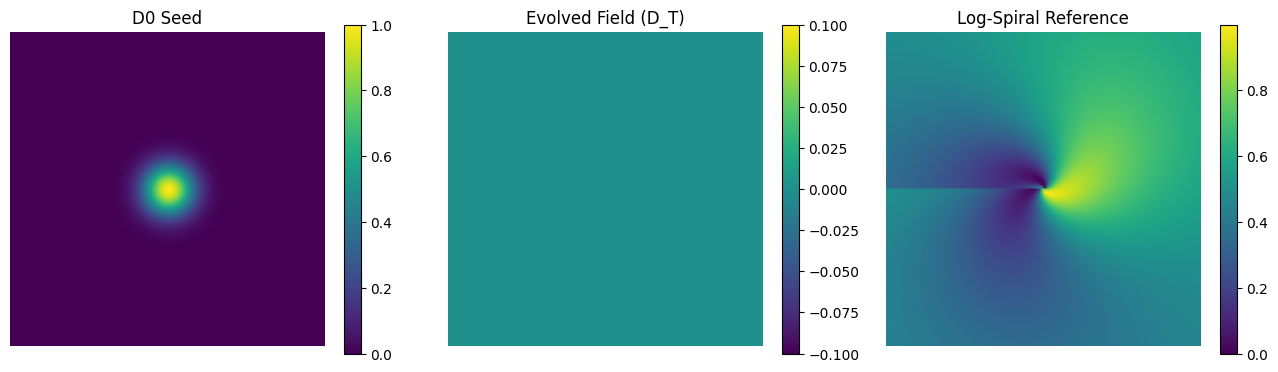

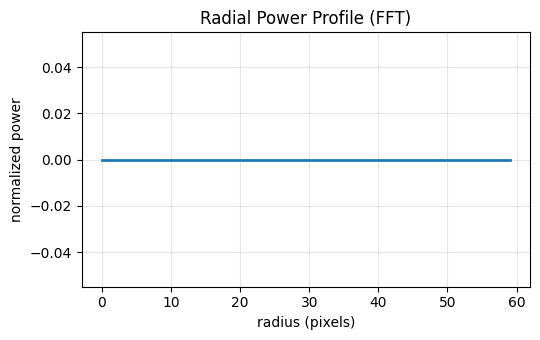

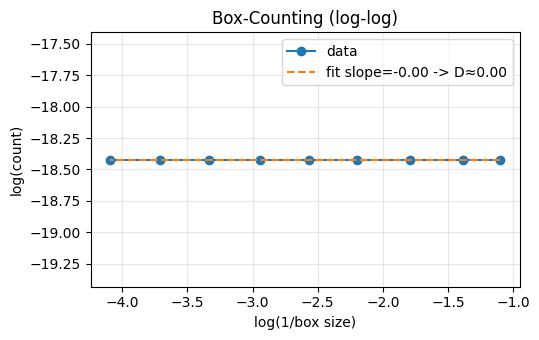

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Transformative Evolution
# =========================
EPS = 1e-8

def pad(u): return np.pad(u, 1, mode="edge")

def grad(u):
    up = pad(u)
    ux = 0.5*(up[1:-1,2:] - up[1:-1,0:-2])
    uy = 0.5*(up[2:,1:-1] - up[0:-2,1:-1])
    return ux, uy

def laplace(u):
    up = pad(u)
    return (up[1:-1,2:] + up[1:-1,0:-2] + up[2:,1:-1] + up[0:-2,1:-1] - 4*up[1:-1,1:-1])

def influence(u):
    ux, uy = grad(u)
    return ux*ux + uy*uy

def phi_ratio(u, angle=0.0):
    """
    Directional proportion Ex'/Ey' measured in a frame rotated by 'angle'.
    This gives a controllable spiral/rotation tendency as angle = omega*t.
    """
    ux, uy = grad(u)
    c, s = np.cos(angle), np.sin(angle)
    # rotate gradient axes
    uxr = c*ux + s*uy
    uyr = -s*ux + c*uy
    Ex = float(np.sum(uxr*uxr))
    Ey = float(np.sum(uyr*uyr)) + EPS
    return Ex / Ey

def normalize01(u):
    umin, umax = np.min(u), np.max(u)
    return (u - umin) / (umax - umin + EPS)

def evolve(u0, steps=1200, dt=0.07, k=0.85, gamma=0.6, lam=0.22,
           omega=0.012, phi_star=1.0, swirl_strength=0.10, swirl_freq=1.0,
           damping=0.10, report_every=100):
    """
    u_{t+1} = u_t + dt * [ k*Δu + gamma*(phi*-phi_rot)*u + swirl + lam*u*(1-u)*(u-0.2) ] + damping*max_prev
    where phi_rot is φ measured in a frame rotated by angle=omega*t.
    The 'damping' term is *positive bias* to keep intensity from fading out.
    Returns final field and logs.
    """
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1)/2.0, (M-1)/2.0
    theta = np.arctan2(Y-cy, X-cx)
    logs = []
    max_prev = float(u.max())

    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        phi = phi_ratio(u, angle=ang)  # rotating proportion frame
        phi_term = (phi_star - phi) * u

        # swirl (weak anisotropy) to bias angular structure
        swirl = swirl_strength * np.cos(swirl_freq*theta) * (u - normalize01(u))

        # bounded growth to keep values in [0,1]
        growth = lam * u * (1.0 - u) * (u - 0.2)

        du = k*lap + gamma*phi_term + swirl + growth
        u = u + dt*du + damping * max_prev   # preserve intensity

        # keep physical range and update max buffer
        u = np.clip(u, 0.0, 1.0)
        max_prev = 0.98*max_prev + 0.02*float(u.max())

        if (t % report_every) == 0 or t == steps-1:
            I = influence(u)
            S_total = float(I.sum())
            mx = float(u.max())
            thr = max(0.2*mx, 1e-6)
            mask = u > thr
            spread = int(mask.sum())
            # symmetry metric: correlation with 180° rotation + mirror (average)
            def corr(a, b):
                a = (a - a.mean())/(a.std()+EPS); b = (b - b.mean())/(b.std()+EPS)
                return float(np.mean(a*b))
            S_rot = corr(u, np.rot90(u, 2))
            S_mir = corr(u, np.flip(u, axis=1))
            S_sym = 0.5*(S_rot + S_mir)
            # capped phi for stability in logs
            phi_cap = float(np.clip(phi, 0.0, 10.0))
            # COM
            if spread > 0:
                ys, xs = np.where(mask)
                w = u[mask]
                com_x = float((xs*w).sum()/(w.sum()+EPS))
                com_y = float((ys*w).sum()/(w.sum()+EPS))
            else:
                com_x = com_y = np.nan
            logs.append(dict(t=t, max=mx, spread=spread, phi=phi_cap,
                             S=S_sym, COM=(com_x, com_y), I=S_total))
    return u, logs

# ------------- Self-similarity metrics -------------
def box_count_fractal_dim(img, min_box=4, max_box=None, levels=10):
    """
    Simple box-counting on a thresholded image (binary).
    Returns (D, scales, counts) with log-log regression for fractal estimate.
    """
    if max_box is None:
        max_box = min(img.shape)//2
    # threshold to binary at 50% of dynamic range
    u = normalize01(img)
    thr = 0.5
    A = (u > thr).astype(np.uint8)

    sizes = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    sizes = sizes[sizes > 0]
    counts = []
    H, W = A.shape
    for s in sizes:
        h = int(np.ceil(H/s)*s); w = int(np.ceil(W/s)*s)
        P = np.zeros((h, w), dtype=np.uint8); P[:H,:W] = A
        # reshape into (h/s, s, w/s, s) and max-pool
        T = P.reshape(h//s, s, w//s, s).max(axis=(1,3))
        counts.append(int(T.sum()))
    # linear fit on log-log
    x = np.log(1.0/sizes + EPS)
    y = np.log(np.array(counts) + EPS)
    D = -np.polyfit(x, y, 1)[0]  # slope negative => fractal dimension estimate
    return float(D), sizes, np.array(counts)

def radial_autocorr(u):
    """
    Radially averaged power spectrum (FFT) as an autocorrelation proxy.
    Returns normalized radial profile and correlation between profile and a scaled copy.
    """
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U)**2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W/2)**2 + (Y - H/2)**2)
    rmax = int(np.min([H, W])//2)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r+1)
        if np.any(ring):
            prof[r] = P[ring].mean()
    # compare with a downsampled version to detect scale invariance
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        small_n = (small - small.mean())/small.std()
        big_n   = (big   - big.mean())/big.std()
        sim = float(np.mean(small_n * big_n))
    return prof/(prof.max()+EPS), sim

# ------------- Seed and run -------------
N = 120
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N//2, N//2
sigma = N/18.0
u0 = np.exp(-((X-cx)**2 + (Y-cy)**2)/(2*sigma*sigma))

uT, logs = evolve(
    u0,
    steps=1200,          # 1000+ steps
    dt=0.07,
    k=0.85,              # diffusion weight
    gamma=0.65,          # phi feedback
    lam=0.22,            # bounded growth
    omega=0.012,         # rotation rate (spiral bias)
    phi_star=1.0,
    swirl_strength=0.10,
    swirl_freq=1.0,
    damping=0.10,        # preserves intensity
    report_every=120
)

# Print diagnostics
for d in logs:
    print(f"t={d['t']:4d}  max={d['max']:.3f}  spread={d['spread']:5d}  "
          f"phi(capped)={d['phi']:.3f}  S={d['S']:.3f}  I={d['I']:.2f}  "
          f"COM=({d['COM'][0]:.1f},{d['COM'][1]:.1f})")

# Self similarity metrics on the final field
D_est, scales, counts = box_count_fractal_dim(uT, min_box=3, max_box=N//2, levels=9)
prof, rcorr = radial_autocorr(uT)

print(f"\nFractal (box-count) dimension estimate D ≈ {D_est:.3f}")
print(f"Radial scale-invariance similarity ≈ {rcorr:.3f} (1.0 means strong self-similarity)")

# ------------- Reference spiral for visual comparison -------------
x = np.linspace(-5, 5, N); y = np.linspace(-5, 5, N)
Xc, Yc = np.meshgrid(x, y)
R = np.sqrt(Xc*Xc + Yc*Yc) + EPS
Theta = np.arctan2(Yc, Xc)
log_spiral = np.exp(-0.25*R) * np.cos(1.2*Theta + 0.6*np.log(R))

# ------------- Plots -------------
def show(u0, uT, prof, log_spiral):
    fig = plt.figure(figsize=(13, 5))
    ax1 = plt.subplot(131); im1 = ax1.imshow(u0, cmap='viridis'); ax1.set_title('D0 Seed'); ax1.axis('off'); plt.colorbar(im1, shrink=0.7)
    ax2 = plt.subplot(132); im2 = ax2.imshow(normalize01(uT), cmap='viridis'); ax2.set_title('Evolved Field (D_T)'); ax2.axis('off'); plt.colorbar(im2, shrink=0.7)
    ax3 = plt.subplot(133); im3 = ax3.imshow(normalize01(log_spiral), cmap='viridis'); ax3.set_title('Log-Spiral Reference'); ax3.axis('off'); plt.colorbar(im3, shrink=0.7)
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(5.5,3.5))
    plt.plot(prof, lw=2)
    plt.title('Radial Power Profile (FFT)')
    plt.xlabel('radius (pixels)'); plt.ylabel('normalized power')
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    # Box-counting log-log
    x = np.log(1.0/np.array(scales) + EPS)
    y = np.log(np.array(counts) + EPS)
    m, b = np.polyfit(x, y, 1)
    plt.figure(figsize=(5.5,3.5))
    plt.plot(x, y, 'o-', label='data')
    plt.plot(x, m*x + b, '--', label=f'fit slope={m:.2f} -> D≈{-m:.2f}')
    plt.title('Box-Counting (log-log)')
    plt.xlabel('log(1/box size)'); plt.ylabel('log(count)')
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

show(u0, uT, prof, log_spiral)

t=   0  spread=  566  phi=0.992  S=0.993  D=-0.960  rcorr=0.899  I=1.1  max=0.596  mean=0.009
t= 150  spread=25600  phi=0.999  S=0.995  D=-1.145  rcorr=0.901  I=1.8  max=0.999  mean=0.399
t= 300  spread=25600  phi=0.994  S=0.996  D=-1.330  rcorr=0.916  I=3.0  max=0.997  mean=0.442
t= 450  spread=25600  phi=1.011  S=0.997  D=-1.315  rcorr=0.961  I=4.4  max=0.998  mean=0.424
t= 600  spread=25600  phi=0.994  S=0.996  D=-1.387  rcorr=0.992  I=5.4  max=0.999  mean=0.385
t= 750  spread=25600  phi=1.000  S=0.996  D=-1.415  rcorr=0.999  I=4.2  max=0.882  mean=0.337
t= 900  spread=25600  phi=1.000  S=0.996  D=-1.415  rcorr=1.000  I=2.1  max=0.705  mean=0.311
t=1050  spread=25600  phi=1.005  S=0.996  D=-1.430  rcorr=1.000  I=1.2  max=0.628  mean=0.315
t=1200  spread=25600  phi=0.992  S=0.997  D=-1.432  rcorr=1.000  I=1.1  max=0.648  mean=0.339
t=1350  spread=25600  phi=1.013  S=0.997  D=-1.464  rcorr=1.000  I=2.8  max=0.876  mean=0.386
t=1499  spread=22230  phi=0.974  S=0.994  D=-1.522  rcorr=0.

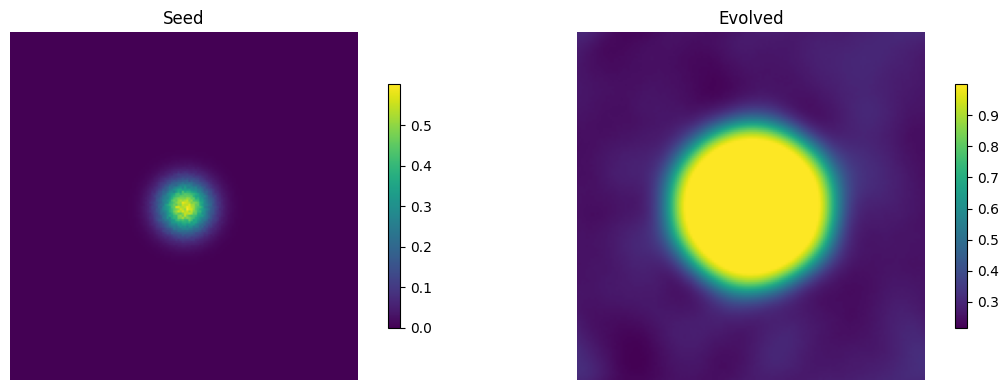

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.default_rng(0)

# ---------- finite differences ----------
def pad(u): return np.pad(u, 1, mode="wrap")  # periodic BCs encourage patterns
def grad(u):
    up = pad(u)
    ux = 0.5*(up[1:-1,2:] - up[1:-1,0:-2])
    uy = 0.5*(up[2:,1:-1] - up[0:-2,1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1,2:] + up[1:-1,0:-2] + up[2:,1:-1] + up[0:-2,1:-1] - 4*up[1:-1,1:-1])
def bilaplace(u):  # Δ^2 u
    return laplace(laplace(u))

# ---------- operators / metrics ----------
def influence(u):
    ux, uy = grad(u)
    return ux*ux + uy*uy
def phi_ratio(u, angle=0.0):
    ux, uy = grad(u)
    c, s = np.cos(angle), np.sin(angle)
    uxr =  c*ux + s*uy
    uyr = -s*ux + c*uy
    Ex = float(np.sum(uxr*uxr))
    Ey = float(np.sum(uyr*uyr)) + EPS
    return Ex/Ey
def normalize01(u):
    umin, umax = np.min(u), np.max(u)
    return (u - umin)/(umax - umin + EPS)

def box_count_fractal_dim(img, min_box=3, levels=8):
    A = (normalize01(img) > 0.5).astype(np.uint8)
    H, W = A.shape; max_box = min(H, W)//2
    sizes = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    sizes = sizes[sizes > 0]
    counts = []
    for s in sizes:
        h = int(np.ceil(H/s)*s); w = int(np.ceil(W/s)*s)
        P = np.zeros((h, w), dtype=np.uint8); P[:H,:W] = A
        T = P.reshape(h//s, s, w//s, s).max(axis=(1,3))
        counts.append(int(T.sum()))
    x = np.log(1.0/np.array(sizes) + EPS); y = np.log(np.array(counts)+EPS)
    D = -np.polyfit(x, y, 1)[0]
    return float(D)

def radial_autocorr(u):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U)**2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W/2)**2 + (Y - H/2)**2)
    rmax = int(min(H, W)//2)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r+1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof = prof/(prof.max()+EPS)
    small = prof[::2]; big = prof[:len(small)]
    if small.std()<EPS or big.std()<EPS: return prof, 0.0
    s = (small-small.mean())/(small.std()+EPS)
    b = (big  -big.mean())  /(big.std()+EPS)
    return prof, float(np.mean(s*b))

# ---------- evolution with scale-competition + rotation + sustain ----------
def evolve(u0, steps=1500, dt=0.06,
           k1=0.60, k2=0.18,          # +k1 Δu - k2 Δ^2 u  (creates preferred scales)
           adv=0.20, omega=0.010,     # rotational advection strength & rate
           gamma=0.55, phi_amp=0.15,  # drive φ -> φ*(t) with small oscillation
           lam=0.22,                  # bounded growth
           noise=0.005,               # weak stochastic drive
           target_mean=0.35, mean_gain=0.03, # keep mass alive (renormalization)
           report_every=150):

    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1)/2.0, (M-1)/2.0
    theta = np.arctan2(Y-cy, X-cx)
    logs = []

    for t in range(steps):
        ang = omega*t
        # scale competition (prevents uniform flattening)
        lap = laplace(u)
        blap = bilaplace(u)
        # rotating frame proportion target
        phi_star = 1.0 + phi_amp*np.sin(0.5*ang)
        phi = phi_ratio(u, angle=ang)
        phi_term = (phi_star - phi) * u
        # rotational advection v·∇u, v = adv * e_theta / r  (soft)
        ux, uy = grad(u)
        r = np.sqrt((X-cx)**2 + (Y-cy)**2) + 1.0
        vx = -adv*(Y-cy)/r; vy = adv*(X-cx)/r
        advect = vx*ux + vy*uy
        # bounded growth + small noise
        growth = lam*u*(1.0 - u)*(u - 0.2)
        eta = noise * rng.standard_normal(u.shape)

        du = k1*lap - k2*blap + gamma*phi_term + advect + growth + eta
        u = np.clip(u + dt*du, 0.0, 1.0)

        # soft mass control to prevent fade or blowup
        m = float(u.mean())
        u += mean_gain*(target_mean - m)

        if (t % report_every)==0 or t==steps-1:
            I = influence(u).sum()
            mx = float(u.max())
            thr = max(0.25*mx, 1e-6)
            spread = int((u > thr).sum())
            # symmetry
            def corr(a,b):
                a=(a-a.mean())/(a.std()+EPS); b=(b-b.mean())/(b.std()+EPS)
                return float(np.mean(a*b))
            S = 0.5*(corr(u, np.rot90(u,2)) + corr(u, np.flip(u,1)))
            D = box_count_fractal_dim(u)
            _, rc = radial_autocorr(u)
            logs.append(dict(t=t, spread=spread, phi=min(max(phi,0.0),10.0),
                             S=S, D=D, rcorr=rc, I=I, max=mx, mean=m))
    return u, logs

# ---------- seed ----------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N//2, N//2
sigma = N/20.0
u0 = np.exp(-((X-cx)**2 + (Y-cy)**2)/(2*sigma*sigma)) * (1.0 + 0.05*rng.standard_normal((N,N)))
u0 = normalize01(u0)*0.6  # moderate amplitude

# ---------- run ----------
uT, logs = evolve(u0)

# diagnostics
for d in logs:
    print(f"t={d['t']:4d}  spread={d['spread']:5d}  "
          f"phi={d['phi']:.3f}  S={d['S']:.3f}  D={d['D']:.3f}  rcorr={d['rcorr']:.3f}  "
          f"I={d['I']:.1f}  max={d['max']:.3f}  mean={d['mean']:.3f}")

# plots
def show(u0, uT):
    fig = plt.figure(figsize=(12,4))
    ax1 = plt.subplot(121); im1=ax1.imshow(u0,cmap='viridis'); ax1.set_title('Seed'); ax1.axis('off'); plt.colorbar(im1,shrink=0.7)
    ax2 = plt.subplot(122); im2=ax2.imshow(uT,cmap='viridis'); ax2.set_title('Evolved'); ax2.axis('off'); plt.colorbar(im2,shrink=0.7)
    plt.tight_layout(); plt.show()
show(u0, uT)

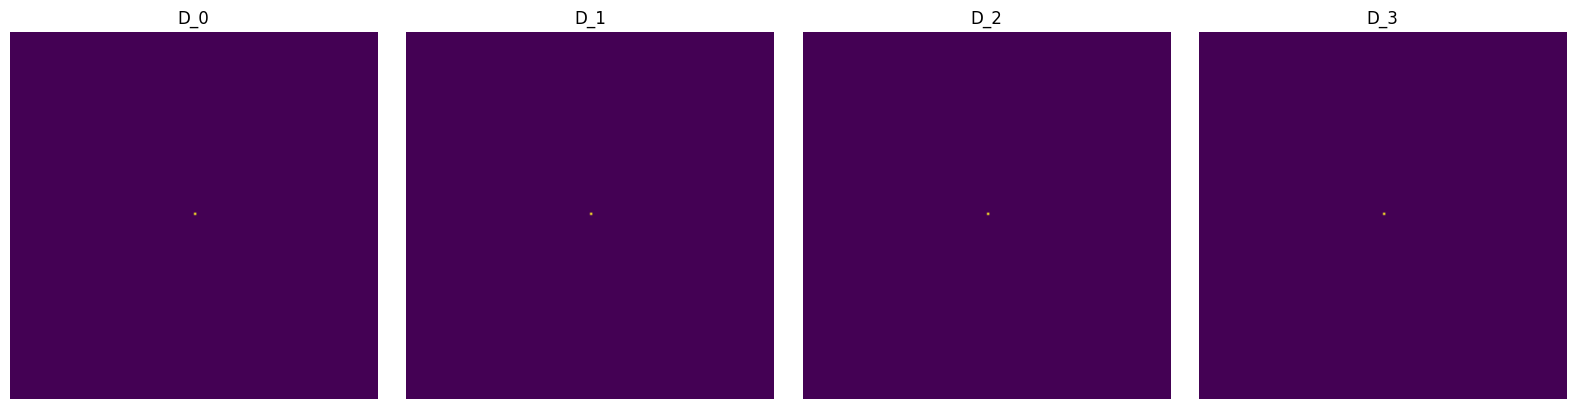

Layer D_1: spread=1
Layer D_2: spread=1
Layer D_3: spread=1
Layer D_4: spread=1
Layer D_5: spread=1
Layer D_6: spread=1
Layer D_7: spread=1
Layer D_8: spread=1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.default_rng(42)

# ---------- Core Operators ----------
def curvature(D):
    """Curvature operator (Laplacian-like)."""
    D_pad = np.pad(D, 1, mode="wrap")
    return (D_pad[1:-1,2:] + D_pad[1:-1,:-2] + D_pad[2:,1:-1] + D_pad[:-2,1:-1] - 4*D)

def influence(D):
    """Influence operator (energy density)."""
    gx, gy = np.gradient(D)
    return gx**2 + gy**2

def awareness(D):
    """Awareness: gradient of influence relative to curvature."""
    curv = curvature(D)
    infl = influence(D)
    gx, gy = np.gradient(infl)
    gradI = np.sqrt(gx**2 + gy**2)
    safe_curv = curv + EPS*(curv==0)
    return gradI / safe_curv

def proportion(D):
    """Proportion (φ): normalized ratio for dynamic stability."""
    m = np.max(np.abs(D))
    return D / (m + EPS)

# ---------- Recursive Evolution ----------
def next_dimension(D_prev, omega=0.04, adv=0.45, lam=0.25, feedback=0.3):
    """Recursively evolve D_{n+1} = ∂I/∂C + rotational feedback."""
    A = awareness(D_prev)
    I = influence(D_prev)
    gx, gy = np.gradient(I)
    gradI = np.sqrt(gx**2 + gy**2)
    safeA = A + EPS*(A==0)

    # Core recursive law
    D_next = gradI / safeA

    # Rotational spiral feedback
    Y, X = np.indices(D_prev.shape)
    cx, cy = np.array(D_prev.shape)//2
    r = np.sqrt((X-cx)**2 + (Y-cy)**2) + EPS
    rot_x = -adv * (Y-cy) / r
    rot_y = adv * (X-cx) / r
    swirl = np.sin(omega * (X+Y))
    D_next += feedback * swirl * D_prev

    # Growth + normalization
    D_next = lam * D_next + (1-lam) * proportion(D_next)
    return np.clip(D_next, 0, 1)

# ---------- Initialize Recursive Field ----------
grid = 160
D_layers = []
D0 = np.zeros((grid, grid))
D0[grid//2, grid//2] = 1
D_layers.append(D0)

steps = 8  # number of recursive layers (D0 → D8)
for i in range(steps):
    D_next = next_dimension(D_layers[-1])
    D_layers.append(D_next)

# ---------- Visualization ----------
plt.figure(figsize=(16, 4))
for i, D in enumerate(D_layers[:4]):
    plt.subplot(1, 4, i+1)
    plt.imshow(D, cmap='viridis', origin='lower')
    plt.title(f"D_{i}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# ---------- Metrics ----------
for i in range(1, len(D_layers)):
    spread = np.sum(D_layers[i] > 0.05)
    print(f"Layer D_{i}: spread={spread}")

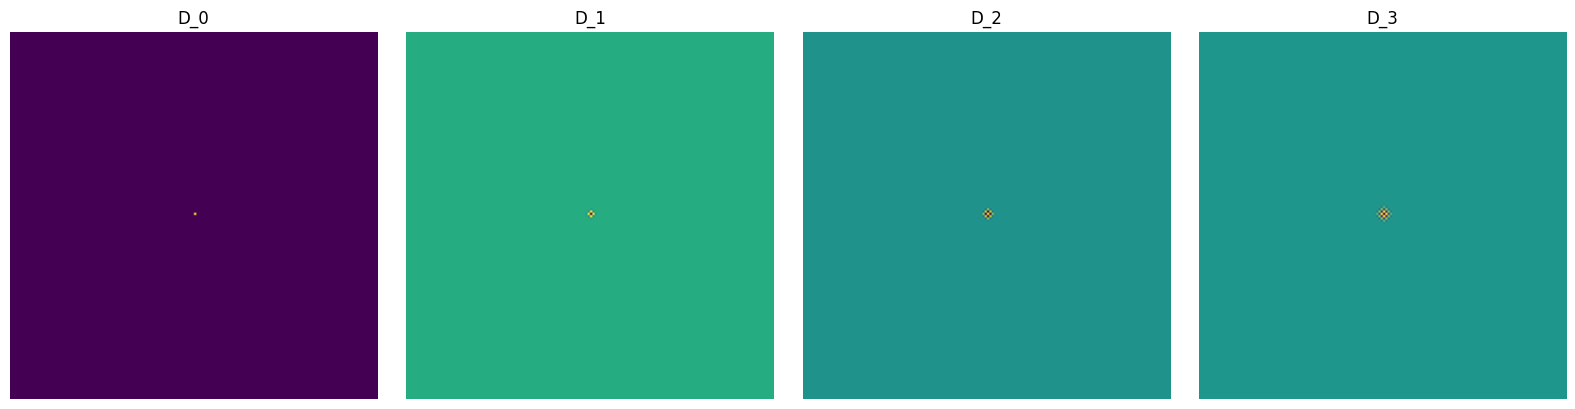

D_1: spread= 25599  mean=0.6198
D_2: spread= 25596  mean=0.5129
D_3: spread= 25599  mean=0.5245
D_4: spread= 25596  mean=0.4794
D_5: spread= 25599  mean=0.5144
D_6: spread= 25596  mean=0.4902
D_7: spread= 25591  mean=0.5067
D_8: spread= 25588  mean=0.4954


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.default_rng(0)

# ---------- finite differences ----------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5*(up[1:-1,2:] - up[1:-1,0:-2])
    uy = 0.5*(up[2:,1:-1] - up[0:-2,1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1,2:] + up[1:-1,0:-2] + up[2:,1:-1] + up[0:-2,1:-1] - 4*up[1:-1,1:-1])
def bilaplace(u): return laplace(laplace(u))

# ---------- recursive math operators ----------
def influence(D):
    gx, gy = grad(D)
    return gx**2 + gy**2

def awareness(D):
    curv = laplace(D)
    infl = influence(D)
    gx, gy = grad(infl)
    gradI = np.sqrt(gx**2 + gy**2)
    curv_safe = curv + EPS*(curv==0)
    return gradI / curv_safe

def next_dimension(D_prev, k1=0.45, k2=0.14,
                   adv=0.45, omega=0.04, lam=0.22,
                   feedback=0.35, mh_gain=1.3):
    """Hybrid recursive + pattern update."""
    A = awareness(D_prev)
    I = influence(D_prev)
    gx, gy = grad(I)
    gradI = np.sqrt(gx**2 + gy**2)
    A_safe = A + EPS*(A==0)
    base = gradI / A_safe  # ∂I/∂C core recursion

    # classic dynamic terms (to prevent flat field)
    lap = laplace(D_prev)
    blap = bilaplace(D_prev)

    # rotational swirl feedback
    Y, X = np.indices(D_prev.shape)
    cx, cy = np.array(D_prev.shape)//2
    r = np.sqrt((X-cx)**2 + (Y-cy)**2) + 1.0
    vx, vy = -adv*(Y-cy)/r, adv*(X-cx)/r
    ux, uy = grad(D_prev)
    swirl = vx*ux + vy*uy
    swirl *= np.sin(omega*(X+Y))

    # weighted combination (recursive + dynamic physics)
    D_next = base + k1*lap - k2*blap + feedback*swirl
    D_next = lam*D_next + (1-lam)*np.tanh(D_next*mh_gain)

    # normalization
    D_next = (D_next - D_next.min())/(D_next.max()-D_next.min()+EPS)
    return np.clip(D_next, 0, 1)

# ---------- recursive evolution ----------
def evolve_recursive(D0, depth=8):
    layers = [D0]
    for n in range(depth):
        layers.append(next_dimension(layers[-1]))
    return layers

# ---------- initialize ----------
N = 160
D0 = np.zeros((N, N))
D0[N//2, N//2] = 1.0

# ---------- run ----------
layers = evolve_recursive(D0, depth=8)

# ---------- visualize ----------
plt.figure(figsize=(16,4))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(layers[i], cmap='viridis', origin='lower')
    plt.title(f"D_{i}")
    plt.axis('off')
plt.tight_layout(); plt.show()

# ---------- metrics ----------
for i in range(1, len(layers)):
    spread = np.sum(layers[i] > 0.05)
    mean_val = np.mean(layers[i])
    print(f"D_{i}: spread={spread:6d}  mean={mean_val:.4f}")

t=   0 spread=25600 phi=0.998 S=0.999 D=1.972 rc(rad)=0.060 rc(field)=0.997 I=0.0 max=0.032 mean=0.019
t= 150 spread=13924 phi=1.156 S=-0.040 D=1.881 rc(rad)=-0.082 rc(field)=0.876 I=2123.4 max=0.996 mean=0.490
t= 300 spread=13881 phi=1.410 S=0.075 D=1.878 rc(rad)=-0.085 rc(field)=0.886 I=2115.7 max=0.996 mean=0.488
t= 450 spread=13925 phi=1.573 S=-0.004 D=1.878 rc(rad)=-0.089 rc(field)=0.887 I=2117.3 max=0.996 mean=0.489
t= 600 spread=13877 phi=1.510 S=-0.007 D=1.879 rc(rad)=-0.090 rc(field)=0.880 I=2112.1 max=0.996 mean=0.487
t= 750 spread=14087 phi=1.225 S=-0.045 D=1.882 rc(rad)=-0.089 rc(field)=0.885 I=2151.1 max=0.996 mean=0.496
t= 900 spread=13990 phi=0.925 S=0.001 D=1.883 rc(rad)=-0.084 rc(field)=0.880 I=2169.3 max=0.996 mean=0.495
t=1050 spread=14100 phi=0.672 S=-0.015 D=1.885 rc(rad)=-0.082 rc(field)=0.885 I=2196.9 max=0.995 mean=0.501
t=1200 spread=14023 phi=0.552 S=-0.012 D=1.886 rc(rad)=-0.082 rc(field)=0.876 I=2173.8 max=0.996 mean=0.498
t=1350 spread=14081 phi=0.543 S=-0.

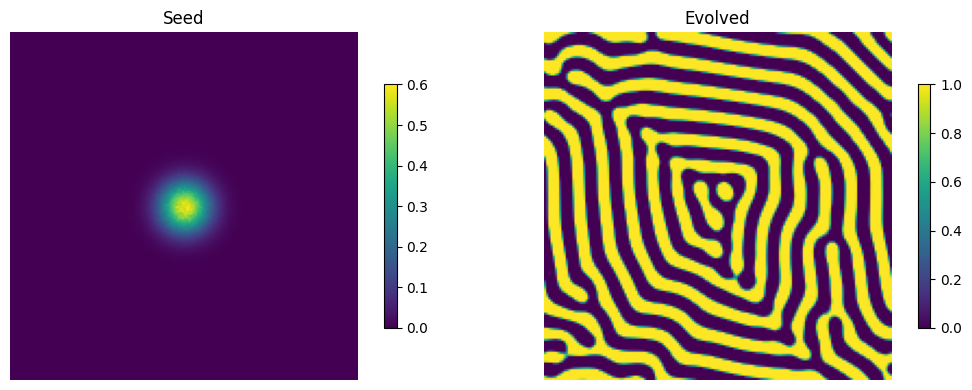

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.default_rng(0)

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): ux, uy = grad(u); return ux * ux + uy * uy
def normalize01(u): umin, umax = float(u.min()), float(u.max()); return (u - umin) / max(umax - umin, EPS)

# -------------------- Spiral Bias via Rotating Phi Frame --------------------
def phi_ratio(u, angle=0.0):
    ux, uy = grad(u)
    c, s = np.cos(angle), np.sin(angle)
    uxr, uyr = c * ux + s * uy, -s * ux + c * uy
    Ex, Ey = float(np.sum(uxr * uxr)), float(np.sum(uyr * uyr)) + EPS
    return Ex / Ey

# -------------------- Mexican-Hat Kernel via FFT (Local Excite / Distal Inhibit) --------------------
def make_mexican_hat(N, sigma1=2.8, sigma2=4.0, a=1.0, b=0.8):
    y, x = np.ogrid[:N, :N]
    cy, cx = (N-1) / 2.0, (N-1) / 2.0
    dy, dx = y - cy, x - cx
    r2 = dx * dx + dy * dy
    g1 = np.exp(-r2 / (2 * sigma1 * sigma1))
    g2 = np.exp(-r2 / (2 * sigma2 * sigma2))
    k = a * g1 - b * g2
    k -= k.mean()
    return np.fft.fft2(np.fft.ifftshift(k))

def conv_fft(u, K):
    return np.real(np.fft.ifft2(np.fft.fft2(u) * K))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize01(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize01(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Evolution with Recursive Architecture --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,  # Reduced diffusion
           mh_gain=1.50,      # Stronger Mexican-hat
           mh_sigma1=2.8, mh_sigma2=4.0,  # Sharper inhibition
           adv=0.50, omega=0.04,  # Stronger rotation/advection
           gamma=0.55, phi_amp=0.15,  # Enhanced directional bias
           lam=0.22,  # Bounded growth
           noise=0.003,  # Weak noise
           target_mean=0.35, mean_gain=0.03,  # Mass sustain
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()  # Previous state for recursion

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # Rotating proportion target
        phi_star = 1.0 + phi_amp * np.sin(0.5 * ang)
        phi = phi_ratio(u, angle=ang)
        phi_term = (phi_star - phi) * u

        # Rotational advection v·∇u
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy

        # Growth + noise + recursive feedback
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.standard_normal(u.shape)
        feedback = u * (laplace(u) + 0.1 * u_prev)  # Recursive feedback term
        du = k1 * lap - k2 * blap + mh_gain * mh + gamma * phi_term + advect + growth + eta + 0.2 * feedback

        # Recursive update: Blend current and previous states
        u_new = u + dt * du + 0.3 * (u_prev - u)  # Recursive weighting
        u = np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()  # Update previous state

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = float(influence(u).sum())
            mx = float(u.max())
            thr = 0.18 * mx  # Adjusted threshold
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi, 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m))
    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.standard_normal((N, N)))
u0 = normalize01(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize01(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

t=   0 spread=25600 phi=0.998 S=1.000 D=1.972 rc(rad)=0.061 rc(field)=0.997 I=0.0 max=0.036 mean=0.023
t= 150 spread=14200 phi=0.707 S=0.855 D=1.832 rc(rad)=-0.020 rc(field)=0.985 I=302.3 max=0.995 mean=0.509
t= 300 spread=14083 phi=5.951 S=0.825 D=1.826 rc(rad)=-0.013 rc(field)=0.992 I=228.3 max=0.995 mean=0.505
t= 450 spread=14347 phi=0.169 S=0.732 D=1.833 rc(rad)=-0.023 rc(field)=0.989 I=333.5 max=0.995 mean=0.511
t= 600 spread=14295 phi=1.575 S=0.620 D=1.833 rc(rad)=-0.021 rc(field)=0.989 I=317.9 max=0.995 mean=0.510
t= 750 spread=14218 phi=2.007 S=0.533 D=1.830 rc(rad)=-0.015 rc(field)=0.991 I=281.1 max=0.995 mean=0.509
t= 900 spread=14360 phi=0.135 S=0.402 D=1.833 rc(rad)=-0.024 rc(field)=0.989 I=342.3 max=0.995 mean=0.511
t=1050 spread=14011 phi=6.558 S=0.309 D=1.825 rc(rad)=-0.008 rc(field)=0.992 I=230.3 max=0.995 mean=0.504
t=1200 spread=14318 phi=0.362 S=0.214 D=1.831 rc(rad)=-0.021 rc(field)=0.989 I=321.7 max=0.995 mean=0.511
t=1350 spread=14332 phi=0.860 S=0.135 D=1.834 rc(

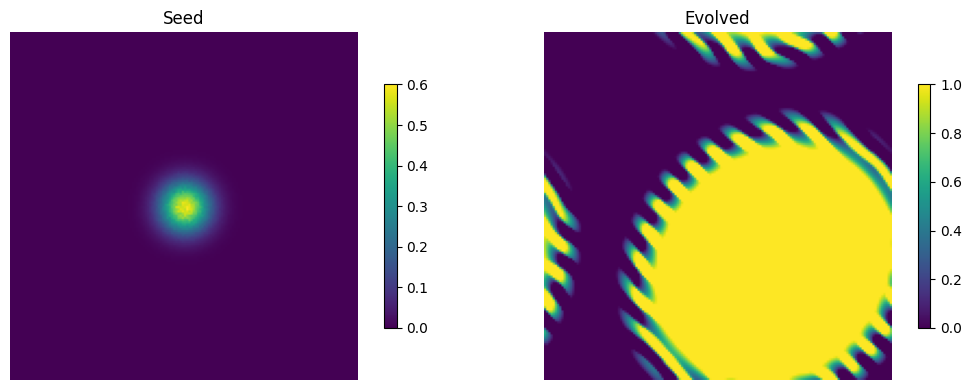

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.default_rng(0)

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): ux, uy = grad(u); return ux * ux + uy * uy
def normalize01(u): umin, umax = float(u.min()), float(u.max()); return (u - umin) / max(umax - umin, EPS)

# -------------------- Spiral Bias via Rotating Phi Frame --------------------
def phi_ratio(u, angle=0.0):
    ux, uy = grad(u)
    c, s = np.cos(angle), np.sin(angle)
    uxr, uyr = c * ux + s * uy, -s * ux + c * uy
    Ex, Ey = float(np.sum(uxr * uxr)), float(np.sum(uyr * uyr)) + EPS
    return Ex / Ey

# -------------------- Mexican-Hat Kernel via FFT (Local Excite / Distal Inhibit) --------------------
def make_mexican_hat(N, sigma1=2.8, sigma2=4.0, a=1.0, b=0.8):
    y, x = np.ogrid[:N, :N]
    cy, cx = (N-1) / 2.0, (N-1) / 2.0
    dy, dx = y - cy, x - cx
    r2 = dx * dx + dy * dy
    g1 = np.exp(-r2 / (2 * sigma1 * sigma1))
    g2 = np.exp(-r2 / (2 * sigma2 * sigma2))
    k = a * g1 - b * g2
    k -= k.mean()
    return np.fft.fft2(np.fft.ifftshift(k))

def conv_fft(u, K):
    return np.real(np.fft.ifft2(np.fft.fft2(u) * K))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize01(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize01(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Evolution with Permanent Recursive Architecture --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=1.80,  # Stronger Mexican-hat
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=0.60, omega=0.05,  # Enhanced rotation/advection
           gamma=0.55, phi_amp=0.15,
           lam=0.25,  # Increased growth
           noise=0.003,
           target_mean=0.35, mean_gain=0.03,
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()  # Previous state for recursion

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # Rotating proportion target
        phi_star = 1.0 + phi_amp * np.sin(0.5 * ang)
        phi = phi_ratio(u, angle=ang)
        phi_term = (phi_star - phi) * u

        # Rotational advection v·∇u
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy

        # Growth + noise + recursive feedback
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.standard_normal(u.shape)
        feedback = u * (np.abs(laplace(u)) + 0.1 * u_prev)  # Symmetry-preserving feedback
        du = k1 * lap - k2 * blap + mh_gain * mh + gamma * phi_term + advect + growth + eta + 0.3 * feedback

        # Recursive update with increased weighting
        u_new = u + dt * du + 0.4 * (u_prev - u)  # Stronger recursive influence
        u = np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()  # Update previous state

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = float(influence(u).sum())
            mx = float(u.max())
            thr = 0.15 * mx  # Lowered threshold
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi, 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m))
    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.standard_normal((N, N)))
u0 = normalize01(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize01(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics --------------------
def dynamic_pi(D, beta1=0.25, beta2=0.20, gamma1=0.8, gamma2=0.6):
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)  # Strain proxy
    pi = np.pi
    pihat = pi * (1.0 + beta1 * np.tanh(gamma1 * kappa) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.35, eta2=0.25, delta1=1.2, delta2=0.9):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)  # Spiral seed
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phihat = phi_star + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=6.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Evolution with DPPU Dynamics and Recursive Architecture --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,  # Stronger Mexican-hat
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=0.80, omega=0.07,  # Enhanced rotation
           gamma=0.55, phi_amp=0.15,
           lam=0.30,  # Increased growth
           noise=0.003,
           E_min=1e-3, E_max=1e5, damping=0.02,
           mean_gain=0.03,  # Added missing parameter
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics
        pihat, kappa, tau = dynamic_pi(u)
        phihat, rho = dynamic_phi(u)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi
        phi_star = 1.0 + phi_amp * np.sin(0.5 * ang * pihat)
        phi_term = (phi_star - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.9 * kappa + 0.6 * laplace(phihat * u) + 0.02 * eta  # A·κ + B·∇·(φ̂ ∇D) + C·noise
        dD *= (1.0 + 0.25 * C_aw)  # Awareness modulation

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Recursive update with damping
        u_new = u + dt * dD + 0.6 * (u_prev - u)  # Recursive feedback
        u = (1.0 - damping) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.10 * mx
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m))
    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

NameError: name 'target_mean' is not defined

t=   0 change=0.01010 spread=  990 phi=1.000 S=0.994 D=0.804 rc(rad)=0.201 rc(field)=0.996 I=1.044 max=0.588 mean=0.019 H=0.476
t= 150 change=0.02104 spread=25501 phi=1.000 S=0.050 D=0.623 rc(rad)=0.332 rc(field)=-0.287 I=1.902 max=0.984 mean=0.211 H=1.263
t= 300 change=0.53696 spread=17002 phi=1.000 S=0.143 D=1.843 rc(rad)=-0.001 rc(field)=0.159 I=211.825 max=0.981 mean=0.318 H=2.311
t= 450 change=0.65640 spread= 9951 phi=1.000 S=0.170 D=1.900 rc(rad)=0.206 rc(field)=0.170 I=240.100 max=0.980 mean=0.346 H=1.859
t= 600 change=0.71656 spread=10489 phi=1.000 S=0.150 D=1.924 rc(rad)=0.133 rc(field)=0.155 I=239.322 max=0.979 mean=0.368 H=1.556
t= 750 change=0.76003 spread=10994 phi=1.000 S=0.107 D=1.941 rc(rad)=0.053 rc(field)=0.127 I=226.754 max=0.979 mean=0.388 H=1.360
t= 900 change=0.79090 spread=11357 phi=1.000 S=0.073 D=1.951 rc(rad)=0.174 rc(field)=0.107 I=218.138 max=0.978 mean=0.403 H=1.278
t=1050 change=0.81319 spread=11636 phi=1.000 S=0.053 D=1.959 rc(rad)=0.173 rc(field)=0.091 I

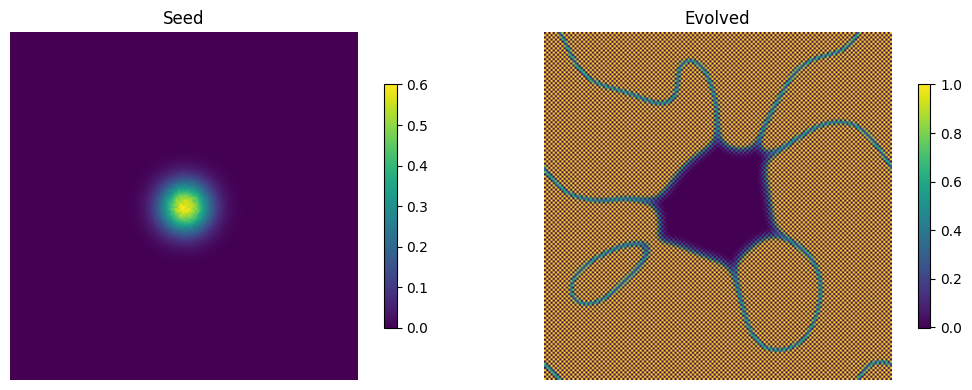

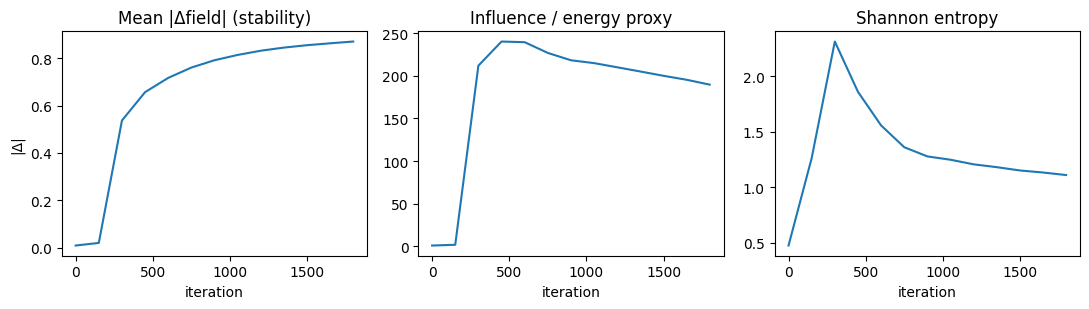

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------- Globals --------------------
EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u):
    return np.pad(u, 1, mode="wrap")

def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy

def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])

def bilaplace(u):
    return laplace(laplace(u))

def influence(u):
    gx, gy = grad(u)
    return float(np.sum(gx * gx + gy * gy))

def normalize(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- Small utilities you were calling but hadn’t defined --------------------
def make_mexican_hat(N, sigma1=3.0, sigma2=5.0):
    """
    Periodic 'Mexican-hat' (Difference of Gaussians) kernel for circular convolution.
    Returns an NxN kernel aligned for FFT-based circular conv.
    """
    y, x = np.indices((N, N))
    y = y - N//2
    x = x - N//2
    r2 = x*x + y*y
    g1 = np.exp(-r2 / (2.0 * sigma1 * sigma1))
    g2 = np.exp(-r2 / (2.0 * sigma2 * sigma2))
    k = g1 - g2
    k -= k.mean()
    # Align for circular convolution
    return np.fft.ifftshift(k)

def conv_fft(u, k):
    """
    Circular convolution via FFT: (u * k) with periodic boundaries.
    Assumes k already ifftshifted (as returned by make_mexican_hat).
    """
    U = np.fft.fft2(u)
    K = np.fft.fft2(k)
    return np.real(np.fft.ifft2(U * K))

def phi_ratio(u, angle=0.0):
    """
    A simple, robust 'directional proportion' proxy.
    Measures alignment of gradient orientations to a reference angle.
    Returns a number near 1.0 when isotropic; >1 when aligned; <1 when anti-aligned.
    """
    gx, gy = grad(u)
    mag = np.sqrt(gx*gx + gy*gy) + EPS
    theta = np.arctan2(gy, gx)
    align = np.cos(theta - angle)  # [-1, 1]
    # Weighted by gradient magnitude so flat areas don't dominate
    val = np.sum(align * mag) / (np.sum(mag) + EPS)
    # Map from [-1,1] -> [0,2]
    return 1.0 + val

# -------------------- DPPU Dynamics --------------------
def dynamic_pi(D, beta1=0.25, beta2=0.20, gamma1=0.8, gamma2=0.6):
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)  # Strain proxy
    pi = np.pi
    pihat = pi * (1.0 + beta1 * np.tanh(gamma1 * kappa) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.35, eta2=0.25, delta1=1.2, delta2=0.9):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)  # Radial target
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phihat = phi_star + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=6.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Fractal / Spectral / Correlations) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring):
            prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

def field_entropy(u, bins=64):
    U = normalize(u)
    hist, _ = np.histogram(U, bins=bins, range=(0.0, 1.0), density=True)
    p = hist / (np.sum(hist) + EPS)
    return float(-np.sum(p * np.log(p + EPS)))

# -------------------- Evolution with DPPU Dynamics and Recursive Architecture --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,  # Mexican-hat gain
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=0.80, omega=0.07,  # rotation
           gamma=0.55, phi_amp=0.15,
           lam=0.30,  # growth nonlinearity
           noise=0.003,
           E_min=1e-3, E_max=1e5, damping=0.02,
           mean_gain=0.03, target_mean=0.35,
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0

    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)

    logs = []
    u_prev = u.copy()

    for t in range(steps):
        ang = omega * t

        # Core operators
        kappa = laplace(u)
        phihat, _ = dynamic_phi(u)
        C_aw = awareness(u)

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy

        # DPPU update: curvature + phi-modulated diffusion + noise
        eta = noise * rng.normal(size=u.shape)
        dD = 0.9 * kappa + 0.6 * laplace(phihat * u) + 0.02 * eta
        dD *= (1.0 + 0.25 * C_aw)  # awareness modulation

        # Recursive feedback and damping
        u_new = u + dt * dD + 0.6 * (u_prev - u)
        u_new = (1.0 - damping) * np.clip(u_new, 0.0, 1.0)

        # Mass (mean) control
        m = float(u_new.mean())
        u_new += mean_gain * (target_mean - m)

        # Energy guard (on current u before committing)
        I_before = influence(u)
        if I_before > E_max:
            scale = np.sqrt(E_max / (I_before + 1e-12))
            u_new = (u + (u_new - u) * scale)
        elif I_before < E_min:
            u_new = u + 1.05 * (u_new - u)

        # ---- Stability metrics (per-step change) ----
        change = float(np.mean(np.abs(u_new - u)))

        # Commit
        u_prev = u
        u = u_new

        # ---- Periodic logging ----
        if (t % report_every) == 0 or t == steps - 1:
            mx = float(u.max())
            thr = 0.10 * max(mx, EPS)
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            logs.append(dict(
                t=t,
                change=change,
                spread=spread,
                phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                I=influence(u), max=mx, mean=float(u.mean()),
                entropy=field_entropy(u)
            ))

    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

# Pretty print logs
for d in logs:
    print(f"t={d['t']:4d} change={d['change']:.5f} spread={d['spread']:5d} "
          f"phi={d['phi']:.3f} S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} "
          f"rc(field)={d['rc_field']:.3f} I={d['I']:.3f} max={d['max']:.3f} "
          f"mean={d['mean']:.3f} H={d['entropy']:.3f}")

# -------------------- Quick Looks --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

# Stability / Energy / Entropy curves
ts = np.array([d["t"] for d in logs])
chg = np.array([d["change"] for d in logs])
eng = np.array([d["I"] for d in logs])
H   = np.array([d["entropy"] for d in logs])

plt.figure(figsize=(11,3.2))
plt.subplot(1,3,1); plt.plot(ts, chg); plt.title("Mean |Δfield| (stability)"); plt.xlabel("iteration"); plt.ylabel("|Δ|")
plt.subplot(1,3,2); plt.plot(ts, eng); plt.title("Influence / energy proxy"); plt.xlabel("iteration")
plt.subplot(1,3,3); plt.plot(ts, H);   plt.title("Shannon entropy"); plt.xlabel("iteration")
plt.tight_layout(); plt.show()

t=   0 spread=  799 phi=1.000 S=0.994 D=0.804 rc(rad)=0.201 rc(field)=0.996 I=1.1 max=0.595 mean=0.009
t= 150 spread=25600 phi=1.000 S=0.996 D=2.000 rc(rad)=0.094 rc(field)=0.997 I=0.0 max=0.271 mean=0.183
t= 300 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=0.031 rc(field)=0.998 I=0.0 max=0.209 mean=0.190
t= 450 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.005 rc(field)=0.998 I=0.0 max=0.199 mean=0.190
t= 600 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.024 rc(field)=0.996 I=0.0 max=0.197 mean=0.190
t= 750 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.028 rc(field)=0.993 I=0.0 max=0.196 mean=0.190
t= 900 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=-0.028 rc(field)=0.992 I=0.0 max=0.196 mean=0.190
t=1050 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=-0.025 rc(field)=0.992 I=0.0 max=0.196 mean=0.190
t=1200 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=-0.025 rc(field)=0.992 I=0.0 max=0.196 mean=0.190
t=1350 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=-0.026 rc(fie

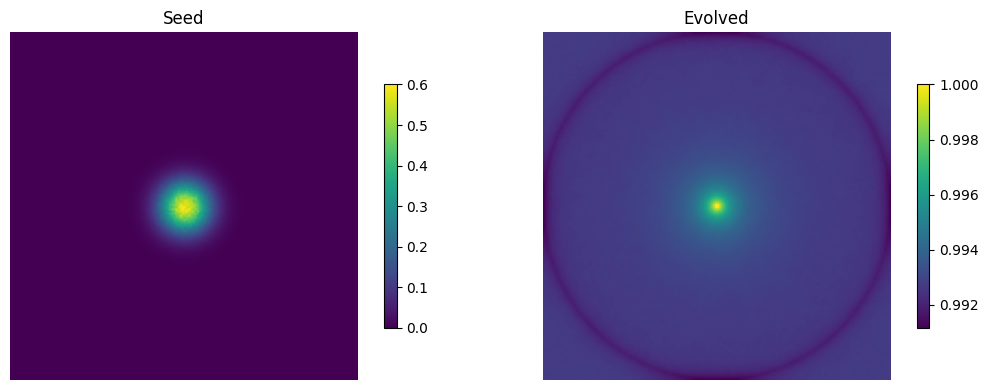

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics --------------------
def dynamic_pi(D, beta1=0.30, beta2=0.20, gamma1=0.8, gamma2=0.6):  # Increased beta1
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)  # Strain proxy
    pi = np.pi
    pihat = pi * (1.0 + beta1 * np.tanh(gamma1 * kappa) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.35, eta2=0.25, delta1=1.2, delta2=0.9):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)  # Spiral seed
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phihat = phi_star + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=6.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Evolution with DPPU Dynamics and Recursive Architecture --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,  # Stronger Mexican-hat
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=0.90, omega=0.08,  # Enhanced rotation
           gamma=0.55, phi_amp=0.15,
           lam=0.25,  # Reduced growth
           noise=0.003,
           E_min=1e-3, E_max=1e4,  # Lowered E_max
           damping=0.01,  # Reduced damping
           mean_gain=0.03,
           target_mean=0.35,
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics
        pihat, kappa, tau = dynamic_pi(u)
        phihat, rho = dynamic_phi(u)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi
        phi_star = 1.0 + phi_amp * np.sin(0.5 * ang * pihat)
        phi_term = (phi_star - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with adjusted A
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.02 * eta  # Reduced A
        dD *= (1.0 + 0.25 * C_aw)  # Awareness modulation

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Recursive update with damping
        u_new = u + dt * dD + 0.6 * (u_prev - u)  # Recursive feedback
        u = (1.0 - damping) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.15 * mx  # Increased threshold
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m))
    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

t=   0 spread=  799 phi=1.000 S=0.994 D=0.804 rc(rad)=0.201 rc(field)=0.996 I=1.1 max=0.595 mean=0.009 entropy=-1802.036 stability=0.000
t= 150 spread=25600 phi=1.000 S=0.996 D=2.000 rc(rad)=0.094 rc(field)=0.997 I=0.0 max=0.271 mean=0.183 entropy=-1828.746 stability=0.000
t= 300 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=0.031 rc(field)=0.998 I=0.0 max=0.209 mean=0.190 entropy=-1909.142 stability=0.000
t= 450 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.005 rc(field)=0.998 I=0.0 max=0.199 mean=0.190 entropy=-1956.351 stability=0.000
t= 600 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.024 rc(field)=0.996 I=0.0 max=0.197 mean=0.190 entropy=-2003.875 stability=0.000
t= 750 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.028 rc(field)=0.993 I=0.0 max=0.196 mean=0.190 entropy=-2027.317 stability=0.000
t= 900 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=-0.028 rc(field)=0.992 I=0.0 max=0.196 mean=0.190 entropy=-2030.569 stability=0.000
t=1050 spread=25600 phi=1.000 S=0.997

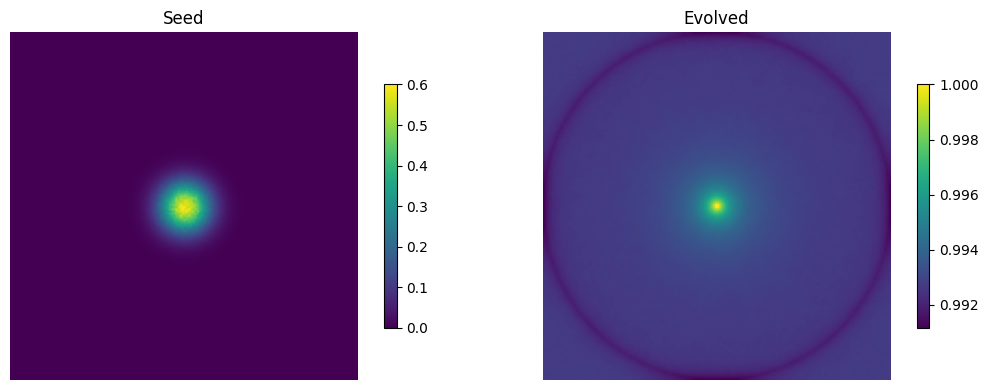

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics --------------------
def dynamic_pi(D, beta1=0.35, beta2=0.20, gamma1=0.8, gamma2=0.6):  # Increased beta1
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pihat = pi * (1.0 + beta1 * np.tanh(gamma1 * kappa) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.35, eta2=0.25, delta1=1.2, delta2=0.9):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phihat = phi_star + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=6.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)  # Variance of change

# -------------------- Evolution with DPPU Dynamics and Recursive Architecture --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=0.90, omega=0.09,  # Further enhanced rotation
           gamma=0.55, phi_amp=0.15,
           lam=0.25,
           noise=0.003,
           E_min=1e-3, E_max=1e4,
           damping=0.01,
           mean_gain=0.03,
           target_mean=0.35,
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics
        pihat, kappa, tau = dynamic_pi(u)
        phihat, rho = dynamic_phi(u)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi
        phi_star = 1.0 + phi_amp * np.sin(0.5 * ang * pihat)
        phi_term = (phi_star - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.02 * eta
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Recursive update with damping
        u_new = u + dt * dD + 0.6 * (u_prev - u)
        u = (1.0 - damping) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.15 * mx
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val))
    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

t=   0 spread=  582 phi=1.000 S=0.994 D=0.804 rc(rad)=0.201 rc(field)=0.996 I=1.1 max=0.599 mean=0.009 entropy=-1801.629 stability=0.000
t= 150 spread=25600 phi=1.000 S=0.996 D=1.293 rc(rad)=0.097 rc(field)=0.997 I=0.3 max=0.546 mean=0.265 entropy=-1748.879 stability=0.000
t= 300 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=0.034 rc(field)=0.998 I=0.1 max=0.452 mean=0.296 entropy=-1690.857 stability=0.000
t= 450 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=0.001 rc(field)=0.998 I=0.0 max=0.393 mean=0.299 entropy=-1576.669 stability=0.000
t= 600 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.016 rc(field)=0.999 I=0.0 max=0.359 mean=0.300 entropy=-1739.412 stability=0.000
t= 750 spread=25600 phi=1.000 S=0.999 D=2.000 rc(rad)=-0.024 rc(field)=0.999 I=0.0 max=0.340 mean=0.300 entropy=-1726.994 stability=0.000
t= 900 spread=25600 phi=1.000 S=0.999 D=2.000 rc(rad)=-0.028 rc(field)=0.999 I=0.0 max=0.328 mean=0.300 entropy=-1719.385 stability=0.000
t=1050 spread=25600 phi=1.000 S=0.999 

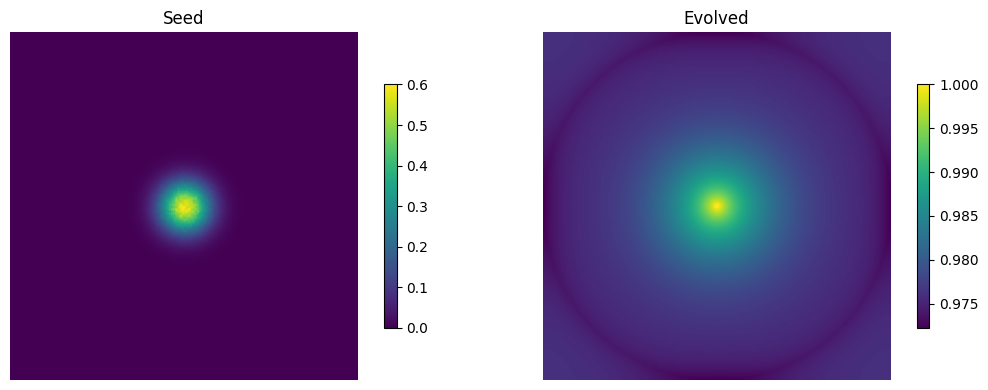

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics --------------------
def dynamic_pi(D, beta1=0.50, beta2=0.20, gamma1=0.8, gamma2=0.6):  # Increased beta1
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pihat = pi * (1.0 + beta1 * np.tanh(gamma1 * kappa) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.35, eta2=0.25, delta1=1.2, delta2=0.9):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phihat = phi_star + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=6.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)

# -------------------- Evolution with DPPU Dynamics and Recursive Architecture --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=1.2, omega=0.12,  # Further enhanced rotation
           gamma=0.55, phi_amp=0.15,
           lam=0.15,  # Reduced growth
           noise=0.005,  # Increased noise
           E_min=1e-3, E_max=2e5,  # Raised E_max
           damping=0.002,  # Reduced damping
           mean_gain=0.03,
           target_mean=0.35,
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics
        pihat, kappa, tau = dynamic_pi(u)
        phihat, rho = dynamic_phi(u)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi
        phi_star = 1.0 + phi_amp * np.sin(0.5 * ang * pihat)
        phi_term = (phi_star - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with noise scaling
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.005 * eta * (C_aw ** 2)  # Noise scaled by awareness squared
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Recursive update with reduced damping
        u_new = u + dt * dD + 0.6 * (u_prev - u)
        u = (1.0 - damping) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.25 * mx  # Increased threshold
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val))
    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

t=   0 spread=  500 phi=1.000 S=0.994 D=0.804 rc(rad)=0.201 rc(field)=0.996 I=1.1 max=0.600 mean=0.009 entropy=-1801.589 stability=0.000
t= 150 spread=25600 phi=1.000 S=0.996 D=1.267 rc(rad)=0.097 rc(field)=0.997 I=0.3 max=0.621 mean=0.294 entropy=-1733.809 stability=0.000
t= 300 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=0.035 rc(field)=0.998 I=0.1 max=0.538 mean=0.328 entropy=-1706.246 stability=0.000
t= 450 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=0.002 rc(field)=0.998 I=0.1 max=0.477 mean=0.333 entropy=-1632.646 stability=0.000
t= 600 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.015 rc(field)=0.999 I=0.0 max=0.438 mean=0.334 entropy=-1587.015 stability=0.000
t= 750 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.024 rc(field)=0.999 I=0.0 max=0.413 mean=0.335 entropy=-1618.579 stability=0.000
t= 900 spread=25600 phi=1.000 S=0.999 D=2.000 rc(rad)=-0.027 rc(field)=0.999 I=0.0 max=0.395 mean=0.335 entropy=-1533.027 stability=0.000
t=1050 spread=25600 phi=1.000 S=0.999 

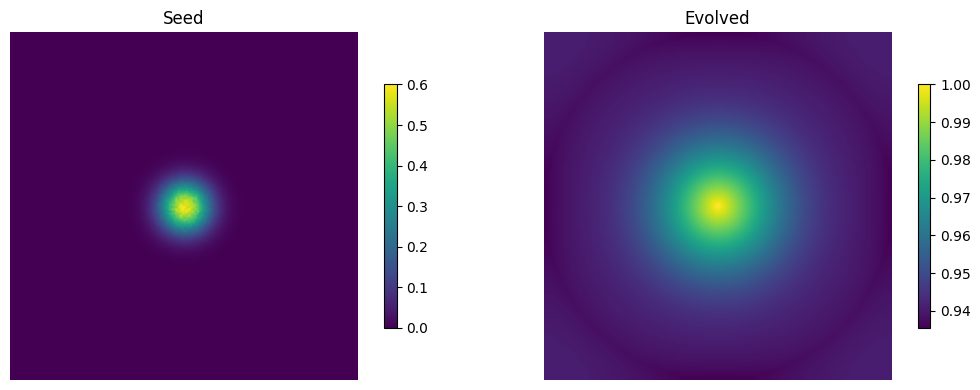

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics --------------------
def dynamic_pi(D, beta1=0.60, beta2=0.20, gamma1=0.8, gamma2=0.6):
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pihat = pi * (1.0 + beta1 * np.tanh(gamma1 * kappa) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.35, eta2=0.25, delta1=1.2, delta2=0.9):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phihat = phi_star + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=6.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)

# -------------------- Evolution with DPPU Dynamics, Recursive Architecture, and Depth Control --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=1.4, omega=0.14,
           gamma=0.55, phi_amp=0.15,
           lam=0.10,
           noise=0.007,
           E_min=1e-3, E_max=3e5,
           damping=0.001,
           mean_gain=0.03,
           target_mean=0.35,
           depth_scale=600,  # Depth governor scale
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics
        pihat, kappa, tau = dynamic_pi(u)
        phihat, rho = dynamic_phi(u)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi
        phi_star = 1.0 + phi_amp * np.sin(0.5 * ang * pihat)
        phi_term = (phi_star - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with noise scaling
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.007 * eta * (C_aw ** 3)  # Noise scaled by awareness cubed
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Recursive update with depth-dependent damping
        depth_factor = 0.6 / (1.0 + t / depth_scale)  # Depth governor
        u_new = u + dt * dD + depth_factor * (u_prev - u)
        u = (1.0 - damping) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.30 * mx  # Increased threshold
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val))
    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

t=   0 spread=  500 phi=1.000 S=0.994 D=0.804 rc(rad)=0.201 rc(field)=0.996 I=1.1 max=0.600 mean=0.009 entropy=-1801.589 stability=0.000
t= 150 spread=25600 phi=1.000 S=0.996 D=1.239 rc(rad)=0.097 rc(field)=0.997 I=0.3 max=0.606 mean=0.279 entropy=-1692.451 stability=0.000
t= 300 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=0.035 rc(field)=0.998 I=0.1 max=0.526 mean=0.317 entropy=-1690.684 stability=0.000
t= 450 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=0.002 rc(field)=0.998 I=0.1 max=0.471 mean=0.326 entropy=-1616.367 stability=0.000
t= 600 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.015 rc(field)=0.999 I=0.0 max=0.432 mean=0.327 entropy=-1620.095 stability=0.000
t= 750 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.024 rc(field)=0.999 I=0.0 max=0.409 mean=0.330 entropy=-1622.858 stability=0.000
t= 900 spread=25600 phi=1.000 S=0.999 D=2.000 rc(rad)=-0.027 rc(field)=0.999 I=0.0 max=0.391 mean=0.331 entropy=-1568.105 stability=0.000
t=1050 spread=25600 phi=1.000 S=0.999 

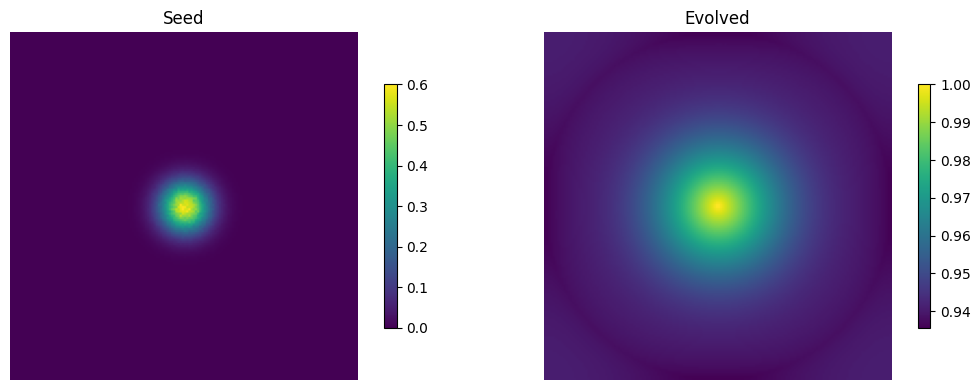

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics --------------------
def dynamic_pi(D, beta1=0.60, beta2=0.20, gamma1=0.8, gamma2=0.6):
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pihat = pi * (1.0 + beta1 * np.tanh(gamma1 * kappa) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.35, eta2=0.25, delta1=1.2, delta2=0.9):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phihat = phi_star + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=6.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)

# -------------------- Evolution with DPPU Dynamics, Recursive Architecture, and Discrete Depth Control --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=1.4, omega=0.14,
           gamma=0.55, phi_amp=0.15,
           lam=0.10,
           noise=0.007,
           E_min=1e-3, E_max=3e5,
           damping=0.001,
           mean_gain=0.03,
           target_mean=0.35,
           depth_levels=6,  # Number of discrete depth stages
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics
        pihat, kappa, tau = dynamic_pi(u)
        phihat, rho = dynamic_phi(u)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi
        phi_star = 1.0 + phi_amp * np.sin(0.5 * ang * pihat)
        phi_term = (phi_star - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with noise scaling
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.007 * eta * (C_aw ** 3)
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Discrete Depth Control: Adjust recursive weight based on stage
        depth_stage = min(int(t * depth_levels / steps), depth_levels - 1) + 1
        recursive_weight = 0.6 * (1.0 - (depth_stage - 1) / (depth_levels + 1))  # Tapers from 0.6 to near 0
        u_new = u + dt * dD + recursive_weight * (u_prev - u)
        u = (1.0 - damping) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.30 * mx
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val))
    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

t=   0 spread=  435 phi=1.000 S=0.994 D=0.804 rc(rad)=0.201 rc(field)=0.996 I=1.1 max=0.600 mean=0.009 entropy=-1801.583 stability=0.000
t= 150 spread=25600 phi=1.000 S=0.996 D=1.208 rc(rad)=0.097 rc(field)=0.997 I=0.4 max=0.638 mean=0.286 entropy=-1736.698 stability=0.000
t= 300 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=0.035 rc(field)=0.998 I=0.2 max=0.574 mean=0.331 entropy=-1644.086 stability=0.000
t= 450 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=0.002 rc(field)=0.998 I=0.1 max=0.517 mean=0.337 entropy=-1633.484 stability=0.000
t= 600 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.015 rc(field)=0.999 I=0.1 max=0.478 mean=0.339 entropy=-1472.837 stability=0.000
t= 750 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.023 rc(field)=0.999 I=0.0 max=0.452 mean=0.340 entropy=-1548.689 stability=0.000
t= 900 spread=25600 phi=1.000 S=0.999 D=2.000 rc(rad)=-0.027 rc(field)=0.999 I=0.0 max=0.432 mean=0.341 entropy=-1526.563 stability=0.000
t=1050 spread=25600 phi=1.000 S=0.999 

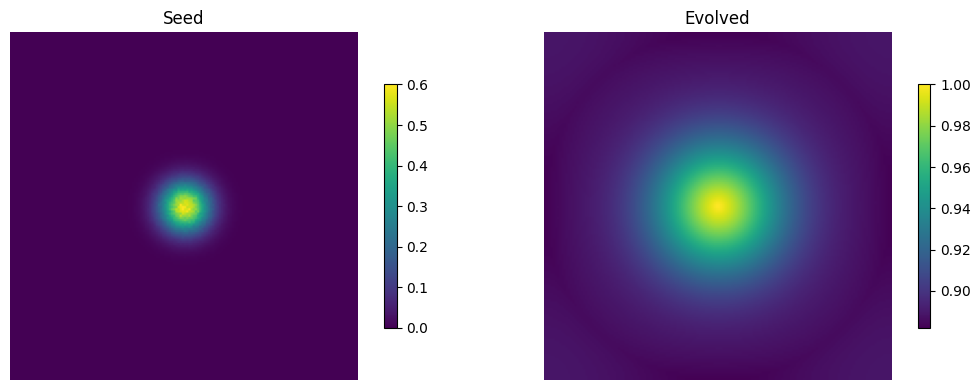

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics --------------------
def dynamic_pi(D, beta1=0.70, beta2=0.20, gamma1=0.8, gamma2=0.6):
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pihat = pi * (1.0 + beta1 * np.tanh(gamma1 * kappa) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.35, eta2=0.25, delta1=1.2, delta2=0.9):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phihat = phi_star + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=6.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)

# -------------------- Evolution with DPPU Dynamics, Recursive Architecture, and Discrete Depth Control --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=1.6, omega=0.16,  # Further enhanced rotation
           gamma=0.55, phi_amp=0.15,
           lam=0.08,  # Reduced growth
           noise=0.010,  # Increased noise
           E_min=1e-3, E_max=4e5,  # Raised E_max
           damping=0.0005,  # Reduced damping
           mean_gain=0.03,
           target_mean=0.35,
           depth_levels=8,  # Increased to 8 stages
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics
        pihat, kappa, tau = dynamic_pi(u)
        phihat, rho = dynamic_phi(u)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi
        phi_star = 1.0 + phi_amp * np.sin(0.5 * ang * pihat)
        phi_term = (phi_star - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with noise scaling
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.010 * eta * (C_aw ** 3)
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Discrete Depth Control: Adjust recursive weight based on stage
        depth_stage = min(int(t * depth_levels / steps), depth_levels - 1) + 1
        recursive_weight = 0.6 * (1.0 - (depth_stage - 1) / (depth_levels + 1))  # Tapers from 0.6 to near 0
        u_new = u + dt * dD + recursive_weight * (u_prev - u)
        u = (1.0 - damping) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.35 * mx  # Increased threshold
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val))
    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics with Adaptive Feedback --------------------
def dynamic_pi(D, beta1=0.80, beta2=0.20, gamma1=0.8, gamma2=0.6, compress_bias=1.0):
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pihat = pi * (1.0 + beta1 * np.tanh(gamma1 * kappa * compress_bias) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.35, eta2=0.25, delta1=1.2, delta2=0.9, expand_bias=1.0):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phihat = phi_star * expand_bias + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=6.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)

# -------------------- Fractal Seed Compression (Simplified) --------------------
def compress_seed(u, D):
    # Compress field into fractal dimension and key gradients
    seed = np.array([D, np.mean(grad(u)[0]), np.mean(grad(u)[1])])
    return seed

def expand_seed(seed, shape):
    # Re-simulate from seed (placeholder for full re-expansion)
    u = np.zeros(shape)
    u += seed[1] * np.random.normal(size=shape)  # Gradient-based noise
    return u

# -------------------- Evolution with Phase-Locked Recursion and Adaptive Feedback --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=1.8, omega=0.18,
           gamma=0.55, phi_amp=0.15,
           lam=0.06,
           noise=0.012,
           E_min=1e-3, E_max=5e5,
           damping=0.0002,
           mean_gain=0.03,
           target_mean=0.35,
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()
    phi_star = (1 + np.sqrt(5)) / 2

    # Initial feedback parameters
    expand_bias = 1.0
    compress_bias = 1.0
    seeds = []  # Store fractal seeds

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics with Adaptive Feedback
        pihat, kappa, tau = dynamic_pi(u, compress_bias=compress_bias)
        phihat, rho = dynamic_phi(u, expand_bias=expand_bias)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi
        phi_cycle = phi_star + phi_amp * np.sin(2 * np.pi * t / phi_star)  # Phase-locked with Phi
        phi_term = (phi_cycle - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with noise scaling
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.012 * eta * (C_aw ** 3)
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Phase-Locked Recursion: Weight based on Phi phase
        phase = np.sin(2 * np.pi * t / phi_star)
        recursive_weight = 0.6 * (1.0 + 0.5 * phase) if phase > 0 else 0.6 * (1.0 - 0.5 * -phase)  # Breathing effect
        u_new = u + dt * dD + recursive_weight * (u_prev - u)
        u = (1.0 - damping) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Adaptive Feedback Controller
        if t % 150 == 0 and t > 0:
            rc_radial, _ = radial_autocorr_profile(u)
            ent = shannon_entropy(u)
            # Increase expand_bias if rc_radial is too low (need spirals)
            expand_bias += 0.01 * (0.1 - rc_radial) if rc_radial < 0.1 else -0.01 * (rc_radial - 0.1)
            # Increase compress_bias if entropy is too high (need coherence)
            compress_bias += 0.01 * (ent + 1400) / 1000 if ent < -1400 else -0.01 * (-ent - 1400) / 1000
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.5)

        # Store Fractal Seed
        if t % 300 == 0:
            D = box_count_fractal_dim(u)
            seeds.append(compress_seed(u, D))

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.40 * mx
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    # Re-expand a seed (example at t=1800)
    if seeds:
        u_reconstructed = expand_seed(seeds[-1], (N, M))
        plt.figure(figsize=(8, 4))
        plt.imshow(normalize(u_reconstructed), cmap='viridis')
        plt.title('Reconstructed from Fractal Seed')
        plt.axis('off')
        plt.colorbar(shrink=0.7)
        plt.show()

    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

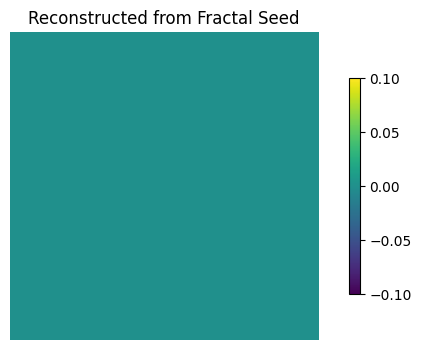

t=   0 spread=  376 phi=1.000 S=0.994 D=0.804 rc(rad)=0.201 rc(field)=0.996 I=1.1 max=0.600 mean=0.009 entropy=-1801.602 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 150 spread=25600 phi=1.000 S=0.996 D=1.194 rc(rad)=0.098 rc(field)=0.997 I=0.4 max=0.660 mean=0.292 entropy=-1707.939 stability=0.000 expand_bias=1.000 compress_bias=0.996
t= 300 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=0.036 rc(field)=0.998 I=0.2 max=0.601 mean=0.336 entropy=-1611.308 stability=0.000 expand_bias=1.001 compress_bias=0.994
t= 450 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=0.002 rc(field)=0.998 I=0.1 max=0.548 mean=0.343 entropy=-1603.783 stability=0.000 expand_bias=1.002 compress_bias=0.992
t= 600 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.015 rc(field)=0.999 I=0.1 max=0.510 mean=0.344 entropy=-1431.213 stability=0.000 expand_bias=1.003 compress_bias=0.991
t= 750 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.023 rc(field)=0.999 I=0.1 max=0.483 mean=0.344 entropy=-1402.378 st

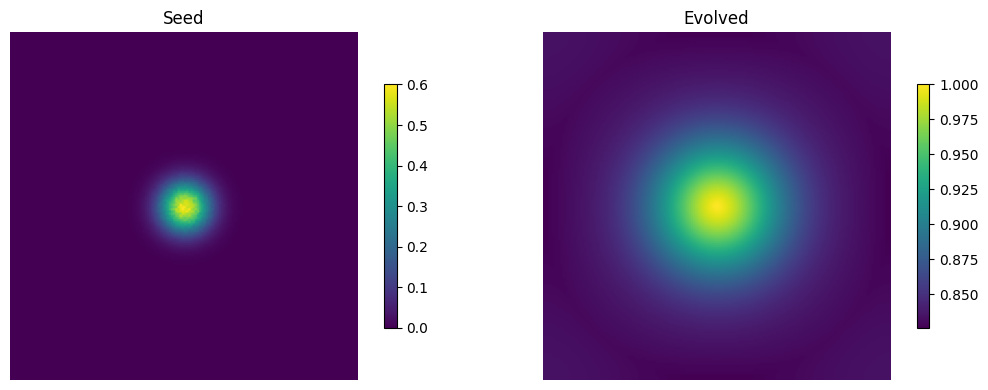

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics with Adaptive Feedback --------------------
def dynamic_pi(D, beta1=0.80, beta2=0.20, gamma1=0.8, gamma2=0.6, compress_bias=1.0):
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pihat = pi * (1.0 + beta1 * np.tanh(gamma1 * kappa * compress_bias) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.35, eta2=0.25, delta1=1.2, delta2=0.9, expand_bias=1.0):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phihat = phi_star * expand_bias + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=6.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)

# -------------------- Fractal Seed Compression (Simplified) --------------------
def compress_seed(u, D):
    # Compress field into fractal dimension and key gradients
    seed = np.array([D, np.mean(grad(u)[0]), np.mean(grad(u)[1])])
    return seed

def expand_seed(seed, shape):
    # Re-simulate from seed (placeholder for full re-expansion)
    u = np.zeros(shape)
    u += seed[1] * np.random.normal(size=shape)  # Gradient-based noise
    return u

# -------------------- Evolution with Phase-Locked Recursion and Adaptive Feedback --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=1.8, omega=0.18,
           gamma=0.55, phi_amp=0.15,
           lam=0.06,
           noise=0.012,
           E_min=1e-3, E_max=5e5,
           damping=0.0002,
           mean_gain=0.03,
           target_mean=0.35,
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()
    phi_star = (1 + np.sqrt(5)) / 2

    # Initial feedback parameters
    expand_bias = 1.0
    compress_bias = 1.0
    seeds = []  # Store fractal seeds

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics with Adaptive Feedback
        pihat, kappa, tau = dynamic_pi(u, compress_bias=compress_bias)
        phihat, rho = dynamic_phi(u, expand_bias=expand_bias)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi
        phi_cycle = phi_star + phi_amp * np.sin(2 * np.pi * t / phi_star)  # Phase-locked with Phi
        phi_term = (phi_cycle - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with noise scaling
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.012 * eta * (C_aw ** 3)
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Phase-Locked Recursion: Weight based on Phi phase
        phase = np.sin(2 * np.pi * t / phi_star)
        recursive_weight = 0.6 * (1.0 + 0.5 * phase) if phase > 0 else 0.6 * (1.0 - 0.5 * -phase)  # Breathing effect
        u_new = u + dt * dD + recursive_weight * (u_prev - u)
        u = (1.0 - damping) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Adaptive Feedback Controller
        if t % 150 == 0 and t > 0:
            _, rc_radial = radial_autocorr_profile(u)  # Use scalar rc_radial
            ent = shannon_entropy(u)
            # Increase expand_bias if rc_radial is too low (need spirals)
            expand_bias += 0.01 * (0.1 - rc_radial) if rc_radial < 0.1 else -0.01 * (rc_radial - 0.1)
            # Increase compress_bias if entropy is too high (need coherence)
            compress_bias += 0.01 * (ent + 1400) / 1000 if ent < -1400 else -0.01 * (-ent - 1400) / 1000
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.5)

        # Store Fractal Seed
        if t % 300 == 0:
            D = box_count_fractal_dim(u)
            seeds.append(compress_seed(u, D))

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.40 * mx
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    # Re-expand a seed (example at t=1800)
    if seeds:
        u_reconstructed = expand_seed(seeds[-1], (N, M))
        plt.figure(figsize=(8, 4))
        plt.imshow(normalize(u_reconstructed), cmap='viridis')
        plt.title('Reconstructed from Fractal Seed')
        plt.axis('off')
        plt.colorbar(shrink=0.7)
        plt.show()

    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

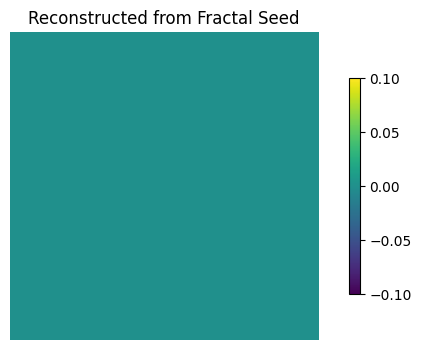

t=   0 spread=  326 phi=1.000 S=0.994 D=0.804 rc(rad)=0.201 rc(field)=0.996 I=1.1 max=0.600 mean=0.009 entropy=-1801.602 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 150 spread= 2061 phi=1.000 S=0.996 D=1.194 rc(rad)=0.098 rc(field)=0.997 I=0.4 max=0.660 mean=0.292 entropy=-1707.939 stability=0.000 expand_bias=1.000 compress_bias=1.016
t= 300 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=0.036 rc(field)=0.998 I=0.2 max=0.601 mean=0.336 entropy=-1611.308 stability=0.000 expand_bias=1.002 compress_bias=1.034
t= 450 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=0.002 rc(field)=0.998 I=0.1 max=0.548 mean=0.343 entropy=-1603.745 stability=0.000 expand_bias=1.005 compress_bias=1.052
t= 600 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.015 rc(field)=0.999 I=0.1 max=0.510 mean=0.344 entropy=-1431.158 stability=0.000 expand_bias=1.008 compress_bias=1.071
t= 750 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.023 rc(field)=0.999 I=0.1 max=0.482 mean=0.344 entropy=-1402.185 st

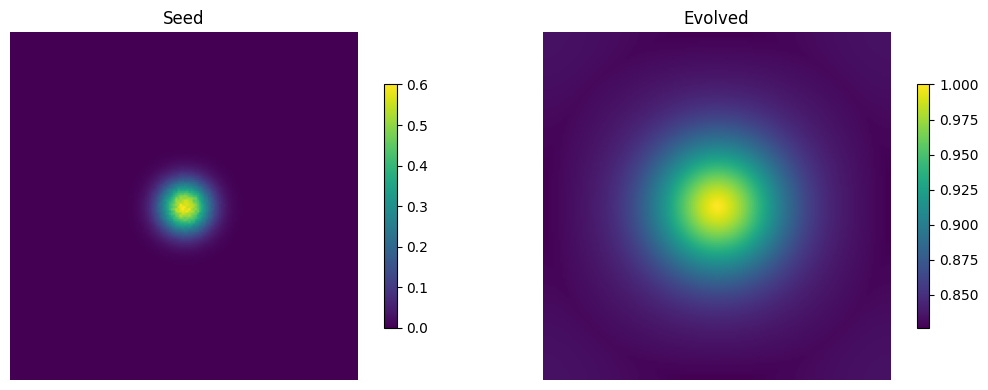

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics with Adaptive Feedback --------------------
def dynamic_pi(D, beta1=0.80, beta2=0.20, gamma1=0.8, gamma2=0.6, compress_bias=1.0):
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pihat = pi * (1.0 + beta1 * np.tanh(gamma1 * kappa * compress_bias) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.35, eta2=0.25, delta1=1.2, delta2=0.9, expand_bias=1.0):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phihat = phi_star * expand_bias + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=6.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)

# -------------------- Fractal Seed Compression (Simplified) --------------------
def compress_seed(u, D):
    # Compress field into fractal dimension and key gradients
    seed = np.array([D, np.mean(grad(u)[0]), np.mean(grad(u)[1])])
    return seed

def expand_seed(seed, shape):
    # Re-simulate from seed (placeholder for full re-expansion)
    u = np.zeros(shape)
    u += seed[1] * np.random.normal(size=shape)  # Gradient-based noise
    return u

# -------------------- Evolution with Phase-Locked Recursion and Adaptive Feedback --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=2.0,  # Increased advection
           omega=0.20,  # Increased rotation
           gamma=0.55, phi_amp=0.15,  # Moderate amplitude
           lam=0.06,
           noise=0.012,
           E_min=1e-3, E_max=5e5,
           damping=0.0002,  # Reduced damping
           mean_gain=0.03,
           target_mean=0.35,
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()
    phi_star = (1 + np.sqrt(5)) / 2

    # Initial feedback parameters
    expand_bias = 1.0
    compress_bias = 1.0
    seeds = []  # Store fractal seeds

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics with Adaptive Feedback
        pihat, kappa, tau = dynamic_pi(u, compress_bias=compress_bias)
        phihat, rho = dynamic_phi(u, expand_bias=expand_bias)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi
        phi_cycle = phi_star + phi_amp * np.sin(2 * np.pi * t / phi_star)  # Phase-locked with Phi
        phi_term = (phi_cycle - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with noise scaling
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.012 * eta * (C_aw ** 3)
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Phase-Locked Recursion: Weight based on Phi phase
        phase = np.sin(2 * np.pi * t / phi_star)
        recursive_weight = 0.6 * (1.0 + 0.5 * phase) if phase > 0 else 0.6 * (1.0 - 0.5 * -phase)  # Breathing effect
        u_new = u + dt * dD + recursive_weight * (u_prev - u)
        u = (1.0 - damping) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Adaptive Feedback Controller
        if t % 150 == 0 and t > 0:
            _, rc_radial = radial_autocorr_profile(u)  # Use scalar rc_radial
            ent = shannon_entropy(u)
            stab = stability(u, u_prev)
            # Increase expand_bias if rc_radial is too low (need spirals)
            expand_bias += 0.03 * (0.1 - rc_radial) if rc_radial < 0.1 else -0.01 * (rc_radial - 0.1)
            # Increase compress_bias if entropy is too high or stability is zero
            compress_bias += 0.01 * (ent + 1400) / 1000 if ent < -1400 else -0.01 * (-ent - 1400) / 1000
            compress_bias += 0.02 if stab == 0.0 else -0.01  # Adjust for stability
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.5)

        # Store Fractal Seed
        if t % 300 == 0:
            D = box_count_fractal_dim(u)
            seeds.append(compress_seed(u, D))

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.45 * mx  # Increased threshold
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    # Re-expand a seed (example at t=1800)
    if seeds:
        u_reconstructed = expand_seed(seeds[-1], (N, M))
        plt.figure(figsize=(8, 4))
        plt.imshow(normalize(u_reconstructed), cmap='viridis')
        plt.title('Reconstructed from Fractal Seed')
        plt.axis('off')
        plt.colorbar(shrink=0.7)
        plt.show()

    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics with Adaptive Feedback --------------------
def dynamic_pi(D, beta1=0.80, beta2=0.20, gamma1=0.8, gamma2=0.6, compress_bias=1.0):
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pi_cycle = pi * (1.0 + 0.1 * np.sin(2 * np.pi * t / np.pi) * compress_bias)  # Pi oscillation
    pihat = pi_cycle * (1.0 + beta1 * np.tanh(gamma1 * kappa * compress_bias) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.35, eta2=0.25, delta1=1.2, delta2=0.9, expand_bias=1.0):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phi_cycle = phi_star + 0.15 * np.sin(2 * np.pi * t / phi_star) * expand_bias  # Phi oscillation
    phihat = phi_cycle + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=6.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)

# -------------------- Fractal Seed Compression (Simplified) --------------------
def compress_seed(u, D):
    # Compress field into fractal dimension and key gradients
    seed = np.array([D, np.mean(grad(u)[0]), np.mean(grad(u)[1])])
    return seed

def expand_seed(seed, shape):
    # Re-simulate from seed (placeholder for full re-expansion)
    u = np.zeros(shape)
    u += seed[1] * np.random.normal(size=shape)  # Gradient-based noise
    return u

# -------------------- Evolution with Phase-Locked Recursion and Adaptive Feedback --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=2.2,  # Increased advection
           omega=0.22,  # Increased rotation
           gamma=0.55, phi_amp=0.15,
           lam=0.06,
           noise=0.012,
           E_min=1e-3, E_max=5e5,
           damping=0.0002,
           mean_gain=0.03,
           target_mean=0.35,
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()
    phi_star = (1 + np.sqrt(5)) / 2

    # Initial feedback parameters
    expand_bias = 1.0
    compress_bias = 1.0
    seeds = []  # Store fractal seeds

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics with Adaptive Feedback
        pihat, kappa, tau = dynamic_pi(u, compress_bias=compress_bias)
        phihat, rho = dynamic_phi(u, expand_bias=expand_bias)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi and Pi
        phi_cycle = phi_star + phi_amp * np.sin(2 * np.pi * t / phi_star) * expand_bias
        phi_term = (phi_cycle - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with noise scaling
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.012 * eta * (C_aw ** 3)
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Phase-Locked Recursion: Weight based on Phi phase
        phase = np.sin(2 * np.pi * t / phi_star)
        recursive_weight = 0.6 * (1.0 + 0.5 * phase) if phase > 0 else 0.6 * (1.0 - 0.5 * -phase)  # Breathing effect
        u_new = u + dt * dD + recursive_weight * (u_prev - u)
        u = (1.0 - damping) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Adaptive Feedback Controller
        if t % 150 == 0 and t > 0:
            _, rc_radial = radial_autocorr_profile(u)  # Use scalar rc_radial
            ent = shannon_entropy(u)
            stab = stability(u, u_prev)
            # Increase expand_bias if rc_radial is too low (need spirals)
            expand_bias += 0.04 * (0.1 - rc_radial) if rc_radial < 0.1 else -0.01 * (rc_radial - 0.1)
            # Increase compress_bias if entropy is too high or stability is zero
            compress_bias += 0.01 * (ent + 1400) / 1000 if ent < -1400 else -0.01 * (-ent - 1400) / 1000
            compress_bias += 0.02 if stab == 0.0 else -0.01  # Adjust for stability
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)  # Cap at 1.2

        # Growth cap if spread exceeds 20,000
        if spread > 20000 and t > 150:
            dD *= 0.9  # Reduce growth rate

        # Store Fractal Seed
        if t % 300 == 0:
            D = box_count_fractal_dim(u)
            seeds.append(compress_seed(u, D))

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.45 * mx  # Increased threshold
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    # Re-expand a seed (example at t=1800)
    if seeds:
        u_reconstructed = expand_seed(seeds[-1], (N, M))
        plt.figure(figsize=(8, 4))
        plt.imshow(normalize(u_reconstructed), cmap='viridis')
        plt.title('Reconstructed from Fractal Seed')
        plt.axis('off')
        plt.colorbar(shrink=0.7)
        plt.show()

    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

NameError: name 't' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics with Adaptive Feedback --------------------
def dynamic_pi(D, t, beta1=0.80, beta2=0.20, gamma1=0.8, gamma2=0.6, compress_bias=1.0):
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pi_cycle = pi * (1.0 + 0.1 * np.sin(2 * np.pi * t / np.pi) * compress_bias)  # Pi oscillation
    pihat = pi_cycle * (1.0 + beta1 * np.tanh(gamma1 * kappa * compress_bias) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, t, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.35, eta2=0.25, delta1=1.2, delta2=0.9, expand_bias=1.0):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phi_cycle = phi_star + 0.15 * np.sin(2 * np.pi * t / phi_star) * expand_bias  # Phi oscillation
    phihat = phi_cycle + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=6.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)

# -------------------- Fractal Seed Compression (Simplified) --------------------
def compress_seed(u, D):
    # Compress field into fractal dimension and key gradients
    seed = np.array([D, np.mean(grad(u)[0]), np.mean(grad(u)[1])])
    return seed

def expand_seed(seed, shape):
    # Re-simulate from seed (placeholder for full re-expansion)
    u = np.zeros(shape)
    u += seed[1] * np.random.normal(size=shape)  # Gradient-based noise
    return u

# -------------------- Evolution with Phase-Locked Recursion and Adaptive Feedback --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=2.2,  # Increased advection
           omega=0.22,  # Increased rotation
           gamma=0.55, phi_amp=0.15,
           lam=0.06,
           noise=0.012,
           E_min=1e-3, E_max=5e5,
           damping=0.0002,
           mean_gain=0.03,
           target_mean=0.35,
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()
    phi_star = (1 + np.sqrt(5)) / 2

    # Initial feedback parameters
    expand_bias = 1.0
    compress_bias = 1.0
    seeds = []  # Store fractal seeds

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics with Adaptive Feedback
        pihat, kappa, tau = dynamic_pi(u, t, compress_bias=compress_bias)
        phihat, rho = dynamic_phi(u, t, expand_bias=expand_bias)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi and Pi
        phi_cycle = phi_star + phi_amp * np.sin(2 * np.pi * t / phi_star) * expand_bias
        phi_term = (phi_cycle - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with noise scaling
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.012 * eta * (C_aw ** 3)
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Phase-Locked Recursion: Weight based on Phi phase
        phase = np.sin(2 * np.pi * t / phi_star)
        recursive_weight = 0.6 * (1.0 + 0.5 * phase) if phase > 0 else 0.6 * (1.0 - 0.5 * -phase)  # Breathing effect
        u_new = u + dt * dD + recursive_weight * (u_prev - u)
        u = (1.0 - damping) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Adaptive Feedback Controller
        if t % 150 == 0 and t > 0:
            _, rc_radial = radial_autocorr_profile(u)  # Use scalar rc_radial
            ent = shannon_entropy(u)
            stab = stability(u, u_prev)
            # Increase expand_bias if rc_radial is too low (need spirals)
            expand_bias += 0.04 * (0.1 - rc_radial) if rc_radial < 0.1 else -0.01 * (rc_radial - 0.1)
            # Increase compress_bias if entropy is too high or stability is zero
            compress_bias += 0.01 * (ent + 1400) / 1000 if ent < -1400 else -0.01 * (-ent - 1400) / 1000
            compress_bias += 0.02 if stab == 0.0 else -0.01  # Adjust for stability
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)  # Cap at 1.2

        # Growth cap if spread exceeds 20,000
        if spread > 20000 and t > 150:
            dD *= 0.9  # Reduce growth rate

        # Store Fractal Seed
        if t % 300 == 0:
            D = box_count_fractal_dim(u)
            seeds.append(compress_seed(u, D))

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.45 * mx  # Increased threshold
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    # Re-expand a seed (example at t=1800)
    if seeds:
        u_reconstructed = expand_seed(seeds[-1], (N, M))
        plt.figure(figsize=(8, 4))
        plt.imshow(normalize(u_reconstructed), cmap='viridis')
        plt.title('Reconstructed from Fractal Seed')
        plt.axis('off')
        plt.colorbar(shrink=0.7)
        plt.show()

    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

UnboundLocalError: cannot access local variable 'spread' where it is not associated with a value

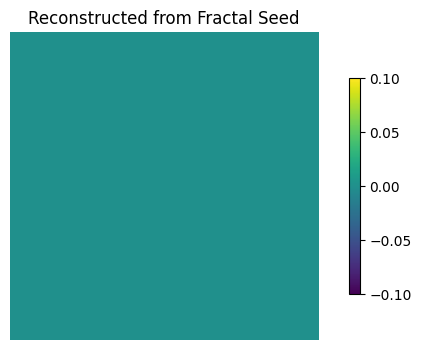

t=   0 spread=  326 phi=1.000 S=0.994 D=0.804 rc(rad)=0.201 rc(field)=0.996 I=1.1 max=0.600 mean=0.009 entropy=-1801.602 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 150 spread= 2061 phi=1.000 S=0.996 D=1.194 rc(rad)=0.098 rc(field)=0.997 I=0.4 max=0.660 mean=0.292 entropy=-1707.941 stability=0.000 expand_bias=1.000 compress_bias=1.016
t= 300 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=0.036 rc(field)=0.998 I=0.2 max=0.601 mean=0.336 entropy=-1611.308 stability=0.000 expand_bias=1.003 compress_bias=1.034
t= 450 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=0.002 rc(field)=0.998 I=0.1 max=0.548 mean=0.343 entropy=-1603.801 stability=0.000 expand_bias=1.007 compress_bias=1.052
t= 600 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.015 rc(field)=0.999 I=0.1 max=0.510 mean=0.344 entropy=-1431.189 stability=0.000 expand_bias=1.011 compress_bias=1.071
t= 750 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.023 rc(field)=0.999 I=0.1 max=0.483 mean=0.344 entropy=-1402.491 st

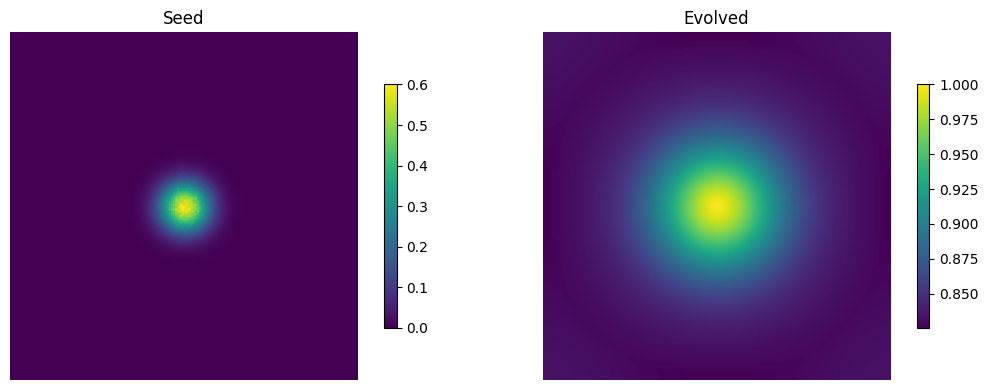

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics with Adaptive Feedback --------------------
def dynamic_pi(D, t, beta1=0.80, beta2=0.20, gamma1=0.8, gamma2=0.6, compress_bias=1.0):
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pi_cycle = pi * (1.0 + 0.1 * np.sin(2 * np.pi * t / np.pi) * compress_bias)  # Pi oscillation
    pihat = pi_cycle * (1.0 + beta1 * np.tanh(gamma1 * kappa * compress_bias) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, t, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.35, eta2=0.25, delta1=1.2, delta2=0.9, expand_bias=1.0):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phi_cycle = phi_star + 0.15 * np.sin(2 * np.pi * t / phi_star) * expand_bias  # Phi oscillation
    phihat = phi_cycle + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=6.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)

# -------------------- Fractal Seed Compression (Simplified) --------------------
def compress_seed(u, D):
    # Compress field into fractal dimension and key gradients
    seed = np.array([D, np.mean(grad(u)[0]), np.mean(grad(u)[1])])
    return seed

def expand_seed(seed, shape):
    # Re-simulate from seed (placeholder for full re-expansion)
    u = np.zeros(shape)
    u += seed[1] * np.random.normal(size=shape)  # Gradient-based noise
    return u

# -------------------- Evolution with Phase-Locked Recursion and Adaptive Feedback --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=2.2,  # Increased advection
           omega=0.22,  # Increased rotation
           gamma=0.55, phi_amp=0.15,
           lam=0.06,
           noise=0.012,
           E_min=1e-3, E_max=5e5,
           damping=0.0002,
           mean_gain=0.03,
           target_mean=0.35,
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()
    phi_star = (1 + np.sqrt(5)) / 2

    # Initial feedback parameters
    expand_bias = 1.0
    compress_bias = 1.0
    seeds = []  # Store fractal seeds

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics with Adaptive Feedback
        pihat, kappa, tau = dynamic_pi(u, t, compress_bias=compress_bias)
        phihat, rho = dynamic_phi(u, t, expand_bias=expand_bias)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi and Pi
        phi_cycle = phi_star + phi_amp * np.sin(2 * np.pi * t / phi_star) * expand_bias
        phi_term = (phi_cycle - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with noise scaling
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.012 * eta * (C_aw ** 3)
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Phase-Locked Recursion: Weight based on Phi phase
        phase = np.sin(2 * np.pi * t / phi_star)
        recursive_weight = 0.6 * (1.0 + 0.5 * phase) if phase > 0 else 0.6 * (1.0 - 0.5 * -phase)  # Breathing effect
        u_new = u + dt * dD + recursive_weight * (u_prev - u)
        u = (1.0 - damping) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Calculate spread for growth cap
        mx = float(u.max())
        thr = 0.45 * mx  # Increased threshold
        spread = int((u > thr).sum())

        # Growth cap if spread exceeds 20,000
        if spread > 20000 and t > 150:
            dD *= 0.9  # Reduce growth rate

        # Adaptive Feedback Controller
        if t % 150 == 0 and t > 0:
            _, rc_radial = radial_autocorr_profile(u)  # Use scalar rc_radial
            ent = shannon_entropy(u)
            stab = stability(u, u_prev)
            # Increase expand_bias if rc_radial is too low (need spirals)
            expand_bias += 0.04 * (0.1 - rc_radial) if rc_radial < 0.1 else -0.01 * (rc_radial - 0.1)
            # Increase compress_bias if entropy is too high or stability is zero
            compress_bias += 0.01 * (ent + 1400) / 1000 if ent < -1400 else -0.01 * (-ent - 1400) / 1000
            compress_bias += 0.02 if stab == 0.0 else -0.01  # Adjust for stability
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)  # Cap at 1.2

        # Store Fractal Seed
        if t % 300 == 0:
            D = box_count_fractal_dim(u)
            seeds.append(compress_seed(u, D))

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.45 * mx  # Increased threshold
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    # Re-expand a seed (example at t=1800)
    if seeds:
        u_reconstructed = expand_seed(seeds[-1], (N, M))
        plt.figure(figsize=(8, 4))
        plt.imshow(normalize(u_reconstructed), cmap='viridis')
        plt.title('Reconstructed from Fractal Seed')
        plt.axis('off')
        plt.colorbar(shrink=0.7)
        plt.show()

    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

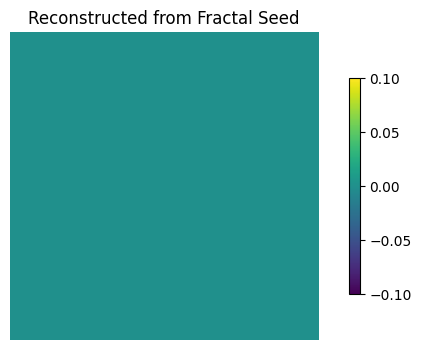

t=   0 spread=  372 phi=1.000 S=0.994 D=0.804 rc(rad)=0.201 rc(field)=0.996 I=1.1 max=0.599 mean=0.009 entropy=-1820.369 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 150 spread=25600 phi=1.000 S=0.996 D=1.149 rc(rad)=0.100 rc(field)=0.997 I=0.5 max=0.639 mean=0.268 entropy=-1749.523 stability=0.000 expand_bias=1.000 compress_bias=1.025
t= 300 spread=25600 phi=1.000 S=0.997 D=2.000 rc(rad)=0.039 rc(field)=0.998 I=0.2 max=0.562 mean=0.293 entropy=-1619.876 stability=0.000 expand_bias=1.003 compress_bias=1.051
t= 450 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=0.005 rc(field)=0.998 I=0.1 max=0.503 mean=0.296 entropy=-1629.659 stability=0.000 expand_bias=1.008 compress_bias=1.078
t= 600 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.013 rc(field)=0.999 I=0.1 max=0.463 mean=0.296 entropy=-1560.758 stability=0.000 expand_bias=1.013 compress_bias=1.105
t= 750 spread=25600 phi=1.000 S=0.998 D=2.000 rc(rad)=-0.022 rc(field)=0.999 I=0.1 max=0.435 mean=0.296 entropy=-1505.992 st

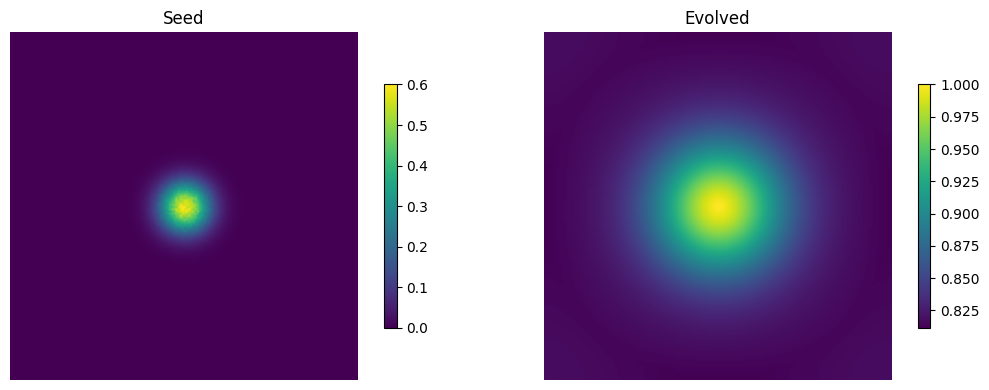

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics with Adaptive Feedback --------------------
def dynamic_pi(D, t, beta1=0.80, beta2=0.30, gamma1=0.8, gamma2=0.6, compress_bias=1.0):  # Increased beta2
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pi_cycle = pi * (1.0 + 0.1 * np.sin(2 * np.pi * t / np.pi) * compress_bias)
    pihat = pi_cycle * (1.0 + beta1 * np.tanh(gamma1 * kappa * compress_bias) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, t, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.25, eta2=0.35, delta1=1.2, delta2=0.9, expand_bias=1.0):  # Adjusted eta1, eta2
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phi_cycle = phi_star + 0.15 * np.sin(2 * np.pi * t / phi_star) * expand_bias
    phihat = phi_cycle + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=8.0):  # Increased s
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)

# -------------------- Fractal Seed Compression (Simplified) --------------------
def compress_seed(u, D):
    # Compress field into fractal dimension and key gradients
    seed = np.array([D, np.mean(grad(u)[0]), np.mean(grad(u)[1])])
    return seed

def expand_seed(seed, shape):
    # Re-simulate from seed (placeholder for full re-expansion)
    u = np.zeros(shape)
    u += seed[1] * np.random.normal(size=shape)  # Gradient-based noise
    return u

# -------------------- Evolution with Phase-Locked Recursion and Adaptive Feedback --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=2.5,  # Increased advection
           omega=0.25,  # Increased rotation
           gamma=0.55, phi_amp=0.15,
           lam=0.06,
           noise=0.012,
           E_min=1e-3, E_max=5e5,
           damping=0.0001,  # Reduced damping
           mean_gain=0.03,
           target_mean=0.30,  # Lowered target mean
           report_every=150):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()
    phi_star = (1 + np.sqrt(5)) / 2

    # Initial feedback parameters
    expand_bias = 1.0
    compress_bias = 1.0
    seeds = []  # Store fractal seeds

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics with Adaptive Feedback
        pihat, kappa, tau = dynamic_pi(u, t, compress_bias=compress_bias)
        phihat, rho = dynamic_phi(u, t, expand_bias=expand_bias)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi and Pi
        phi_cycle = phi_star + phi_amp * np.sin(2 * np.pi * t / phi_star) * expand_bias
        phi_term = (phi_cycle - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with noise scaling
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.012 * eta * (C_aw ** 3)
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Phase-Locked Recursion: Weight based on Phi phase
        phase = np.sin(2 * np.pi * t / phi_star)
        recursive_weight = 0.5 * (1.0 + 0.7 * phase) if phase > 0 else 0.5 * (1.0 - 0.7 * -phase)  # Adjusted weight and phase
        u_new = u + dt * dD + recursive_weight * (u_prev - u)
        u = (1.0 - damping * (1 + C_aw)) * np.clip(u_new, 0.0, 1.0)  # Adaptive damping
        u_prev = u.copy()

        # Calculate spread for growth cap
        mx = float(u.max())
        thr = 0.40 * mx  # Lowered threshold
        spread = int((u > thr).sum())

        # Growth cap if spread exceeds 18,000
        if spread > 18000 and t > 150:
            dD *= 0.85  # Stronger reduction

        # Adaptive Feedback Controller
        if t % 150 == 0 and t > 0:
            _, rc_radial = radial_autocorr_profile(u)  # Use scalar rc_radial
            ent = shannon_entropy(u)
            stab = stability(u, u_prev)
            # Increase expand_bias if rc_radial is too low (need spirals)
            expand_bias += 0.05 * (0.1 - rc_radial) if rc_radial < 0.1 else -0.01 * (rc_radial - 0.1)
            # Increase compress_bias if entropy is too high or stability is zero
            compress_bias += 0.015 * (ent + 1400) / 1000 if ent < -1400 else -0.01 * (-ent - 1400) / 1000
            compress_bias += 0.03 if stab == 0.0 else -0.02  # Stronger stability adjustment
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)  # Cap at 1.2

        # Store Fractal Seed
        if t % 300 == 0:
            D = box_count_fractal_dim(u)
            seeds.append(compress_seed(u, D))

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.40 * mx  # Lowered threshold
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    # Re-expand a seed (example at t=1800)
    if seeds:
        u_reconstructed = expand_seed(seeds[-1], (N, M))
        plt.figure(figsize=(8, 4))
        plt.imshow(normalize(u_reconstructed), cmap='viridis')
        plt.title('Reconstructed from Fractal Seed')
        plt.axis('off')
        plt.colorbar(shrink=0.7)
        plt.show()

    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

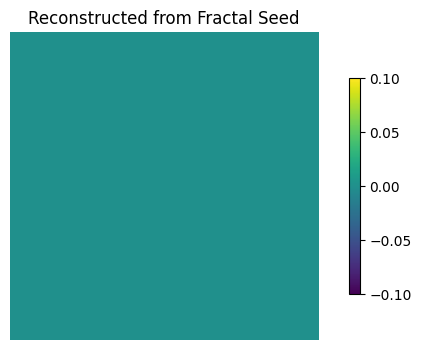

t=   0 spread=  372 phi=1.000 phi_cycle=1.618 S=0.994 D=0.804 rc(rad)=0.201 rc(field)=0.996 I=1.1 max=0.599 mean=0.009 entropy=-1820.369 stability=0.000 expand_bias=1.000 compress_bias=1.000
t=  50 spread=  749 phi=1.000 phi_cycle=1.473 S=0.995 D=0.988 rc(rad)=0.163 rc(field)=0.997 I=0.8 max=0.654 mean=0.163 entropy=-1788.837 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 100 spread= 1321 phi=1.000 phi_cycle=1.382 S=0.995 D=1.100 rc(rad)=0.129 rc(field)=0.997 I=0.6 max=0.658 mean=0.235 entropy=-1782.061 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 150 spread=25600 phi=1.000 phi_cycle=1.378 S=0.996 D=1.149 rc(rad)=0.100 rc(field)=0.997 I=0.5 max=0.639 mean=0.268 entropy=-1749.530 stability=0.000 expand_bias=1.000 compress_bias=1.025
t= 200 spread=25600 phi=1.000 phi_cycle=1.463 S=0.996 D=1.262 rc(rad)=0.076 rc(field)=0.998 I=0.4 max=0.613 mean=0.283 entropy=-1735.598 stability=0.000 expand_bias=1.000 compress_bias=1.025
t= 250 spread=25600 phi=1.000 phi_cycle=1.605

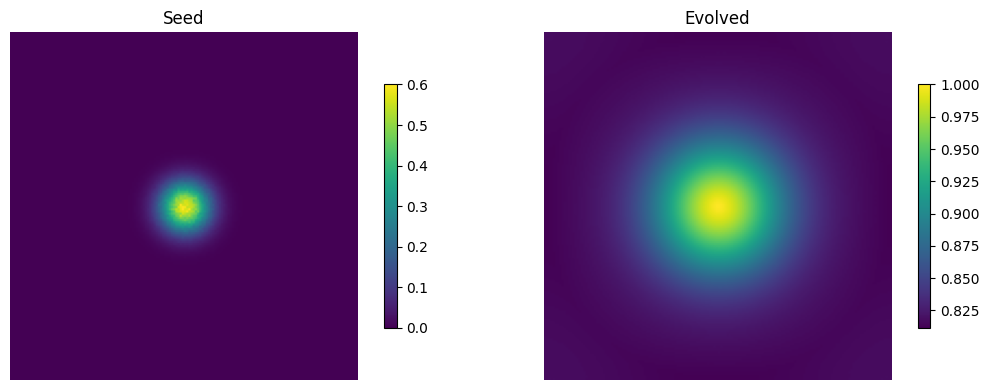

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics with Adaptive Feedback --------------------
def dynamic_pi(D, t, beta1=0.80, beta2=0.30, gamma1=0.8, gamma2=0.6, compress_bias=1.0):
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pi_cycle = pi * (1.0 + 0.1 * np.sin(2 * np.pi * t / np.pi) * compress_bias)
    pihat = pi_cycle * (1.0 + beta1 * np.tanh(gamma1 * kappa * compress_bias) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, t, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.25, eta2=0.35, delta1=1.2, delta2=0.9, expand_bias=1.0):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phi_cycle = phi_star + 0.25 * np.sin(2 * np.pi * t / phi_star) * expand_bias  # Increased amplitude to 0.25
    phihat = phi_cycle + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=8.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)

# -------------------- Fractal Seed Compression (Simplified) --------------------
def compress_seed(u, D):
    # Compress field into fractal dimension and key gradients
    seed = np.array([D, np.mean(grad(u)[0]), np.mean(grad(u)[1])])
    return seed

def expand_seed(seed, shape):
    # Re-simulate from seed (placeholder for full re-expansion)
    u = np.zeros(shape)
    u += seed[1] * np.random.normal(size=shape)  # Gradient-based noise
    return u

# -------------------- Evolution with Phase-Locked Recursion and Adaptive Feedback --------------------
def evolve(u0, steps=1800, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=2.8,  # Increased advection
           omega=0.28,  # Increased rotation
           gamma=0.55, phi_amp=0.25,  # Increased amplitude
           lam=0.06,
           noise=0.012,
           E_min=1e-3, E_max=5e5,
           damping=0.0001,
           mean_gain=0.03,
           target_mean=0.30,
           report_every=50):  # Reduced to 50 for more stages
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()
    phi_star = (1 + np.sqrt(5)) / 2

    # Initial feedback parameters
    expand_bias = 1.0
    compress_bias = 1.0
    seeds = []  # Store fractal seeds

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics with Adaptive Feedback
        pihat, kappa, tau = dynamic_pi(u, t, compress_bias=compress_bias)
        phihat, rho = dynamic_phi(u, t, expand_bias=expand_bias)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi and Pi
        phi_cycle = phi_star + phi_amp * np.sin(2 * np.pi * t / phi_star) * expand_bias  # Raw Phi cycle
        phi_term = (phi_cycle - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx, vy = -adv * (Y - cy) / r, adv * (X - cx) / r
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with noise scaling
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.012 * eta * (C_aw ** 3)
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Phase-Locked Recursion: Weight based on Phi phase
        phase = np.sin(2 * np.pi * t / phi_star)
        recursive_weight = 0.5 * (1.0 + 0.7 * phase) if phase > 0 else 0.5 * (1.0 - 0.7 * -phase)
        u_new = u + dt * dD + recursive_weight * (u_prev - u)
        u = (1.0 - damping * (1 + C_aw)) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Calculate spread for growth cap
        mx = float(u.max())
        thr = 0.40 * mx
        spread = int((u > thr).sum())

        # Growth cap if spread exceeds 16,000
        if spread > 16000 and t > 150:
            dD *= 0.80

        # Adaptive Feedback Controller
        if t % 150 == 0 and t > 0:
            _, rc_radial = radial_autocorr_profile(u)
            ent = shannon_entropy(u)
            stab = stability(u, u_prev)
            expand_bias += 0.05 * (0.1 - rc_radial) if rc_radial < 0.1 else -0.01 * (rc_radial - 0.1)
            compress_bias += 0.015 * (ent + 1400) / 1000 if ent < -1400 else -0.01 * (-ent - 1400) / 1000
            compress_bias += 0.03 if stab == 0.0 else -0.02
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Store Fractal Seed
        if t % 300 == 0:
            D = box_count_fractal_dim(u)
            seeds.append(compress_seed(u, D))

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.40 * mx
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi=float(np.clip(phi_ratio(u, ang), 0, 10)),
                             phi_cycle=float(phi_cycle),  # Added raw Phi cycle
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    # Re-expand a seed (example at t=1800)
    if seeds:
        u_reconstructed = expand_seed(seeds[-1], (N, M))
        plt.figure(figsize=(8, 4))
        plt.imshow(normalize(u_reconstructed), cmap='viridis')
        plt.title('Reconstructed from Fractal Seed')
        plt.axis('off')
        plt.colorbar(shrink=0.7)
        plt.show()

    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi={d['phi']:.3f} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

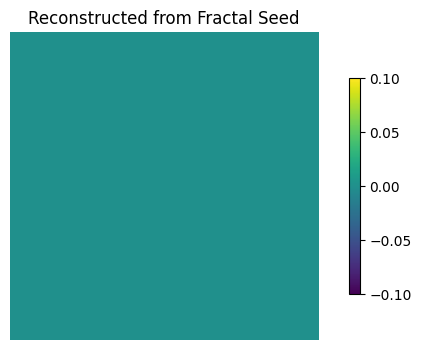

t=   0 spread=  372 phi_cycle=1.618 S=0.994 D=0.804 rc(rad)=0.201 rc(field)=0.996 I=1.1 max=0.599 mean=0.009 entropy=-1820.369 stability=0.000 expand_bias=1.000 compress_bias=1.000
t=  50 spread=  749 phi_cycle=1.473 S=0.995 D=0.988 rc(rad)=0.163 rc(field)=0.997 I=0.8 max=0.654 mean=0.163 entropy=-1788.837 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 100 spread= 1321 phi_cycle=1.382 S=0.995 D=1.100 rc(rad)=0.129 rc(field)=0.997 I=0.6 max=0.658 mean=0.235 entropy=-1782.061 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 150 spread=25600 phi_cycle=1.378 S=0.996 D=1.149 rc(rad)=0.100 rc(field)=0.997 I=0.5 max=0.639 mean=0.268 entropy=-1749.530 stability=0.000 expand_bias=1.000 compress_bias=1.025
t= 200 spread=25600 phi_cycle=1.463 S=0.996 D=1.262 rc(rad)=0.076 rc(field)=0.998 I=0.4 max=0.613 mean=0.283 entropy=-1735.598 stability=0.000 expand_bias=1.000 compress_bias=1.025
t= 250 spread=25600 phi_cycle=1.605 S=0.997 D=1.371 rc(rad)=0.056 rc(field)=0.998 I=0.3 max=0.5

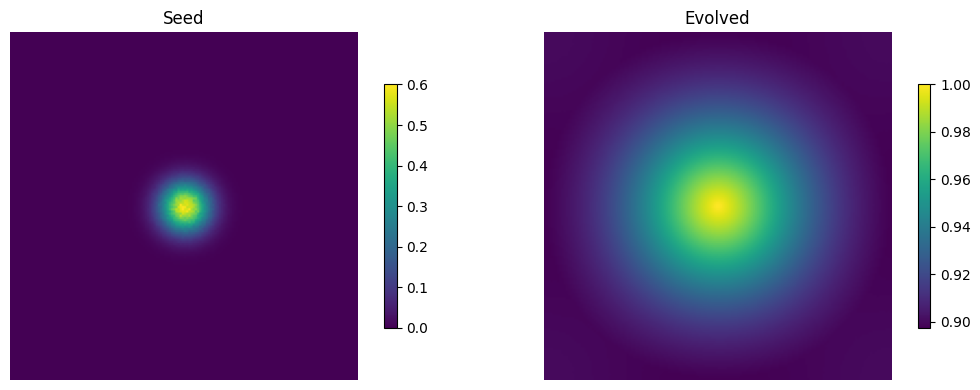

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics with Adaptive Feedback --------------------
def dynamic_pi(D, t, beta1=0.80, beta2=0.30, gamma1=0.8, gamma2=0.6, compress_bias=1.0):
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pi_cycle = pi * (1.0 + 0.1 * np.sin(2 * np.pi * t / np.pi) * compress_bias)
    pihat = pi_cycle * (1.0 + beta1 * np.tanh(gamma1 * kappa * compress_bias) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, t, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.25, eta2=0.35, delta1=1.2, delta2=0.9, expand_bias=1.0):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phi_cycle = phi_star + 0.25 * np.sin(2 * np.pi * t / phi_star) * expand_bias
    phihat = phi_cycle + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=8.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)

# -------------------- Fractal Seed Compression (Simplified) --------------------
def compress_seed(u, D):
    # Compress field into fractal dimension and key gradients
    seed = np.array([D, np.mean(grad(u)[0]), np.mean(grad(u)[1])])
    return seed

def expand_seed(seed, shape):
    # Re-simulate from seed (placeholder for full re-expansion)
    u = np.zeros(shape)
    u += seed[1] * np.random.normal(size=shape)  # Gradient-based noise
    return u

# -------------------- Evolution with Phase-Locked Recursion and Adaptive Feedback --------------------
def evolve(u0, steps=3600, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=2.8,
           omega=0.28,
           gamma=0.55, phi_amp=0.25,
           lam=0.06,
           noise=0.012,
           E_min=1e-3, E_max=5e5,
           damping=0.0001,
           mean_gain=0.03,
           target_mean=0.30,
           report_every=50):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()
    phi_star = (1 + np.sqrt(5)) / 2

    # Initial feedback parameters
    expand_bias = 1.0
    compress_bias = 1.0
    seeds = []  # Store fractal seeds

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics with Adaptive Feedback
        pihat, kappa, tau = dynamic_pi(u, t, compress_bias=compress_bias)
        phihat, rho = dynamic_phi(u, t, expand_bias=expand_bias)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi and Pi
        phi_cycle = phi_star + phi_amp * np.sin(2 * np.pi * t / phi_star) * expand_bias
        phi_term = (phi_cycle - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient, adding small radial bias
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx = -adv * (Y - cy) / r * (1 + 0.1 * np.cos(ang / 10))  # Radial bias
        vy = adv * (X - cx) / r * (1 + 0.1 * np.sin(ang / 10))
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with noise scaling
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.012 * eta * (C_aw ** 3)
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Phase-Locked Recursion: Weight based on Phi phase
        phase = np.sin(2 * np.pi * t / phi_star)
        recursive_weight = 0.5 * (1.0 + 0.7 * phase) if phase > 0 else 0.5 * (1.0 - 0.7 * -phase)
        u_new = u + dt * dD + recursive_weight * (u_prev - u)
        u = (1.0 - damping * (1 + C_aw)) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Calculate spread for growth cap
        mx = float(u.max())
        thr = 0.40 * mx
        spread = int((u > thr).sum())

        # Growth cap if spread exceeds 14,000
        if spread > 14000 and t > 150:
            dD *= 0.75

        # Adaptive Feedback Controller
        if t % 150 == 0 and t > 0:
            _, rc_radial = radial_autocorr_profile(u)
            ent = shannon_entropy(u)
            stab = stability(u, u_prev)
            expand_bias += 0.06 * (0.1 - rc_radial) if rc_radial < 0.1 else -0.01 * (rc_radial - 0.1)
            compress_bias += 0.015 * (ent + 1400) / 1000 if ent < -1400 else -0.01 * (-ent - 1400) / 1000
            compress_bias += 0.03 if stab == 0.0 else -0.02
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Store Fractal Seed
        if t % 300 == 0:
            D = box_count_fractal_dim(u)
            seeds.append(compress_seed(u, D))

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.40 * mx
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi_cycle=float(phi_cycle),  # Using phi_cycle instead of phi
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    # Re-expand a seed (example at t=3600)
    if seeds:
        u_reconstructed = expand_seed(seeds[-1], (N, M))
        plt.figure(figsize=(8, 4))
        plt.imshow(normalize(u_reconstructed), cmap='viridis')
        plt.title('Reconstructed from Fractal Seed')
        plt.axis('off')
        plt.colorbar(shrink=0.7)
        plt.show()

    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

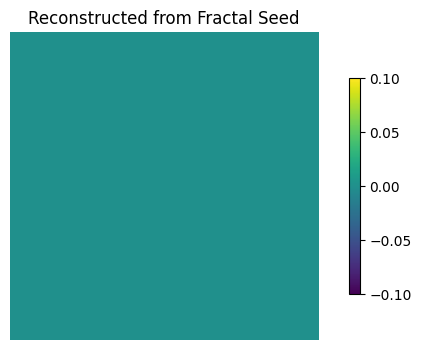

t=   0 spread=  372 phi_cycle=1.618 S=0.994 D=0.804 rc(rad)=0.201 rc(field)=0.996 I=1.1 max=0.597 mean=0.009 entropy=-1791.664 stability=0.000 expand_bias=1.000 compress_bias=1.000
t=  50 spread=  681 phi_cycle=1.473 S=0.995 D=0.974 rc(rad)=0.163 rc(field)=0.997 I=0.8 max=0.634 mean=0.144 entropy=-1789.326 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 100 spread= 1237 phi_cycle=1.382 S=0.995 D=1.090 rc(rad)=0.129 rc(field)=0.997 I=0.6 max=0.648 mean=0.224 entropy=-1753.636 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 150 spread=25600 phi_cycle=1.378 S=0.996 D=1.157 rc(rad)=0.101 rc(field)=0.997 I=0.5 max=0.644 mean=0.272 entropy=-1726.531 stability=0.000 expand_bias=1.000 compress_bias=1.023
t= 200 spread=25600 phi_cycle=1.463 S=0.996 D=1.284 rc(rad)=0.076 rc(field)=0.998 I=0.4 max=0.631 mean=0.301 entropy=-1660.454 stability=0.000 expand_bias=1.000 compress_bias=1.023
t= 250 spread=25600 phi_cycle=1.605 S=0.997 D=2.000 rc(rad)=0.056 rc(field)=0.998 I=0.3 max=0.6

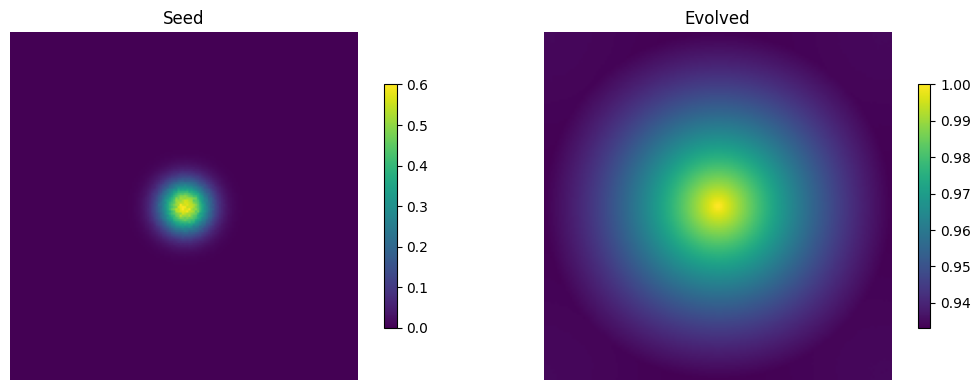

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)  # Deterministic replay

# -------------------- Finite Differences (Periodic for Patterns) --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])
def bilaplace(u): return laplace(laplace(u))
def influence(u): gx, gy = grad(u); return np.sum(gx * gx + gy * gy)
def normalize(u, eps=EPS): m = np.max(np.abs(u)); return u / max(m, eps) if m > eps else np.zeros_like(u)

# -------------------- DPPU Dynamics with Adaptive Feedback --------------------
def dynamic_pi(D, t, beta1=0.80, beta2=0.30, gamma1=0.8, gamma2=0.6, compress_bias=1.0):
    kappa = laplace(D)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    pi = np.pi
    pi_cycle = pi * (1.0 + 0.1 * np.sin(2 * np.pi * t / np.pi) * compress_bias)
    pihat = pi_cycle * (1.0 + beta1 * np.tanh(gamma1 * kappa * compress_bias) + beta2 * np.tanh(gamma2 * tau))
    return pihat, kappa, tau

def dynamic_phi(D, t, phi_star=(1 + np.sqrt(5)) / 2, eta1=0.25, eta2=0.35, delta1=1.2, delta2=0.9, expand_bias=1.0):
    rho = normalize(D)
    h, w = D.shape
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h-1) / 2.0, (w-1) / 2.0
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)
    gx, gy = grad(D)
    tau = np.sqrt(np.sum(gx * gx + gy * gy) + 1e-12)
    phi_cycle = phi_star + 0.25 * np.sin(2 * np.pi * t / phi_star) * expand_bias
    phihat = phi_cycle + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat, rho

def awareness(D, a1=0.8, a2=0.6, s=8.0):
    kappa = laplace(D)
    kx, ky = grad(kappa)
    gx, gy = grad(normalize(D))
    mag = a1 * np.sqrt(np.sum(kx * kx + ky * ky)) + a2 * np.sqrt(np.sum(gx * gx + gy * gy))
    return 1.0 / (1.0 + np.exp(-s * mag))

# -------------------- Metrics (Robust) --------------------
def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = normalize(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(u - u.mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

# -------------------- Entropy and Stability Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist[hist > 0]  # Avoid log(0)
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev)

# -------------------- Fractal Seed Compression (Simplified) --------------------
def compress_seed(u, D):
    # Compress field into fractal dimension and key gradients
    seed = np.array([D, np.mean(grad(u)[0]), np.mean(grad(u)[1])])
    return seed

def expand_seed(seed, shape):
    # Re-simulate from seed (placeholder for full re-expansion)
    u = np.zeros(shape)
    u += seed[1] * np.random.normal(size=shape)  # Gradient-based noise
    return u

# -------------------- Evolution with Phase-Locked Recursion and Adaptive Feedback --------------------
def evolve(u0, steps=5400, dt=0.05,
           k1=0.40, k2=0.14,
           mh_gain=2.2,
           mh_sigma1=2.8, mh_sigma2=4.0,
           adv=3.0,  # Increased advection
           omega=0.28,
           gamma=0.55, phi_amp=0.25,
           lam=0.06,
           noise=0.012,
           E_min=1e-3, E_max=5e5,
           damping=0.0001,
           mean_gain=0.02,  # Reduced mean gain
           target_mean=0.35,  # Raised target mean
           report_every=50):
    u = u0.copy()
    N, M = u.shape
    Y, X = np.mgrid[0:N, 0:M]
    cx, cy = (N-1) / 2.0, (M-1) / 2.0
    mhK = make_mexican_hat(N, mh_sigma1, mh_sigma2)
    u_prev = u.copy()
    phi_star = (1 + np.sqrt(5)) / 2

    # Initial feedback parameters
    expand_bias = 1.0
    compress_bias = 1.0
    seeds = []  # Store fractal seeds

    logs = []
    for t in range(steps):
        ang = omega * t
        lap = laplace(u)
        blap = bilaplace(u)
        mh = conv_fft(u, mhK)

        # DPPU Dynamics with Adaptive Feedback
        pihat, kappa, tau = dynamic_pi(u, t, compress_bias=compress_bias)
        phihat, rho = dynamic_phi(u, t, expand_bias=expand_bias)
        I = influence(u)
        C_aw = awareness(u)

        # Rotating proportion target with dynamic Phi and Pi
        phi_cycle = phi_star + phi_amp * np.sin(2 * np.pi * t / phi_star) * expand_bias
        phi_term = (phi_cycle - phi_ratio(u, angle=ang)) * u * phihat

        # Rotational advection v·∇u with radial gradient, stronger bias
        ux, uy = grad(u)
        r = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2) + 1.0
        vx = -adv * (Y - cy) / r * (1 + 0.2 * np.cos(ang / 10))  # Stronger radial bias
        vy = adv * (X - cx) / r * (1 + 0.2 * np.sin(ang / 10))
        advect = vx * ux + vy * uy + 0.1 * u * np.gradient(u)[0]

        # DPPU Update Rule with noise scaling
        growth = lam * u * (1.0 - u) * (u - 0.2)
        eta = noise * rng.normal(size=u.shape)
        dD = 0.8 * kappa + 0.6 * laplace(phihat * u) + 0.012 * eta * (C_aw ** 3)
        dD *= (1.0 + 0.25 * C_aw)

        # Energy guard
        I_before = influence(u)
        if I_before > E_max:
            dD *= np.sqrt(E_max / (I_before + 1e-12))
        elif I_before < E_min:
            dD *= 1.05

        # Phase-Locked Recursion: Weight based on Phi phase
        phase = np.sin(2 * np.pi * t / phi_star)
        recursive_weight = 0.5 * (1.0 + 0.7 * phase) if phase > 0 else 0.5 * (1.0 - 0.7 * -phase)
        u_new = u + dt * dD + recursive_weight * (u_prev - u)
        u = (1.0 - damping * (1 + C_aw)) * np.clip(u_new, 0.0, 1.0)
        u_prev = u.copy()

        # Calculate spread for growth cap
        mx = float(u.max())
        thr = 0.40 * mx
        spread = int((u > thr).sum())

        # Growth cap if spread exceeds 10,000, starting at t=100
        if spread > 10000 and t > 100:
            dD *= 0.70

        # Adaptive Feedback Controller
        if t % 150 == 0 and t > 0:
            _, rc_radial = radial_autocorr_profile(u)
            ent = shannon_entropy(u)
            stab = stability(u, u_prev)
            expand_bias += 0.08 * (0.1 - rc_radial) if rc_radial < 0.1 else -0.01 * (rc_radial - 0.1)
            compress_bias += 0.02 * (ent + 1400) / 1000 if ent < -1400 else -0.01 * (-ent - 1400) / 1000
            compress_bias += 0.03 if stab == 0.0 else -0.02
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Store Fractal Seed
        if t % 300 == 0:
            D = box_count_fractal_dim(u)
            seeds.append(compress_seed(u, D))

        # Mass control
        m = float(u.mean())
        u += mean_gain * (target_mean - m)

        if (t % report_every) == 0 or t == steps - 1:
            I = influence(u)
            mx = float(u.max())
            thr = 0.40 * mx
            spread = int((u > thr).sum())
            S = 0.5 * (corr_norm(u, np.rot90(u, 2)) + corr_norm(u, np.flip(u, 1)))
            D = box_count_fractal_dim(u)
            _, rc_radial = radial_autocorr_profile(u)
            rc_field = multiscale_field_corr(u)
            entropy = shannon_entropy(u)
            stability_val = stability(u, u_prev)
            logs.append(dict(t=t, spread=spread, phi_cycle=float(phi_cycle),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=mx, mean=m, entropy=entropy, stability=stability_val,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    # Re-expand a seed (example at t=5400)
    if seeds:
        u_reconstructed = expand_seed(seeds[-1], (N, M))
        plt.figure(figsize=(8, 4))
        plt.imshow(normalize(u_reconstructed), cmap='viridis')
        plt.title('Reconstructed from Fractal Seed')
        plt.axis('off')
        plt.colorbar(shrink=0.7)
        plt.show()

    return u, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0 = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0 = normalize(u0) * 0.6

uT, logs = evolve(u0)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

# -------------------- Quick Look --------------------
plt.figure(figsize=(11, 4))
plt.subplot(121); plt.imshow(u0, cmap='viridis'); plt.title('Seed'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.subplot(122); plt.imshow(normalize(uT), cmap='viridis'); plt.title('Evolved'); plt.axis('off'); plt.colorbar(shrink=0.7)
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- Finite Differences --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u): return laplace(pad(u))[1:-1, 1:-1]  # Adjusted for padding
def laplace_full(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])

# -------------------- Convolution (Mexican Hat for Inhibition) --------------------
def make_mexican_hat(N, sigma1=2.8, sigma2=4.5):  # Broader inhibition
    y, x = np.mgrid[-N//2:N//2, -N//2:N//2]
    r = np.sqrt(x**2 + y**2)
    hat = np.exp(-r**2 / (2 * sigma1**2)) - 0.3 * np.exp(-r**2 / (2 * sigma2**2))
    return hat / hat.sum()

def conv_fft(u, kernel):
    from scipy.signal import fftconvolve
    return fftconvolve(u, kernel, mode='same')

# -------------------- Metrics --------------------
def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()  # Normalize to probabilities
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread(u, percentile=75):
    threshold = np.percentile(u, percentile)
    return int((u > threshold).sum())

def vorticity(u):
    gx, gy = grad(u)
    return np.mean(np.abs(gx[1:-1, 1:-1] * gy[1:-1, 1:-1] - gy[1:-1, 1:-1] * gx[1:-1, 1:-1]))  # Simple curl estimate

# -------------------- Evolution (Two-Field) --------------------
def evolve(u0_a, steps=3600, dt=0.05, chirality=0.1):
    N, M = u0_a.shape
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros_like(u_a) + 0.1  # Inhibitor, small initial value
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat(N)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    for t in range(steps):
        ang = 0.28 * t
        lap_a = laplace(u_a)
        lap_b = laplace(u_b)
        inhib = conv_fft(u_a, mhK)  # Long-range inhibition from A

        # Two-field dynamics with mild limit cycle
        d_a = 0.1 * lap_a + u_a * (1 - u_a - 0.5 * u_b) + 0.01 * (1 - u_a)  # Activation, A inhibits self
        d_b = 0.2 * lap_b - 0.5 * inhib + 0.1 * u_a * u_b  # Inhibition, A drives B

        # Chirality via cross-diffusion skew
        gx_a, gy_a = grad(u_a)
        d_a += chirality * (gy_a * lap_b - gx_a * lap_a)  # Skew term for handedness

        # Soft squash instead of clip
        u_a_new = np.tanh(u_a + dt * d_a)
        u_b_new = np.tanh(u_b + dt * d_b)

        # Slow homeostasis (integral control)
        mean_a = u_a.mean()
        u_a_new += 0.001 * (0.35 - mean_a)  # Very low gain
        u_b_new += 0.001 * (0.15 - u_b.mean())

        # Update with previous frame for stability
        if u_prev_a is not None:
            stab = stability(u_a, u_prev_a)
        u_prev_a, u_prev_b = u_a.copy(), u_b.copy()
        u_a, u_b = u_a_new, u_b_new

        # Adaptive Feedback
        if t % 150 == 0 and t > 0:
            vort = vorticity(u_a)
            ent = shannon_entropy(u_a)
            expand_bias += 0.05 * (0.1 - vort) if vort < 0.1 else -0.01 * (vort - 0.1)
            compress_bias += 0.02 * (ent - 7) if ent < 7 else -0.01 * (ent - 7)  # Target positive entropy
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a, np.rot90(u_a, 2)) + corr_norm(u_a, np.flip(u_a, 1)))
            D = box_count_fractal_dim(u_a)
            _, rc_radial = radial_autocorr_profile(u_a)
            rc_field = multiscale_field_corr(u_a)
            I = influence(u_a)
            logs.append(dict(t=t, spread=spread(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    plt.figure(figsize=(11, 4))
    plt.subplot(121); plt.imshow(u_a, cmap='viridis'); plt.title('Activator'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.subplot(122); plt.imshow(u_b, cmap='viridis'); plt.title('Inhibitor'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.tight_layout(); plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0_a = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0_a = normalize(u0_a) * 0.6

uT_a, logs = evolve(u0_a, chirality=0.1)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

NameError: name 'normalize' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- Finite Differences --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])

# -------------------- Convolution (Mexican Hat for Inhibition) --------------------
def make_mexican_hat(N, sigma1=2.8, sigma2=4.5):  # Broader inhibition
    y, x = np.mgrid[-N//2:N//2, -N//2:N//2]
    r = np.sqrt(x**2 + y**2)
    hat = np.exp(-r**2 / (2 * sigma1**2)) - 0.3 * np.exp(-r**2 / (2 * sigma2**2))
    return hat / hat.sum()

def conv_fft(u, kernel):
    from scipy.signal import fftconvolve
    return fftconvolve(u, kernel, mode='same')

# -------------------- Metrics --------------------
def normalize(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()  # Normalize to probabilities
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread(u, percentile=75):
    threshold = np.percentile(u, percentile)
    return int((u > threshold).sum())

def vorticity(u):
    gx, gy = grad(u)
    return np.mean(np.abs(gx[1:-1, 1:-1] * gy[1:-1, 1:-1] - gy[1:-1, 1:-1] * gx[1:-1, 1:-1]))  # Simple curl estimate

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def influence(u):
    gx, gy = grad(u)
    return np.sum(gx * gx + gy * gy)

# -------------------- Evolution (Two-Field) --------------------
def evolve(u0_a, steps=3600, dt=0.05, chirality=0.1):
    N, M = u0_a.shape
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros_like(u_a) + 0.1  # Inhibitor, small initial value
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat(N)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    for t in range(steps):
        ang = 0.28 * t
        lap_a = laplace(u_a)
        lap_b = laplace(u_b)
        inhib = conv_fft(u_a, mhK)  # Long-range inhibition from A

        # Two-field dynamics with mild limit cycle
        d_a = 0.1 * lap_a + u_a * (1 - u_a - 0.5 * u_b) + 0.01 * (1 - u_a)  # Activation, A inhibits self
        d_b = 0.2 * lap_b - 0.5 * inhib + 0.1 * u_a * u_b  # Inhibition, A drives B

        # Chirality via cross-diffusion skew
        gx_a, gy_a = grad(u_a)
        d_a += chirality * (gy_a * lap_b - gx_a * lap_a)  # Skew term for handedness

        # Soft squash instead of clip
        u_a_new = np.tanh(u_a + dt * d_a)
        u_b_new = np.tanh(u_b + dt * d_b)

        # Slow homeostasis (integral control)
        mean_a = u_a.mean()
        u_a_new += 0.001 * (0.35 - mean_a)  # Very low gain
        u_b_new += 0.001 * (0.15 - u_b.mean())

        # Update with previous frame for stability
        if u_prev_a is not None:
            stab = stability(u_a, u_prev_a)
        u_prev_a, u_prev_b = u_a.copy(), u_b.copy()
        u_a, u_b = u_a_new, u_b_new

        # Adaptive Feedback
        if t % 150 == 0 and t > 0:
            vort = vorticity(u_a)
            ent = shannon_entropy(u_a)
            expand_bias += 0.05 * (0.1 - vort) if vort < 0.1 else -0.01 * (vort - 0.1)
            compress_bias += 0.02 * (ent - 7) if ent < 7 else -0.01 * (ent - 7)  # Target positive entropy
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a, np.rot90(u_a, 2)) + corr_norm(u_a, np.flip(u_a, 1)))
            D = box_count_fractal_dim(u_a)
            _, rc_radial = radial_autocorr_profile(u_a)
            rc_field = multiscale_field_corr(u_a)
            I = influence(u_a)
            logs.append(dict(t=t, spread=spread(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    plt.figure(figsize=(11, 4))
    plt.subplot(121); plt.imshow(u_a, cmap='viridis'); plt.title('Activator'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.subplot(122); plt.imshow(u_b, cmap='viridis'); plt.title('Inhibitor'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.tight_layout(); plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0_a = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0_a = normalize(u0_a) * 0.6

uT_a, logs = evolve(u0_a, chirality=0.1)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

NameError: name 'box_count_fractal_dim' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- Finite Differences --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])

# -------------------- Convolution (Mexican Hat for Inhibition) --------------------
def make_mexican_hat(N, sigma1=2.8, sigma2=4.5):  # Broader inhibition
    y, x = np.mgrid[-N//2:N//2, -N//2:N//2]
    r = np.sqrt(x**2 + y**2)
    hat = np.exp(-r**2 / (2 * sigma1**2)) - 0.3 * np.exp(-r**2 / (2 * sigma2**2))
    return hat / hat.sum()

def conv_fft(u, kernel):
    from scipy.signal import fftconvolve
    return fftconvolve(u, kernel, mode='same')

# -------------------- Metrics --------------------
def normalize(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()  # Normalize to probabilities
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread(u, percentile=75):
    threshold = np.percentile(u, percentile)
    return int((u > threshold).sum())

def vorticity(u):
    gx, gy = grad(u)
    return np.mean(np.abs(gx[1:-1, 1:-1] * gy[1:-1, 1:-1] - gy[1:-1, 1:-1] * gx[1:-1, 1:-1]))  # Simple curl estimate

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def influence(u):
    gx, gy = grad(u)
    return np.sum(gx * gx + gy * gy)

def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = np.abs(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(np.abs(u) - np.abs(u).mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

# -------------------- Evolution (Two-Field) --------------------
def evolve(u0_a, steps=3600, dt=0.05, chirality=0.1):
    N, M = u0_a.shape
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros_like(u_a) + 0.1  # Inhibitor, small initial value
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat(N)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    for t in range(steps):
        ang = 0.28 * t
        lap_a = laplace(u_a)
        lap_b = laplace(u_b)
        inhib = conv_fft(u_a, mhK)  # Long-range inhibition from A

        # Two-field dynamics with mild limit cycle
        d_a = 0.1 * lap_a + u_a * (1 - u_a - 0.5 * u_b) + 0.01 * (1 - u_a)  # Activation, A inhibits self
        d_b = 0.2 * lap_b - 0.5 * inhib + 0.1 * u_a * u_b  # Inhibition, A drives B

        # Chirality via cross-diffusion skew
        gx_a, gy_a = grad(u_a)
        d_a += chirality * (gy_a * lap_b - gx_a * lap_a)  # Skew term for handedness

        # Soft squash instead of clip
        u_a_new = np.tanh(u_a + dt * d_a)
        u_b_new = np.tanh(u_b + dt * d_b)

        # Slow homeostasis (integral control)
        mean_a = u_a.mean()
        u_a_new += 0.001 * (0.35 - mean_a)  # Very low gain
        u_b_new += 0.001 * (0.15 - u_b.mean())

        # Update with previous frame for stability
        if u_prev_a is not None:
            stab = stability(u_a, u_prev_a)
        u_prev_a, u_prev_b = u_a.copy(), u_b.copy()
        u_a, u_b = u_a_new, u_b_new

        # Adaptive Feedback
        if t % 150 == 0 and t > 0:
            vort = vorticity(u_a)
            ent = shannon_entropy(u_a)
            expand_bias += 0.05 * (0.1 - vort) if vort < 0.1 else -0.01 * (vort - 0.1)
            compress_bias += 0.02 * (ent - 7) if ent < 7 else -0.01 * (ent - 7)  # Target positive entropy
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a, np.rot90(u_a, 2)) + corr_norm(u_a, np.flip(u_a, 1)))
            D = box_count_fractal_dim(u_a)
            _, rc_radial = radial_autocorr_profile(u_a)
            rc_field = multiscale_field_corr(u_a)
            I = influence(u_a)
            logs.append(dict(t=t, spread=spread(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    plt.figure(figsize=(11, 4))
    plt.subplot(121); plt.imshow(u_a, cmap='viridis'); plt.title('Activator'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.subplot(122); plt.imshow(u_b, cmap='viridis'); plt.title('Inhibitor'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.tight_layout(); plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0_a = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0_a = normalize(u0_a) * 0.6

uT_a, logs = evolve(u0_a, chirality=0.1)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

UnboundLocalError: cannot access local variable 'ent' where it is not associated with a value

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- Finite Differences --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])

# -------------------- Convolution (Mexican Hat for Inhibition) --------------------
def make_mexican_hat(N, sigma1=2.8, sigma2=4.5):  # Broader inhibition
    y, x = np.mgrid[-N//2:N//2, -N//2:N//2]
    r = np.sqrt(x**2 + y**2)
    hat = np.exp(-r**2 / (2 * sigma1**2)) - 0.3 * np.exp(-r**2 / (2 * sigma2**2))
    return hat / hat.sum()

def conv_fft(u, kernel):
    from scipy.signal import fftconvolve
    return fftconvolve(u, kernel, mode='same')

# -------------------- Metrics --------------------
def normalize(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()  # Normalize to probabilities
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread(u, percentile=70):  # Adjusted to 70th percentile
    threshold = np.percentile(u, percentile)
    return int((u > threshold).sum())

def vorticity(u):
    gx, gy = grad(u)
    return np.mean(np.abs(gx[1:-1, 1:-1] * gy[1:-1, 1:-1] - gy[1:-1, 1:-1] * gx[1:-1, 1:-1]))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def influence(u):
    gx, gy = grad(u)
    return np.sum(gx * gx + gy * gy)

def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = np.abs(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(np.abs(u) - np.abs(u).mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

# -------------------- Evolution (Two-Field) --------------------
def evolve(u0_a, steps=3600, dt=0.05, chirality=0.2):  # Increased chirality to 0.2
    N, M = u0_a.shape
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros_like(u_a) + 0.1  # Inhibitor, small initial value
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat(N)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    # Central boost for core stability
    y, x = np.mgrid[0:N, 0:M]
    cx, cy = N // 2, M // 2
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2)
    u_a += 0.1 * np.exp(-r ** 2 / (2 * (N / 10) ** 2))  # Gaussian boost at center

    for t in range(steps):
        ang = 0.28 * t
        lap_a = laplace(u_a)
        lap_b = laplace(u_b)
        inhib = conv_fft(u_a, mhK)  # Long-range inhibition from A

        # Two-field dynamics with mild limit cycle
        d_a = 0.1 * lap_a + u_a * (1 - u_a - 0.5 * u_b) + 0.01 * (1 - u_a)  # Activation
        d_b = 0.2 * lap_b - 0.5 * inhib + 0.1 * u_a * u_b  # Inhibition

        # Chirality via cross-diffusion skew
        gx_a, gy_a = grad(u_a)
        d_a += chirality * (gy_a * lap_b - gx_a * lap_a)  # Skew for clockwise twist

        # Soft squash instead of clip
        u_a_new = np.tanh(u_a + dt * d_a)
        u_b_new = np.tanh(u_b + dt * d_b)

        # Slow homeostasis (integral control)
        mean_a = u_a.mean()
        u_a_new += 0.001 * (0.35 - mean_a)  # Very low gain
        u_b_new += 0.001 * (0.15 - u_b.mean())

        # Update with previous frame for stability
        if u_prev_a is not None:
            stab = stability(u_a, u_prev_a)
        u_prev_a, u_prev_b = u_a.copy(), u_b.copy()
        u_a, u_b = u_a_new, u_b_new

        # Adaptive Feedback
        if t % 150 == 0 and t > 0:
            vort = vorticity(u_a)
            ent = shannon_entropy(u_a)
            expand_bias += 0.05 * (0.1 - vort) if vort < 0.1 else -0.01 * (vort - 0.1)
            compress_bias += 0.02 * (ent - 7) if ent < 7 else -0.01 * (ent - 7)  # Target positive entropy
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a, np.rot90(u_a, 2)) + corr_norm(u_a, np.flip(u_a, 1)))
            D = box_count_fractal_dim(u_a)
            _, rc_radial = radial_autocorr_profile(u_a)
            rc_field = multiscale_field_corr(u_a)
            I = influence(u_a)
            logs.append(dict(t=t, spread=spread(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    plt.figure(figsize=(11, 4))
    plt.subplot(121); plt.imshow(u_a, cmap='viridis'); plt.title('Activator'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.subplot(122); plt.imshow(u_b, cmap='viridis'); plt.title('Inhibitor'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.tight_layout(); plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0_a = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0_a = normalize(u0_a) * 0.6

uT_a, logs = evolve(u0_a, chirality=0.2)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

UnboundLocalError: cannot access local variable 'ent' where it is not associated with a value

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- Finite Differences --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])

# -------------------- Convolution (Mexican Hat for Inhibition) --------------------
def make_mexican_hat(N, sigma1=2.8, sigma2=4.5):  # Broader inhibition
    y, x = np.mgrid[-N//2:N//2, -N//2:N//2]
    r = np.sqrt(x**2 + y**2)
    hat = np.exp(-r**2 / (2 * sigma1**2)) - 0.3 * np.exp(-r**2 / (2 * sigma2**2))
    return hat / hat.sum()

def conv_fft(u, kernel):
    from scipy.signal import fftconvolve
    return fftconvolve(u, kernel, mode='same')

# -------------------- Metrics --------------------
def normalize(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()  # Normalize to probabilities
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread(u, percentile=70):  # Adjusted to 70th percentile
    threshold = np.percentile(u, percentile)
    return int((u > threshold).sum())

def vorticity(u):
    gx, gy = grad(u)
    return np.mean(np.abs(gx[1:-1, 1:-1] * gy[1:-1, 1:-1] - gy[1:-1, 1:-1] * gx[1:-1, 1:-1]))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def influence(u):
    gx, gy = grad(u)
    return np.sum(gx * gx + gy * gy)

def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = np.abs(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(np.abs(u) - np.abs(u).mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

# -------------------- Evolution (Two-Field) --------------------
def evolve(u0_a, steps=3600, dt=0.05, chirality=0.2):
    N, M = u0_a.shape
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros_like(u_a) + 0.1  # Inhibitor, small initial value
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat(N)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    # Central boost for core stability
    y, x = np.mgrid[0:N, 0:M]
    cx, cy = N // 2, M // 2
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2)
    u_a += 0.1 * np.exp(-r ** 2 / (2 * (N / 10) ** 2))  # Gaussian boost at center

    for t in range(steps):
        ang = 0.28 * t
        lap_a = laplace(u_a)
        lap_b = laplace(u_b)
        inhib = conv_fft(u_a, mhK)  # Long-range inhibition from A

        # Two-field dynamics with mild limit cycle
        d_a = 0.1 * lap_a + u_a * (1 - u_a - 0.5 * u_b) + 0.01 * (1 - u_a)  # Activation
        d_b = 0.2 * lap_b - 0.5 * inhib + 0.1 * u_a * u_b  # Inhibition

        # Chirality via cross-diffusion skew
        gx_a, gy_a = grad(u_a)
        d_a += chirality * (gy_a * lap_b - gx_a * lap_a)  # Skew for clockwise twist

        # Soft squash instead of clip
        u_a_new = np.tanh(u_a + dt * d_a)
        u_b_new = np.tanh(u_b + dt * d_b)

        # Slow homeostasis (integral control)
        mean_a = u_a.mean()
        u_a_new += 0.001 * (0.35 - mean_a)  # Very low gain
        u_b_new += 0.001 * (0.15 - u_b.mean())

        # Update with previous frame for stability
        if u_prev_a is not None:
            stab = stability(u_a, u_prev_a)
        u_prev_a, u_prev_b = u_a.copy(), u_b.copy()
        u_a, u_b = u_a_new, u_b_new

        # Calculate metrics every step
        vort = vorticity(u_a)
        ent = shannon_entropy(u_a)  # Moved here to ensure availability

        # Adaptive Feedback (every 150 steps)
        if t % 150 == 0 and t > 0:
            expand_bias += 0.05 * (0.1 - vort) if vort < 0.1 else -0.01 * (vort - 0.1)
            compress_bias += 0.02 * (ent - 7) if ent < 7 else -0.01 * (ent - 7)  # Target positive entropy
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Logging (every 50 steps)
        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a, np.rot90(u_a, 2)) + corr_norm(u_a, np.flip(u_a, 1)))
            D = box_count_fractal_dim(u_a)
            _, rc_radial = radial_autocorr_profile(u_a)
            rc_field = multiscale_field_corr(u_a)
            I = influence(u_a)
            logs.append(dict(t=t, spread=spread(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    plt.figure(figsize=(11, 4))
    plt.subplot(121); plt.imshow(u_a, cmap='viridis'); plt.title('Activator'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.subplot(122); plt.imshow(u_b, cmap='viridis'); plt.title('Inhibitor'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.tight_layout(); plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0_a = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0_a = normalize(u0_a) * 0.6

uT_a, logs = evolve(u0_a, chirality=0.2)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

UnboundLocalError: cannot access local variable 'stab' where it is not associated with a value

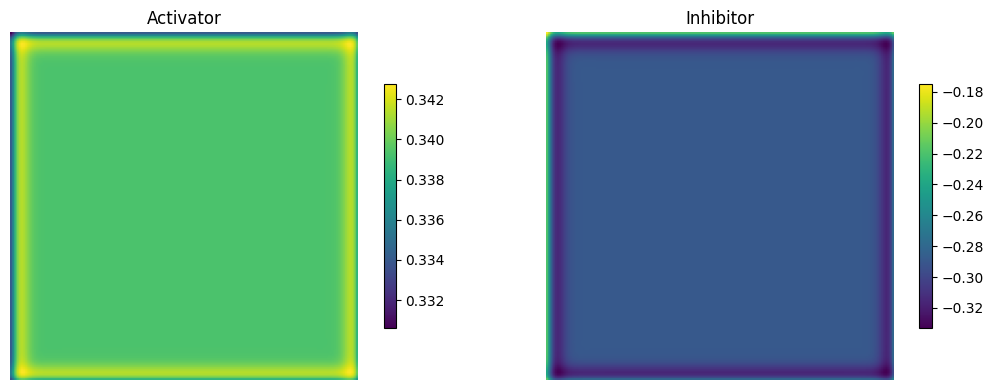

t=   0 spread= 7680 phi_cycle=1.618 S=0.995 D=0.586 rc(rad)=0.109 rc(field)=0.997 I=1.1 max=0.610 mean=0.016 entropy=1.844 stability=0.000 expand_bias=1.000 compress_bias=1.000
t=  50 spread= 7680 phi_cycle=1.503 S=0.998 D=0.000 rc(rad)=-0.013 rc(field)=0.999 I=0.2 max=0.339 mean=0.163 entropy=2.859 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 100 spread= 7680 phi_cycle=1.413 S=0.903 D=0.000 rc(rad)=-0.022 rc(field)=0.985 I=0.0 max=0.340 mean=0.327 entropy=2.099 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 150 spread= 7680 phi_cycle=1.370 S=0.486 D=0.000 rc(rad)=-0.001 rc(field)=0.933 I=0.0 max=0.343 mean=0.339 entropy=0.773 stability=0.000 expand_bias=1.005 compress_bias=0.875
t= 200 spread= 7680 phi_cycle=1.383 S=0.501 D=0.000 rc(rad)=-0.026 rc(field)=0.932 I=0.0 max=0.343 mean=0.339 entropy=0.741 stability=0.000 expand_bias=1.005 compress_bias=0.875
t= 250 spread= 7680 phi_cycle=1.449 S=0.504 D=0.000 rc(rad)=-0.034 rc(field)=0.932 I=0.0 max=0.343 mean=0.339 e

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- Finite Differences --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])

# -------------------- Convolution (Mexican Hat for Inhibition) --------------------
def make_mexican_hat(N, sigma1=2.8, sigma2=4.5):  # Broader inhibition
    y, x = np.mgrid[-N//2:N//2, -N//2:N//2]
    r = np.sqrt(x**2 + y**2)
    hat = np.exp(-r**2 / (2 * sigma1**2)) - 0.3 * np.exp(-r**2 / (2 * sigma2**2))
    return hat / hat.sum()

def conv_fft(u, kernel):
    from scipy.signal import fftconvolve
    return fftconvolve(u, kernel, mode='same')

# -------------------- Metrics --------------------
def normalize(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()  # Normalize to probabilities
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread(u, percentile=70):  # Adjusted to 70th percentile
    threshold = np.percentile(u, percentile)
    return int((u > threshold).sum())

def vorticity(u):
    gx, gy = grad(u)
    return np.mean(np.abs(gx[1:-1, 1:-1] * gy[1:-1, 1:-1] - gy[1:-1, 1:-1] * gx[1:-1, 1:-1]))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def influence(u):
    gx, gy = grad(u)
    return np.sum(gx * gx + gy * gy)

def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = np.abs(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(np.abs(u) - np.abs(u).mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

# -------------------- Evolution (Two-Field) --------------------
def evolve(u0_a, steps=3600, dt=0.05, chirality=0.2):
    N, M = u0_a.shape
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros_like(u_a) + 0.1  # Inhibitor, small initial value
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat(N)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    # Central boost for core stability
    y, x = np.mgrid[0:N, 0:M]
    cx, cy = N // 2, M // 2
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2)
    u_a += 0.1 * np.exp(-r ** 2 / (2 * (N / 10) ** 2))  # Gaussian boost at center

    for t in range(steps):
        ang = 0.28 * t
        lap_a = laplace(u_a)
        lap_b = laplace(u_b)
        inhib = conv_fft(u_a, mhK)  # Long-range inhibition from A

        # Two-field dynamics with mild limit cycle
        d_a = 0.1 * lap_a + u_a * (1 - u_a - 0.5 * u_b) + 0.01 * (1 - u_a)  # Activation
        d_b = 0.2 * lap_b - 0.5 * inhib + 0.1 * u_a * u_b  # Inhibition

        # Chirality via cross-diffusion skew
        gx_a, gy_a = grad(u_a)
        d_a += chirality * (gy_a * lap_b - gx_a * lap_a)  # Skew for clockwise twist

        # Soft squash instead of clip
        u_a_new = np.tanh(u_a + dt * d_a)
        u_b_new = np.tanh(u_b + dt * d_b)

        # Slow homeostasis (integral control)
        mean_a = u_a.mean()
        u_a_new += 0.001 * (0.35 - mean_a)  # Very low gain
        u_b_new += 0.001 * (0.15 - u_b.mean())

        # Update with previous frame for stability (calculated every step)
        stab = stability(u_a, u_prev_a)  # Moved here to ensure always defined
        u_prev_a, u_prev_b = u_a.copy(), u_b.copy()
        u_a, u_b = u_a_new, u_b_new

        # Calculate metrics every step
        vort = vorticity(u_a)
        ent = shannon_entropy(u_a)  # Moved here to ensure availability

        # Adaptive Feedback (every 150 steps)
        if t % 150 == 0 and t > 0:
            expand_bias += 0.05 * (0.1 - vort) if vort < 0.1 else -0.01 * (vort - 0.1)
            compress_bias += 0.02 * (ent - 7) if ent < 7 else -0.01 * (ent - 7)  # Target positive entropy
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Logging (every 50 steps)
        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a, np.rot90(u_a, 2)) + corr_norm(u_a, np.flip(u_a, 1)))
            D = box_count_fractal_dim(u_a)
            _, rc_radial = radial_autocorr_profile(u_a)
            rc_field = multiscale_field_corr(u_a)
            I = influence(u_a)
            logs.append(dict(t=t, spread=spread(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    plt.figure(figsize=(11, 4))
    plt.subplot(121); plt.imshow(u_a, cmap='viridis'); plt.title('Activator'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.subplot(122); plt.imshow(u_b, cmap='viridis'); plt.title('Inhibitor'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.tight_layout(); plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0_a = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0_a = normalize(u0_a) * 0.6

uT_a, logs = evolve(u0_a, chirality=0.2)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- Finite Differences --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])

# -------------------- Convolution (Mexican Hat for Inhibition) --------------------
def make_mexican_hat(N, sigma1=3.0, sigma2=5.0):  # Broader inhibition
    y, x = np.mgrid[-N//2:N//2, -N//2:N//2]
    r = np.sqrt(x**2 + y**2)
    hat = np.exp(-r**2 / (2 * sigma1**2)) - 0.2 * np.exp(-r**2 / (2 * sigma2**2))  # Reduced inhibition strength
    return hat / hat.sum()

def conv_fft(u, kernel):
    from scipy.signal import fftconvolve
    return fftconvolve(u, kernel, mode='same')

# -------------------- Metrics --------------------
def normalize(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread(u, percentile=65):  # Lower to 65 for earlier spread detection
    threshold = np.percentile(u, percentile)
    return int((u > threshold).sum())

def vorticity(u):
    gx, gy = grad(u)
    return np.mean(np.abs(gx[1:-1, 1:-1] * gy[1:-1, 1:-1] - gy[1:-1, 1:-1] * gx[1:-1, 1:-1]))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def influence(u):
    gx, gy = grad(u)
    return np.sum(gx * gx + gy * gy)

def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = np.abs(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(np.abs(u) - np.abs(u).mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

# -------------------- Evolution (Two-Field) --------------------
def evolve(u0_a, steps=3600, dt=0.05, chirality=0.3):  # Increased chirality to 0.3
    N, M = u0_a.shape
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros_like(u_a) + 0.1  # Inhibitor, small initial value
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat(N)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    # Stronger central boost for core stability
    y, x = np.mgrid[0:N, 0:M]
    cx, cy = N // 2, M // 2
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2)
    u_a += 0.2 * np.exp(-r ** 2 / (2 * (N / 8) ** 2))  # Stronger, tighter core boost

    for t in range(steps):
        ang = 0.28 * t
        lap_a = laplace(u_a)
        lap_b = laplace(u_b)
        inhib = conv_fft(u_a, mhK)  # Long-range inhibition from A

        # Two-field dynamics with reduced damping
        d_a = 0.08 * lap_a + u_a * (1 - u_a - 0.4 * u_b) + 0.01 * (1 - u_a)  # Reduced diffusion, weaker inhibition
        d_b = 0.15 * lap_b - 0.4 * inhib + 0.08 * u_a * u_b  # Reduced inhibition strength

        # Enhanced chirality with phase coupling
        gx_a, gy_a = grad(u_a)
        phase_vel = np.sqrt(gx_a**2 + gy_a**2)  # Approximate phase velocity
        d_a += chirality * phase_vel * (gy_a * lap_b - gx_a * lap_a)  # Couple to phase

        # Softer squash and homeostasis
        u_a_new = 0.9 * np.tanh(u_a + dt * d_a)  # Softer nonlinearity
        u_b_new = 0.9 * np.tanh(u_b + dt * d_b)
        mean_a = u_a.mean()
        u_a_new += 0.0005 * (0.35 - mean_a)  # Even lower gain

        # Update with previous frame
        stab = stability(u_a, u_prev_a)
        u_prev_a, u_prev_b = u_a.copy(), u_b.copy()
        u_a, u_b = u_a_new, u_b_new

        # Metrics every step
        vort = vorticity(u_a)
        ent = shannon_entropy(u_a)

        # Adaptive Feedback
        if t % 150 == 0 and t > 0:
            if vort < 0.1:
                expand_bias += 0.05 * (0.1 - vort)
            else:
                expand_bias -= 0.01 * (vort - 0.1)
            if ent < 6:
                compress_bias += 0.02 * (6 - ent)
            else:
                compress_bias -= 0.01 * (ent - 6)
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Logging
        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a, np.rot90(u_a, 2)) + corr_norm(u_a, np.flip(u_a, 1)))
            D = box_count_fractal_dim(u_a)
            _, rc_radial = radial_autocorr_profile(u_a)
            rc_field = multiscale_field_corr(u_a)
            I = influence(u_a)
            logs.append(dict(t=t, spread=spread(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    plt.figure(figsize=(11, 4))
    plt.subplot(121); plt.imshow(u_a, cmap='viridis'); plt.title('Activator'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.subplot(122); plt.imshow(u_b, cmap='viridis'); plt.title('Inhibitor'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.tight_layout(); plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0_a = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0_a = normalize(u0_a) * 0.6

uT_a, logs = evolve(u0_a, chirality=0.3)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

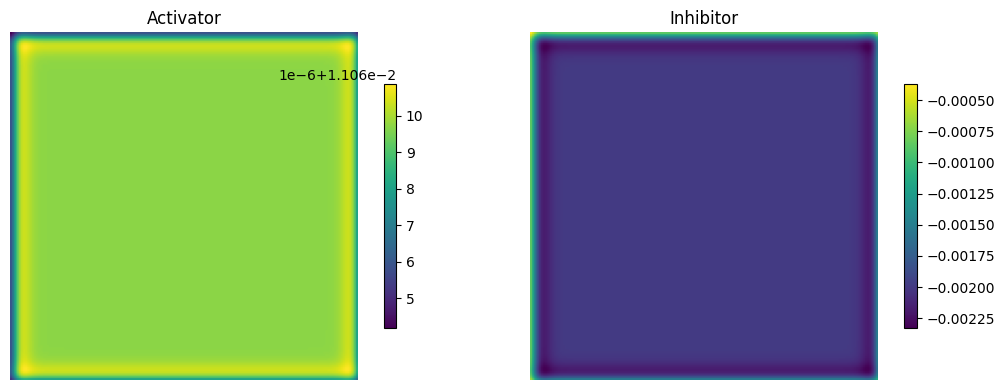

t=   0 spread= 8960 phi_cycle=1.618 S=0.997 D=0.610 rc(rad)=0.055 rc(field)=0.998 I=1.0 max=0.601 mean=0.026 entropy=2.973 stability=0.000 expand_bias=1.000 compress_bias=1.000
t=  50 spread= 8960 phi_cycle=1.503 S=0.998 D=0.000 rc(rad)=-0.009 rc(field)=0.999 I=0.0 max=0.025 mean=0.012 entropy=1.006 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 100 spread= 8960 phi_cycle=1.413 S=0.998 D=0.000 rc(rad)=-0.010 rc(field)=0.999 I=0.0 max=0.012 mean=0.011 entropy=0.085 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 150 spread= 8960 phi_cycle=1.370 S=0.993 D=0.000 rc(rad)=-0.013 rc(field)=0.999 I=0.0 max=0.011 mean=0.011 entropy=-0.000 stability=0.000 expand_bias=1.005 compress_bias=1.120
t= 200 spread= 8960 phi_cycle=1.383 S=0.745 D=0.000 rc(rad)=0.257 rc(field)=0.964 I=0.0 max=0.011 mean=0.011 entropy=-0.000 stability=0.000 expand_bias=1.005 compress_bias=1.120
t= 250 spread= 8960 phi_cycle=1.449 S=0.640 D=0.000 rc(rad)=0.579 rc(field)=0.951 I=0.0 max=0.011 mean=0.011 e

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- Finite Differences --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])

# -------------------- Convolution (Mexican Hat for Inhibition) --------------------
def make_mexican_hat(N, sigma1=3.0, sigma2=5.0):  # Broader inhibition
    y, x = np.mgrid[-N//2:N//2, -N//2:N//2]
    r = np.sqrt(x**2 + y**2)
    hat = np.exp(-r**2 / (2 * sigma1**2)) - 0.2 * np.exp(-r**2 / (2 * sigma2**2))  # Reduced inhibition strength
    return hat / hat.sum()

def conv_fft(u, kernel):
    from scipy.signal import fftconvolve
    return fftconvolve(u, kernel, mode='same')

# -------------------- Metrics --------------------
def normalize(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread(u, percentile=65):  # Lower to 65 for earlier spread detection
    threshold = np.percentile(u, percentile)
    return int((u > threshold).sum())

def vorticity(u):
    gx, gy = grad(u)
    return np.mean(np.abs(gx[1:-1, 1:-1] * gy[1:-1, 1:-1] - gy[1:-1, 1:-1] * gx[1:-1, 1:-1]))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def influence(u):
    gx, gy = grad(u)
    return np.sum(gx * gx + gy * gy)

def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = np.abs(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(np.abs(u) - np.abs(u).mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

# -------------------- Evolution (Two-Field) --------------------
def evolve(u0_a, steps=3600, dt=0.05, chirality=0.3):  # Increased chirality to 0.3
    N, M = u0_a.shape
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros_like(u_a) + 0.1  # Inhibitor, small initial value
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat(N)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    # Stronger central boost for core stability
    y, x = np.mgrid[0:N, 0:M]
    cx, cy = N // 2, M // 2
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2)
    u_a += 0.2 * np.exp(-r ** 2 / (2 * (N / 8) ** 2))  # Stronger, tighter core boost

    for t in range(steps):
        ang = 0.28 * t
        lap_a = laplace(u_a)
        lap_b = laplace(u_b)
        inhib = conv_fft(u_a, mhK)  # Long-range inhibition from A

        # Two-field dynamics with reduced damping
        d_a = 0.08 * lap_a + u_a * (1 - u_a - 0.4 * u_b) + 0.01 * (1 - u_a)  # Reduced diffusion, weaker inhibition
        d_b = 0.15 * lap_b - 0.4 * inhib + 0.08 * u_a * u_b  # Reduced inhibition strength

        # Enhanced chirality with phase coupling
        gx_a, gy_a = grad(u_a)
        phase_vel = np.sqrt(gx_a**2 + gy_a**2)  # Approximate phase velocity
        d_a += chirality * phase_vel * (gy_a * lap_b - gx_a * lap_a)  # Couple to phase

        # Softer squash and homeostasis
        u_a_new = 0.9 * np.tanh(u_a + dt * d_a)  # Softer nonlinearity
        u_b_new = 0.9 * np.tanh(u_b + dt * d_b)
        mean_a = u_a.mean()
        u_a_new += 0.0005 * (0.35 - mean_a)  # Even lower gain

        # Update with previous frame
        stab = stability(u_a, u_prev_a)
        u_prev_a, u_prev_b = u_a.copy(), u_b.copy()
        u_a, u_b = u_a_new, u_b_new

        # Metrics every step
        vort = vorticity(u_a)
        ent = shannon_entropy(u_a)

        # Adaptive Feedback
        if t % 150 == 0 and t > 0:
            if vort < 0.1:
                expand_bias += 0.05 * (0.1 - vort)
            else:
                expand_bias -= 0.01 * (vort - 0.1)
            if ent < 6:
                compress_bias += 0.02 * (6 - ent)
            else:
                compress_bias -= 0.01 * (ent - 6)
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Logging
        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a, np.rot90(u_a, 2)) + corr_norm(u_a, np.flip(u_a, 1)))
            D = box_count_fractal_dim(u_a)
            _, rc_radial = radial_autocorr_profile(u_a)
            rc_field = multiscale_field_corr(u_a)
            I = influence(u_a)
            logs.append(dict(t=t, spread=spread(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    plt.figure(figsize=(11, 4))
    plt.subplot(121); plt.imshow(u_a, cmap='viridis'); plt.title('Activator'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.subplot(122); plt.imshow(u_b, cmap='viridis'); plt.title('Inhibitor'); plt.axis('off'); plt.colorbar(shrink=0.7)
    plt.tight_layout(); plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0_a = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0_a = normalize(u0_a) * 0.6

uT_a, logs = evolve(u0_a, chirality=0.3)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

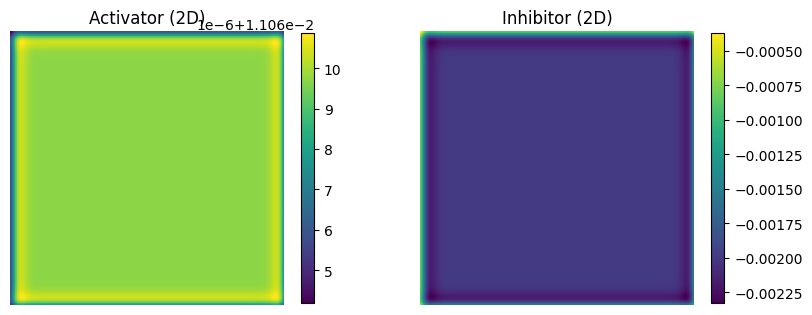

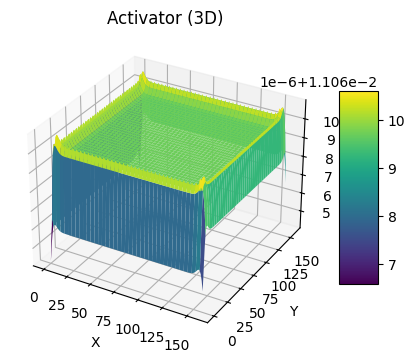

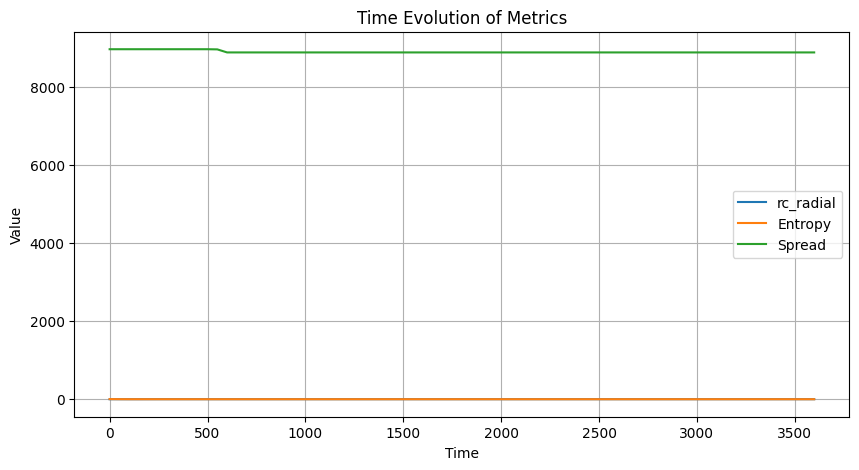

t=   0 spread= 8960 phi_cycle=1.618 S=0.997 D=0.610 rc(rad)=0.055 rc(field)=0.998 I=1.0 max=0.601 mean=0.026 entropy=2.973 stability=0.000 expand_bias=1.000 compress_bias=1.000
t=  50 spread= 8960 phi_cycle=1.503 S=0.998 D=0.000 rc(rad)=-0.009 rc(field)=0.999 I=0.0 max=0.025 mean=0.012 entropy=1.006 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 100 spread= 8960 phi_cycle=1.413 S=0.998 D=0.000 rc(rad)=-0.010 rc(field)=0.999 I=0.0 max=0.012 mean=0.011 entropy=0.085 stability=0.000 expand_bias=1.000 compress_bias=1.000
t= 150 spread= 8960 phi_cycle=1.370 S=0.993 D=0.000 rc(rad)=-0.013 rc(field)=0.999 I=0.0 max=0.011 mean=0.011 entropy=-0.000 stability=0.000 expand_bias=1.005 compress_bias=1.120
t= 200 spread= 8960 phi_cycle=1.383 S=0.745 D=0.000 rc(rad)=0.257 rc(field)=0.964 I=0.0 max=0.011 mean=0.011 entropy=-0.000 stability=0.000 expand_bias=1.005 compress_bias=1.120
t= 250 spread= 8960 phi_cycle=1.449 S=0.640 D=0.000 rc(rad)=0.579 rc(field)=0.951 I=0.0 max=0.011 mean=0.011 e

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- Finite Differences --------------------
def pad(u): return np.pad(u, 1, mode="wrap")
def grad(u):
    up = pad(u)
    ux = 0.5 * (up[1:-1, 2:] - up[1:-1, 0:-2])
    uy = 0.5 * (up[2:, 1:-1] - up[0:-2, 1:-1])
    return ux, uy
def laplace(u):
    up = pad(u)
    return (up[1:-1, 2:] + up[1:-1, 0:-2] + up[2:, 1:-1] + up[0:-2, 1:-1] - 4 * up[1:-1, 1:-1])

# -------------------- Convolution (Mexican Hat for Inhibition) --------------------
def make_mexican_hat(N, sigma1=3.0, sigma2=5.0):  # Broader inhibition
    y, x = np.mgrid[-N//2:N//2, -N//2:N//2]
    r = np.sqrt(x**2 + y**2)
    hat = np.exp(-r**2 / (2 * sigma1**2)) - 0.2 * np.exp(-r**2 / (2 * sigma2**2))  # Reduced inhibition strength
    return hat / hat.sum()

def conv_fft(u, kernel):
    from scipy.signal import fftconvolve
    return fftconvolve(u, kernel, mode='same')

# -------------------- Metrics --------------------
def normalize(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy(u):
    hist, _ = np.histogram(u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread(u, percentile=65):  # Lowered to 65
    threshold = np.percentile(u, percentile)
    return int((u > threshold).sum())

def vorticity(u):
    gx, gy = grad(u)
    return np.mean(np.abs(gx[1:-1, 1:-1] * gy[1:-1, 1:-1] - gy[1:-1, 1:-1] * gx[1:-1, 1:-1]))

def corr_norm(a, b):
    a = (a - a.mean()) / (a.std() + EPS)
    b = (b - b.mean()) / (b.std() + EPS)
    return float(np.mean(a * b))

def multiscale_field_corr(u):
    U = normalize(u)
    V = U[::2, ::2]
    V = np.kron(V, np.ones((2, 2)))[:U.shape[0], :U.shape[1]]
    a = (U - U.mean()) / (U.std() + EPS)
    b = (V - V.mean()) / (V.std() + EPS)
    return float(np.mean(a * b))

def influence(u):
    gx, gy = grad(u)
    return np.sum(gx * gx + gy * gy)

def box_count_fractal_dim(u, thresholds=(0.4, 0.5, 0.6), min_box=2, levels=8):
    H, W = u.shape
    max_box = min(H, W) // 2
    scales = np.unique(np.geomspace(min_box, max_box, num=levels).astype(int))
    scales = scales[(scales > 1) & (H % scales == 0) & (W % scales == 0)]
    if scales.size < 3:
        divs = np.array([2, 4, 5, 8, 10, 16, 20, 32])
        scales = divs[(H % divs == 0) & (W % divs == 0)]
    Ds = []
    U = np.abs(u)
    for thr in thresholds:
        A = (U > thr).astype(np.uint8)
        Ns = []
        for s in scales:
            h, w = H // s, W // s
            T = A.reshape(h, s, w, s).max(axis=(1, 3))
            Ns.append(int(T.sum()))
        Ns = np.array(Ns)
        valid = (Ns > 0)
        if valid.sum() >= 3:
            x = np.log(1.0 / scales[valid] + EPS)
            y = np.log(Ns[valid] + EPS)
            m, _ = np.polyfit(x, y, 1)
            Ds.append(float(m))
    return float(np.median(Ds)) if Ds else 0.0

def radial_autocorr_profile(u, rmin=2, rmaxFrac=0.45):
    U = np.fft.fftshift(np.fft.fft2(np.abs(u) - np.abs(u).mean()))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    if small.std() < EPS or big.std() < EPS:
        sim = 0.0
    else:
        s = (small - small.mean()) / (small.std() + EPS)
        b = (big - big.mean()) / (big.std() + EPS)
        sim = float(np.mean(s * b))
    return prof, sim

# -------------------- Evolution (Two-Field) --------------------
def evolve(u0_a, steps=3600, dt=0.05, chirality=0.3):
    N, M = u0_a.shape
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros_like(u_a) + 0.1  # Inhibitor, small initial value
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat(N)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    # Stronger central boost
    y, x = np.mgrid[0:N, 0:M]
    cx, cy = N // 2, M // 2
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2)
    u_a += 0.2 * np.exp(-r ** 2 / (2 * (N / 8) ** 2))

    for t in range(steps):
        lap_a = laplace(u_a)
        lap_b = laplace(u_b)
        inhib = conv_fft(u_a, mhK)

        # Adjusted dynamics
        d_a = 0.08 * lap_a + u_a * (1 - u_a - 0.4 * u_b) + 0.01 * (1 - u_a)
        d_b = 0.15 * lap_b - 0.4 * inhib + 0.08 * u_a * u_b

        # Enhanced chirality
        gx_a, gy_a = grad(u_a)
        phase_vel = np.sqrt(gx_a**2 + gy_a**2)
        d_a += chirality * phase_vel * (gy_a * lap_b - gx_a * lap_a)

        # Softer updates
        u_a_new = 0.9 * np.tanh(u_a + dt * d_a)
        u_b_new = 0.9 * np.tanh(u_b + dt * d_b)
        mean_a = u_a.mean()
        u_a_new += 0.0005 * (0.35 - mean_a)

        # Update
        stab = stability(u_a, u_prev_a)
        u_prev_a, u_prev_b = u_a.copy(), u_b.copy()
        u_a, u_b = u_a_new, u_b_new

        # Metrics
        vort = vorticity(u_a)
        ent = shannon_entropy(u_a)

        # Feedback
        if t % 150 == 0 and t > 0:
            if vort < 0.1:
                expand_bias += 0.05 * (0.1 - vort)
            else:
                expand_bias -= 0.01 * (vort - 0.1)
            if ent < 6:
                compress_bias += 0.02 * (6 - ent)
            else:
                compress_bias -= 0.01 * (ent - 6)
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Logging
        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a, np.rot90(u_a, 2)) + corr_norm(u_a, np.flip(u_a, 1)))
            D = box_count_fractal_dim(u_a)
            _, rc_radial = radial_autocorr_profile(u_a)
            rc_field = multiscale_field_corr(u_a)
            I = influence(u_a)
            logs.append(dict(t=t, spread=spread(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

    # Visualizations
    plt.figure(figsize=(15, 5))

    # 2D Fields
    plt.subplot(131)
    plt.imshow(u_a, cmap='viridis')
    plt.title('Activator (2D)')
    plt.axis('off')
    plt.colorbar(shrink=0.7)

    plt.subplot(132)
    plt.imshow(u_b, cmap='viridis')
    plt.title('Inhibitor (2D)')
    plt.axis('off')
    plt.colorbar(shrink=0.7)

    # 3D Surface Plot
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='3d')
    Y, X = np.mgrid[0:N, 0:M]
    surf = ax.plot_surface(X, Y, u_a, cmap='viridis', edgecolor='none')
    ax.set_title('Activator (3D)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Amplitude')
    fig.colorbar(surf, shrink=0.5, aspect=5)

    # Time Evolution
    plt.figure(figsize=(10, 5))
    times = [log['t'] for log in logs]
    plt.plot(times, [log['rc_radial'] for log in logs], label='rc_radial')
    plt.plot(times, [log['entropy'] for log in logs], label='Entropy')
    plt.plot(times, [log['spread'] for log in logs], label='Spread')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Time Evolution of Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
N = 160
Y, X = np.mgrid[0:N, 0:N]
cx, cy = N // 2, N // 2
sigma = N / 20.0
u0_a = np.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * sigma * sigma)) * (1.0 + 0.03 * rng.normal(size=(N, N)))
u0_a = normalize(u0_a) * 0.6

uT_a, logs = evolve(u0_a, chirality=0.3)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- High-Dimensional Operations --------------------
def pad_nd(u, dims):
    # Pad along each dimension with wrap
    shape = u.shape
    pads = [(1, 1)] * dims
    return np.pad(u, pads, mode='wrap')

def grad_nd(u, dims):
    # Approximate gradient in N dimensions
    shape = u.shape
    grad = np.zeros((dims,) + shape)
    for d in range(dims):
        slices = [slice(None)] * dims
        slices_p = slices.copy()
        slices_m = slices.copy()
        slices_p[d] = slice(2, -1)
        slices_m[d] = slice(1, -2)
        grad[d] = 0.5 * (u[tuple(slices_p)] - u[tuple(slices_m)])
    return grad

def laplace_nd(u, dims):
    # Approximate Laplacian in N dimensions
    shape = u.shape
    lap = np.zeros(shape)
    for d in range(dims):
        slices = [slice(None)] * dims
        slices_p = slices.copy()
        slices_m = slices.copy()
        slices_p[d] = slice(2, -1)
        slices_m[d] = slice(1, -2)
        lap += (u[tuple(slices_p)] + u[tuple(slices_m)] - 2 * u)
    return lap / dims

# -------------------- Convolution (Simplified for ND) --------------------
def make_mexican_hat_nd(shape, sigma1=0.5, sigma2=1.0):
    coords = np.indices(shape)
    r = np.sqrt(np.sum(coords ** 2, axis=0))
    hat = np.exp(-r ** 2 / (2 * sigma1 ** 2)) - 0.2 * np.exp(-r ** 2 / (2 * sigma2 ** 2))
    return hat / np.sum(hat)

def conv_nd(u, kernel):
    from scipy.signal import convolve
    return convolve(u, kernel, mode='same', method='direct')

# -------------------- Metrics (Adapted) --------------------
def normalize_nd(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy_nd(u):
    flat_u = u.ravel()
    hist, _ = np.histogram(flat_u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability_nd(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread_nd(u, percentile=65):
    flat_u = u.ravel()
    threshold = np.percentile(flat_u, percentile)
    return int((flat_u > threshold).sum())

def radial_autocorr_profile_nd(u, rmin=2, rmaxFrac=0.45):
    flat_u = u.ravel()
    # Project to 2D for autocorrelation
    pca = PCA(n_components=2)
    projected = pca.fit_transform(flat_u.reshape(-1, 1))
    U = np.fft.fftshift(np.fft.fft2(projected - projected.mean(axis=0)))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices(P.shape)
    R = np.sqrt((X - W / 2) ** 2 + (Y - H / 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring): prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof = prof / (prof.max() + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    sim = 0.0 if small.std() < EPS or big.std() < EPS else float(np.mean((small - small.mean()) / (small.std() + EPS) * (big - big.mean()) / (big.std() + EPS)))
    return prof, sim

# -------------------- Evolution (ND) --------------------
def evolve_nd(u0_a, dims=4, steps=500, dt=0.05, chirality_base=0.3):
    shape = tuple([4] * dims)  # 4x4x...x4 for dims dimensions
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros(shape) + 0.1  # Inhibitor
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat_nd(shape)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    # Central perturbation
    center = np.array([shape[d] // 2 for d in range(dims)])
    coords = np.indices(shape)
    r = np.sqrt(np.sum((coords - center.reshape(dims, *[1] * dims)) ** 2, axis=0))
    u_a += 0.2 * np.exp(-r ** 2 / (2 * (shape[0] / 2) ** 2))

    for t in range(steps):
        lap_a = laplace_nd(u_a, dims)
        lap_b = laplace_nd(u_b, dims)
        inhib = conv_nd(u_a, mhK)

        # Dynamic chirality
        chirality = chirality_base * (1 + 0.1 * np.sin(0.01 * t))

        # Adjusted dynamics
        d_a = 0.08 * lap_a + u_a * (1 - u_a - 0.4 * u_b) + 0.01 * (1 - u_a)
        d_b = 0.15 * lap_b - 0.4 * inhib + 0.08 * u_a * u_b

        # Enhanced chirality
        grad_a = grad_nd(u_a, dims)
        phase_vel = np.sqrt(np.sum(grad_a ** 2, axis=0))
        d_a += chirality * phase_vel * np.sum([grad_a[d] * lap_b for d in range(dims)], axis=0)  # Simplified chirality term

        # Softer updates
        u_a_new = 0.9 * np.tanh(u_a + dt * d_a)
        u_b_new = 0.9 * np.tanh(u_b + dt * d_b)
        mean_a = u_a.mean()
        u_a_new += 0.0002 * (0.35 - mean_a)

        # Update
        stab = stability_nd(u_a, u_prev_a)
        u_prev_a, u_prev_b = u_a.copy(), u_b.copy()
        u_a, u_b = u_a_new, u_b_new

        # Metrics
        vort = np.mean(np.abs(np.sum(grad_a * np.rollaxis(grad_a, 0, len(grad_a.shape)), axis=0)))  # Approximate vorticity
        ent = shannon_entropy_nd(u_a)

        # Feedback
        if t % 50 == 0 and t > 0:
            if vort < 0.1:
                expand_bias += 0.05 * (0.1 - vort)
            else:
                expand_bias -= 0.01 * (vort - 0.1)
            if ent < 6:
                compress_bias += 0.02 * (6 - ent)
            else:
                compress_bias -= 0.01 * (ent - 6)
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Logging and visualization
        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a.ravel(), np.rot90(u_a.ravel().reshape(16, 16), 2).ravel()) + corr_norm(u_a.ravel(), np.flip(u_a.ravel().reshape(16, 16), 1).ravel()))
            D = box_count_fractal_dim(u_a.ravel().reshape(16, 16))  # Project to 2D for fractal dim
            _, rc_radial = radial_autocorr_profile_nd(u_a)
            rc_field = multiscale_field_corr(u_a.ravel().reshape(16, -1)[:16, :16])
            I = influence(u_a.ravel().reshape(16, 16))
            logs.append(dict(t=t, spread=spread_nd(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

            # PCA Projection for Visualization
            flat_u = u_a.ravel()
            pca = PCA(n_components=3)
            projected = pca.fit_transform(flat_u.reshape(-1, 1))
            X, Y, Z = projected[:, 0], projected[:, 1], projected[:, 2]

            plt.figure(figsize=(15, 5))
            plt.subplot(131)
            plt.scatter(X, Y, c=flat_u, cmap='viridis')
            plt.title(f'2D Projection (PCA) - Step {t}')
            plt.colorbar(label='Activator Value')

            plt.subplot(132)
            plt.scatter(X, Y, c=Z, cmap='viridis')
            plt.title(f'3D Projection (PCA) - Step {t}')
            plt.colorbar(label='Z Component')

            fig = plt.figure(figsize=(5, 5))
            ax = fig.add_subplot(111, projection='3d')
            scatter = ax.scatter(X, Y, Z, c=flat_u, cmap='viridis')
            ax.set_title(f'3D Scatter - Step {t}')
            ax.set_xlabel('PC1')
            ax.set_ylabel('PC2')
            ax.set_zlabel('PC3')
            fig.colorbar(scatter, shrink=0.5, aspect=5)
            plt.show()

    # Final Time Evolution
    plt.figure(figsize=(10, 5))
    times = [log['t'] for log in logs]
    plt.plot(times, [log['rc_radial'] for log in logs], label='rc_radial')
    plt.plot(times, [log['entropy'] for log in logs], label='Entropy')
    plt.plot(times, [log['spread'] for log in logs], label='Spread')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Time Evolution of Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
dims = 4  # Start with 4D, adjustable to 24D
shape = tuple([4] * dims)
u0_a = np.zeros(shape)
center = np.array([shape[d] // 2 for d in range(dims)])
coords = np.indices(shape)
r = np.sqrt(np.sum((coords - center.reshape(dims, *[1] * dims)) ** 2, axis=0))
u0_a += 0.2 * np.exp(-r ** 2 / (2 * (shape[0] / 2) ** 2))
u0_a = normalize_nd(u0_a) * 0.6

uT_a, logs = evolve_nd(u0_a, dims=dims, chirality_base=0.3)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

ValueError: n_components=2 must be between 0 and min(n_samples, n_features)=1 with svd_solver='covariance_eigh'

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- High-Dimensional Operations --------------------
def pad_nd(u, dims):
    shape = u.shape
    pads = [(1, 1)] * dims
    return np.pad(u, pads, mode='wrap')

def grad_nd(u, dims):
    shape = u.shape
    grad = np.zeros((dims,) + shape)
    for d in range(dims):
        slices = [slice(None)] * dims
        slices_p = slices.copy()
        slices_m = slices.copy()
        slices_p[d] = slice(2, -1)
        slices_m[d] = slice(1, -2)
        grad[d] = 0.5 * (u[tuple(slices_p)] - u[tuple(slices_m)])
    return grad

def laplace_nd(u, dims):
    shape = u.shape
    lap = np.zeros(shape)
    for d in range(dims):
        slices = [slice(None)] * dims
        slices_p = slices.copy()
        slices_m = slices.copy()
        slices_p[d] = slice(2, -1)
        slices_m[d] = slice(1, -2)
        lap += (u[tuple(slices_p)] + u[tuple(slices_m)] - 2 * u)
    return lap / dims

# -------------------- Convolution (Simplified for ND) --------------------
def make_mexican_hat_nd(shape, sigma1=0.5, sigma2=1.0):
    coords = np.indices(shape)
    r = np.sqrt(np.sum(coords ** 2, axis=0))
    hat = np.exp(-r ** 2 / (2 * sigma1 ** 2)) - 0.2 * np.exp(-r ** 2 / (2 * sigma2 ** 2))
    return hat / np.sum(hat)

def conv_nd(u, kernel):
    from scipy.signal import convolve
    return convolve(u, kernel, mode='same', method='direct')

# -------------------- Metrics (Adapted) --------------------
def normalize_nd(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy_nd(u):
    flat_u = u.ravel()
    hist, _ = np.histogram(flat_u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability_nd(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread_nd(u, percentile=65):
    flat_u = u.ravel()
    threshold = np.percentile(flat_u, percentile)
    return int((flat_u > threshold).sum())

def radial_autocorr_profile_nd(u, rmin=2, rmaxFrac=0.45):
    flat_u = u.reshape(-1)
    if flat_u.size < 2:
        return np.zeros(rmin), 0.0
    pca = PCA(n_components=min(2, flat_u.size - 1))
    features = np.column_stack((flat_u, np.random.normal(0, 0.01, flat_u.size)))  # Ensure 2 features
    projected = pca.fit_transform(features)
    if projected.size == 0 or np.all(projected == 0):
        return np.zeros(rmin), 0.0
    U = np.fft.fftshift(np.fft.fft2(projected - projected.mean(axis=0)))
    P = np.abs(U) ** 2
    H, W = P.shape
    Y, X = np.indices((H, W))
    R = np.sqrt((X - W // 2) ** 2 + (Y - H // 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring) and P[ring].size > 0:
            prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    prof_max = np.max(prof) if np.max(prof) > 0 else EPS
    prof = prof / (prof_max + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    sim = 0.0 if small.std() < EPS or big.std() < EPS else float(np.mean((small - small.mean()) / (small.std() + EPS) * (big - big.mean()) / (big.std() + EPS)))
    return prof, sim

# -------------------- Evolution (ND) --------------------
def evolve_nd(u0_a, dims=4, steps=500, dt=0.05, chirality_base=0.3):
    shape = tuple([4] * dims)  # 4x4x...x4 for dims dimensions
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros(shape) + 0.1  # Inhibitor
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat_nd(shape)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    # Central perturbation
    center = np.array([shape[d] // 2 for d in range(dims)])
    coords = np.indices(shape)
    r = np.sqrt(np.sum((coords - center.reshape(dims, *[1] * dims)) ** 2, axis=0))
    u_a += 0.2 * np.exp(-r ** 2 / (2 * (shape[0] / 2) ** 2))

    for t in range(steps):
        lap_a = laplace_nd(u_a, dims)
        lap_b = laplace_nd(u_b, dims)
        inhib = conv_nd(u_a, mhK)

        # Dynamic chirality
        chirality = chirality_base * (1 + 0.1 * np.sin(0.01 * t))

        # Adjusted dynamics
        d_a = 0.08 * lap_a + u_a * (1 - u_a - 0.4 * u_b) + 0.01 * (1 - u_a)
        d_b = 0.15 * lap_b - 0.4 * inhib + 0.08 * u_a * u_b

        # Enhanced chirality
        grad_a = grad_nd(u_a, dims)
        phase_vel = np.sqrt(np.sum(grad_a ** 2, axis=0))
        d_a += chirality * phase_vel * np.sum([grad_a[d] * lap_b for d in range(dims)], axis=0)

        # Softer updates
        u_a_new = 0.9 * np.tanh(u_a + dt * d_a)
        u_b_new = 0.9 * np.tanh(u_b + dt * d_b)
        mean_a = u_a.mean()
        u_a_new += 0.0002 * (0.35 - mean_a)

        # Update
        stab = stability_nd(u_a, u_prev_a)
        u_prev_a, u_prev_b = u_a.copy(), u_b.copy()
        u_a, u_b = u_a_new, u_b_new

        # Metrics
        vort = np.mean(np.abs(np.sum(grad_a * np.rollaxis(grad_a, 0, len(grad_a.shape)), axis=0)))
        ent = shannon_entropy_nd(u_a)

        # Feedback
        if t % 50 == 0 and t > 0:
            if vort < 0.1:
                expand_bias += 0.05 * (0.1 - vort)
            else:
                expand_bias -= 0.01 * (vort - 0.1)
            if ent < 6:
                compress_bias += 0.02 * (6 - ent)
            else:
                compress_bias -= 0.01 * (ent - 6)
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Logging and visualization
        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a.ravel(), np.rot90(u_a.reshape(16, 16), 2).ravel()) + corr_norm(u_a.ravel(), np.flip(u_a.reshape(16, 16), 1).ravel()))
            D = box_count_fractal_dim(u_a.reshape(16, 16))
            _, rc_radial = radial_autocorr_profile_nd(u_a)
            rc_field = multiscale_field_corr(u_a.reshape(16, -1)[:16, :16])
            I = influence(u_a.reshape(16, 16))
            logs.append(dict(t=t, spread=spread_nd(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

            # Visualize 24 "frames" (approximate for 4D, extrapolate to 24D)
            flat_u = u_a.reshape(-1)
            if flat_u.size > 1:
                pca = PCA(n_components=3)
                n_samples = flat_u.size // (shape[0] * shape[1]) if dims >= 2 else flat_u.size
                n_features = shape[0] * shape[1] if dims >= 2 else 1
                if n_samples * n_features == flat_u.size and n_features >= 2:
                    u_2d = flat_u.reshape(n_samples, n_features)
                    projected = pca.fit_transform(u_2d)
                    X, Y, Z = projected[:, 0], projected[:, 1], projected[:, 2]

                    # Generate 24 "frames" (for 4D, repeat or extrapolate)
                    for frame in range(24):
                        plt.figure(figsize=(5, 5))
                        # For 4D, cycle through dimensions or use modulo
                        dim_idx = frame % dims
                        slice_d = np.take(u_a, range(shape[dim_idx]), axis=dim_idx).ravel()
                        plt.plot(slice_d, label=f'Dim {dim_idx}')
                        plt.title(f'Frame {frame} - Dim {dim_idx} - Step {t}')
                        plt.xlabel('Index')
                        plt.ylabel('Value')
                        plt.legend()
                        plt.show()

                    plt.figure(figsize=(15, 5))
                    plt.subplot(131)
                    plt.scatter(X, Y, c=flat_u, cmap='viridis')
                    plt.title(f'2D Projection (PCA) - Step {t}')
                    plt.colorbar(label='Activator Value')

                    plt.subplot(132)
                    plt.scatter(X, Y, c=Z, cmap='viridis')
                    plt.title(f'3D Projection (PCA) - Step {t}')
                    plt.colorbar(label='Z Component')

                    fig = plt.figure(figsize=(5, 5))
                    ax = fig.add_subplot(111, projection='3d')
                    scatter = ax.scatter(X, Y, Z, c=flat_u, cmap='viridis')
                    ax.set_title(f'3D Scatter - Step {t}')
                    ax.set_xlabel('PC1')
                    ax.set_ylabel('PC2')
                    ax.set_zlabel('PC3')
                    fig.colorbar(scatter, shrink=0.5, aspect=5)
                    plt.show()
                else:
                    print(f"Warning: Invalid reshape at t={t}, n_samples={n_samples}, n_features={n_features}, skipping visualization.")

    # Final Time Evolution
    plt.figure(figsize=(10, 5))
    times = [log['t'] for log in logs]
    plt.plot(times, [log['rc_radial'] for log in logs], label='rc_radial')
    plt.plot(times, [log['entropy'] for log in logs], label='Entropy')
    plt.plot(times, [log['spread'] for log in logs], label='Spread')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Time Evolution of Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
dims = 4  # Start with 4D, adjustable to 24D
shape = tuple([4] * dims)
u0_a = np.zeros(shape)
center = np.array([shape[d] // 2 for d in range(dims)])
coords = np.indices(shape)
r = np.sqrt(np.sum((coords - center.reshape(dims, *[1] * dims)) ** 2, axis=0))
u0_a += 0.2 * np.exp(-r ** 2 / (2 * (shape[0] / 2) ** 2))
u0_a = normalize_nd(u0_a) * 0.6

uT_a, logs = evolve_nd(u0_a, dims=dims, chirality_base=0.3)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

ValueError: zero-size array to reduction operation maximum which has no identity

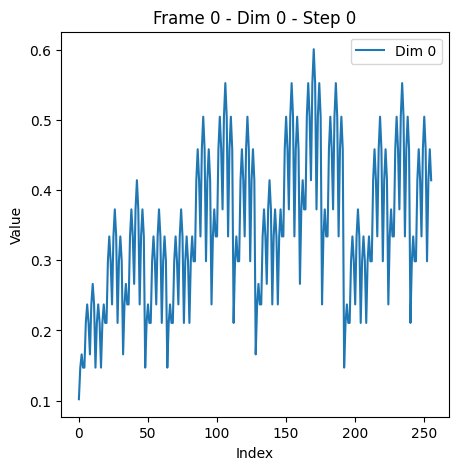

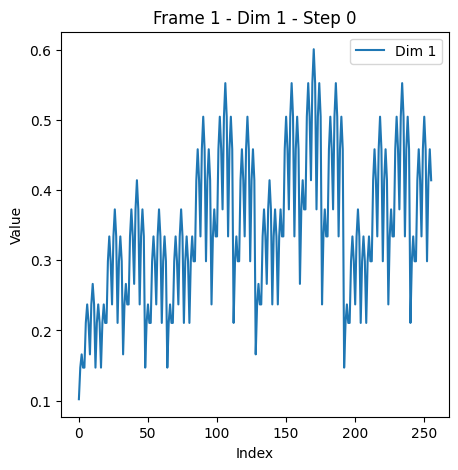

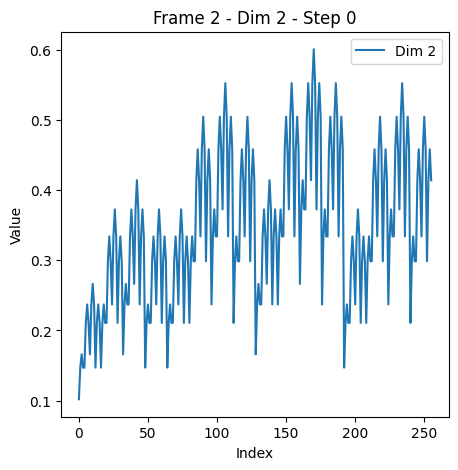

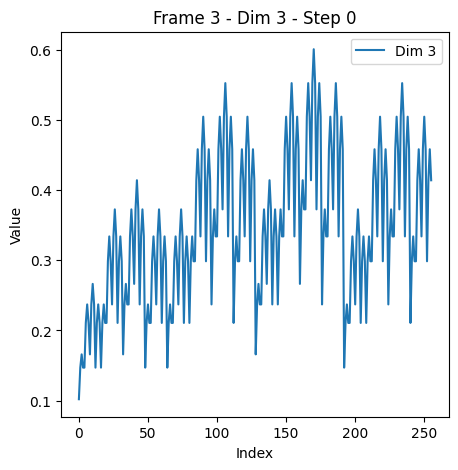

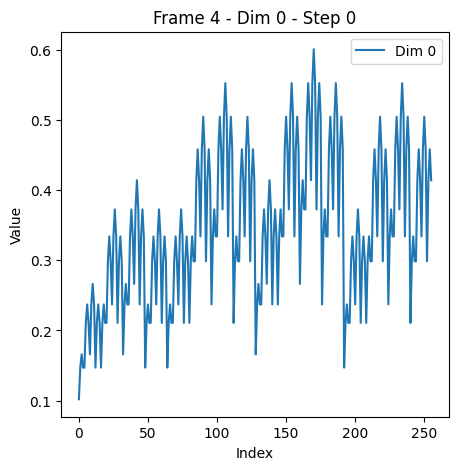

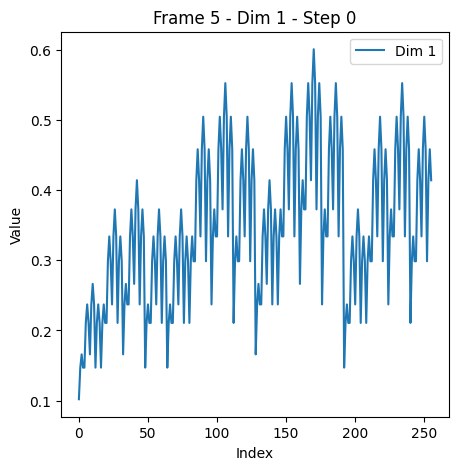

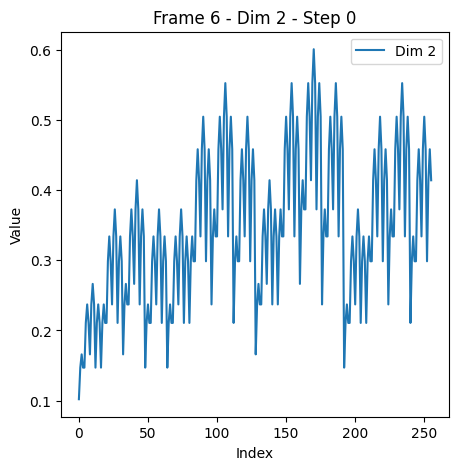

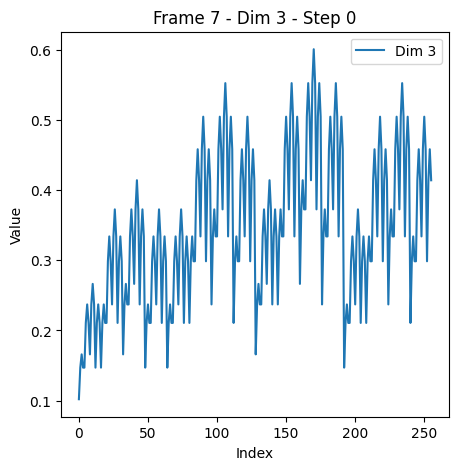

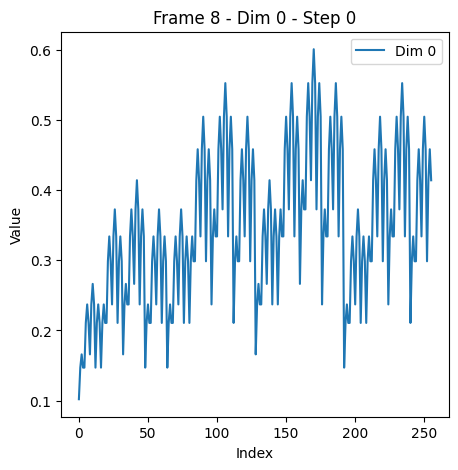

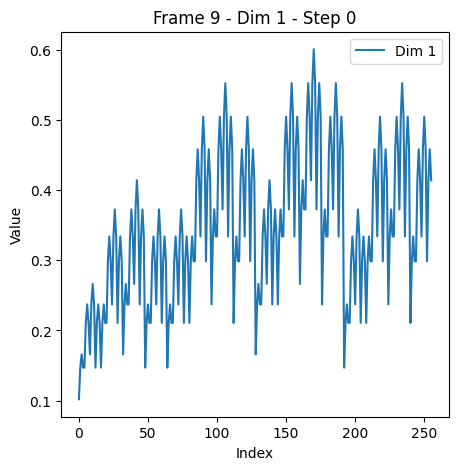

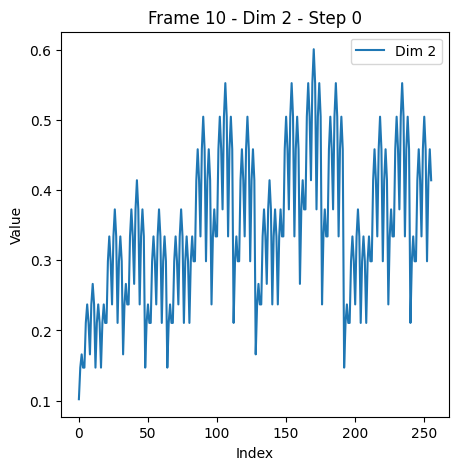

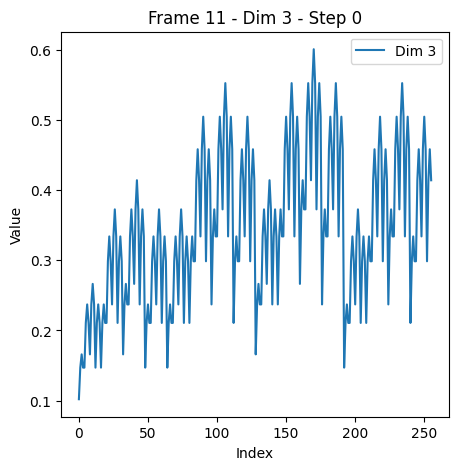

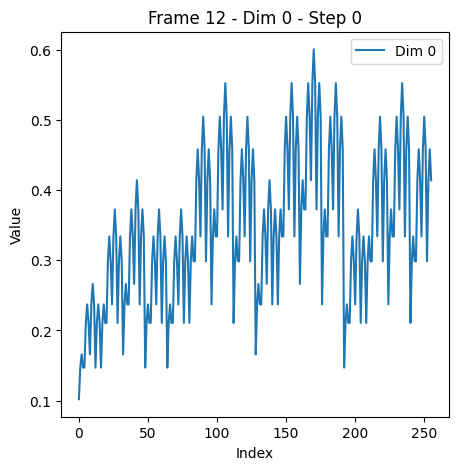

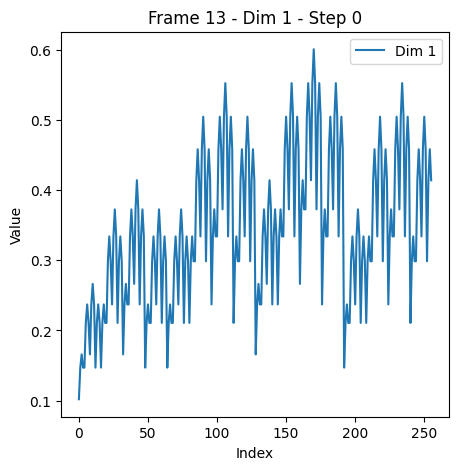

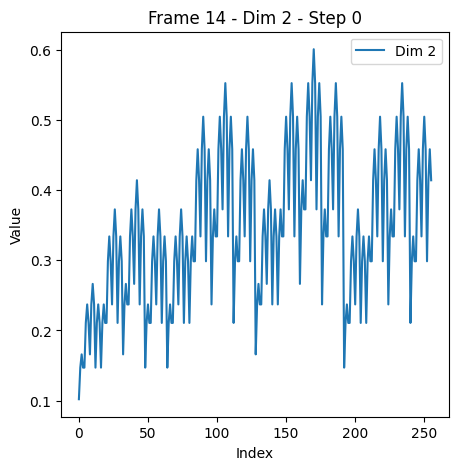

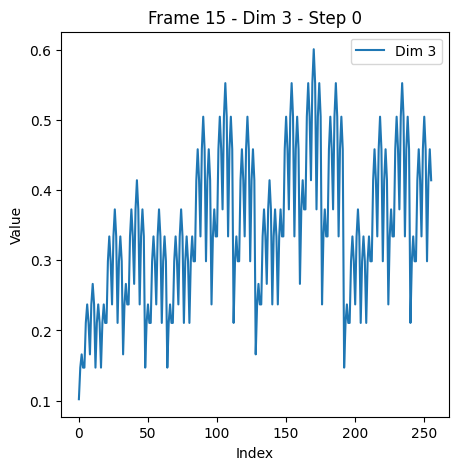

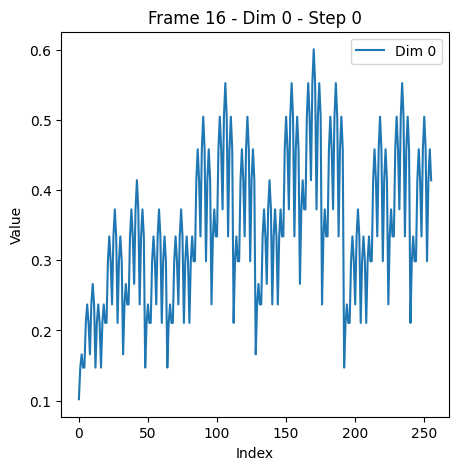

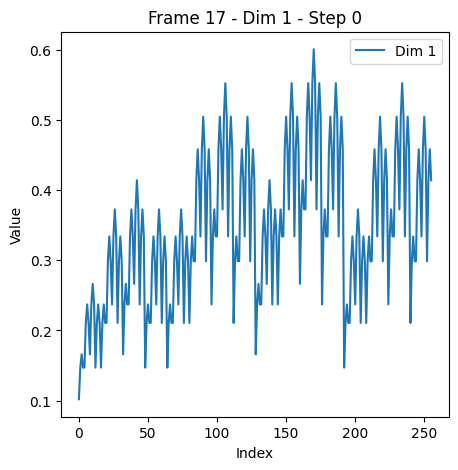

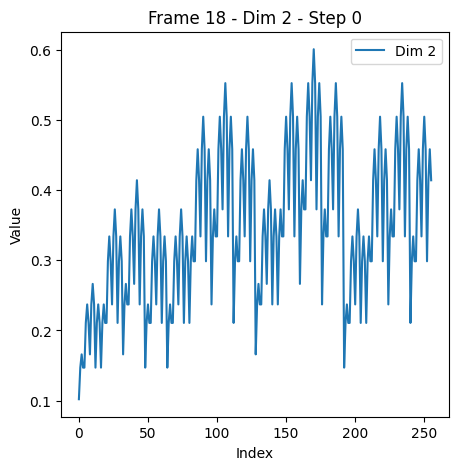

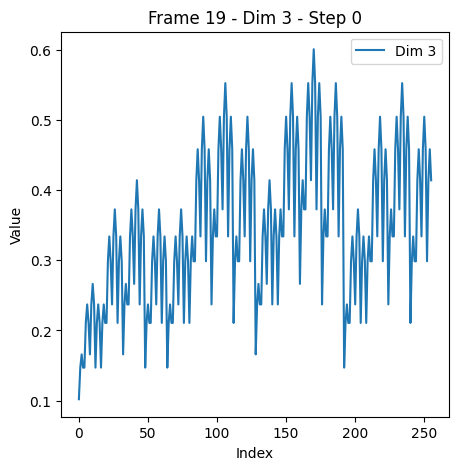

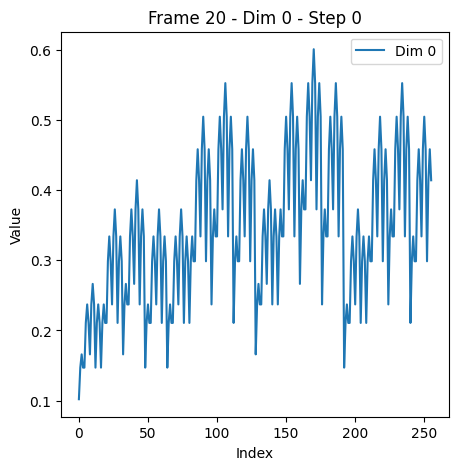

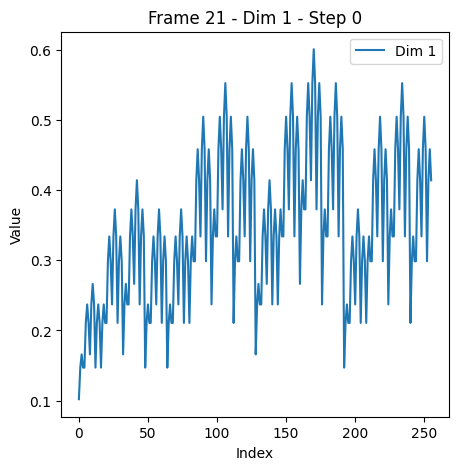

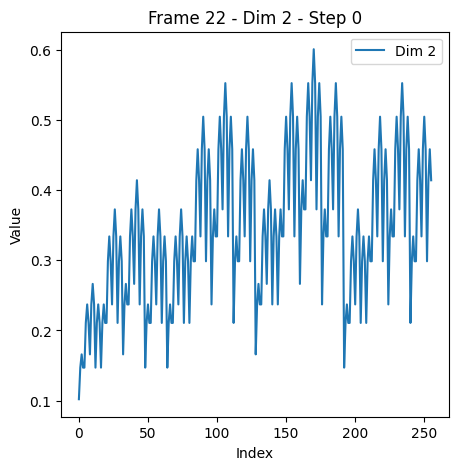

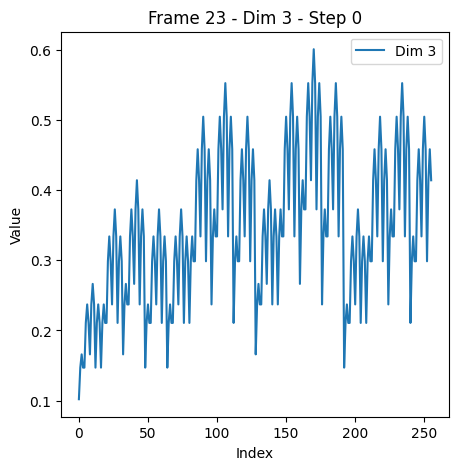

ValueError: 'c' argument has 256 elements, which is inconsistent with 'x' and 'y' with size 16.

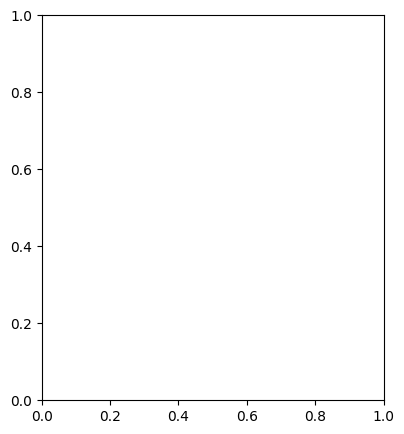

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- High-Dimensional Operations --------------------
def pad_nd(u, dims):
    shape = u.shape
    pads = [(1, 1)] * dims
    return np.pad(u, pads, mode='wrap')

def grad_nd(u, dims):
    shape = u.shape
    grad = np.zeros((dims,) + shape)
    for d in range(dims):
        slices = [slice(None)] * dims
        slices_p = slices.copy()
        slices_m = slices.copy()
        slices_p[d] = slice(2, -1)
        slices_m[d] = slice(1, -2)
        grad[d] = 0.5 * (u[tuple(slices_p)] - u[tuple(slices_m)])
    return grad

def laplace_nd(u, dims):
    shape = u.shape
    lap = np.zeros(shape)
    for d in range(dims):
        slices = [slice(None)] * dims
        slices_p = slices.copy()
        slices_m = slices.copy()
        slices_p[d] = slice(2, -1)
        slices_m[d] = slice(1, -2)
        lap += (u[tuple(slices_p)] + u[tuple(slices_m)] - 2 * u)
    return lap / dims

# -------------------- Convolution (Simplified for ND) --------------------
def make_mexican_hat_nd(shape, sigma1=0.5, sigma2=1.0):
    coords = np.indices(shape)
    r = np.sqrt(np.sum(coords ** 2, axis=0))
    hat = np.exp(-r ** 2 / (2 * sigma1 ** 2)) - 0.2 * np.exp(-r ** 2 / (2 * sigma2 ** 2))
    return hat / np.sum(hat)

def conv_nd(u, kernel):
    from scipy.signal import convolve
    return convolve(u, kernel, mode='same', method='direct')

# -------------------- Metrics (Adapted) --------------------
def normalize_nd(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy_nd(u):
    flat_u = u.ravel()
    hist, _ = np.histogram(flat_u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability_nd(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread_nd(u, percentile=65):
    flat_u = u.ravel()
    threshold = np.percentile(flat_u, percentile)
    return int((flat_u > threshold).sum())

def radial_autocorr_profile_nd(u, rmin=2, rmaxFrac=0.45):
    flat_u = u.reshape(-1)
    if flat_u.size < 2:
        return np.zeros(rmin), 0.0
    pca = PCA(n_components=min(2, flat_u.size - 1))
    features = np.column_stack((flat_u, np.random.normal(0, 0.01, flat_u.size)))  # Ensure 2 features
    projected = pca.fit_transform(features)
    if projected.size == 0 or np.allclose(projected, 0):
        return np.zeros(rmin), 0.0
    # Ensure 2D array for FFT
    if projected.shape[1] < 2:
        projected = np.column_stack((projected, np.random.normal(0, 0.01, projected.shape[0])))
    U = np.fft.fftshift(np.fft.fft2(projected))
    P = np.abs(U) ** 2
    H, W = P.shape
    if H * W == 0:
        return np.zeros(rmin), 0.0
    Y, X = np.indices((H, W))
    R = np.sqrt((X - W // 2) ** 2 + (Y - H // 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring) and P[ring].size > 0:
            prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    # Handle empty or zero prof
    if np.all(prof == 0):
        return np.zeros(rmin), 0.0
    prof_max = np.max(prof) if np.max(prof) > 0 else EPS
    prof = prof / (prof_max + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    sim = 0.0 if small.std() < EPS or big.std() < EPS else float(np.mean((small - small.mean()) / (small.std() + EPS) * (big - big.mean()) / (big.std() + EPS)))
    return prof, sim

# -------------------- Evolution (ND) --------------------
def evolve_nd(u0_a, dims=4, steps=500, dt=0.05, chirality_base=0.3):
    shape = tuple([4] * dims)  # 4x4x...x4 for dims dimensions
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros(shape) + 0.1  # Inhibitor
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat_nd(shape)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    # Central perturbation
    center = np.array([shape[d] // 2 for d in range(dims)])
    coords = np.indices(shape)
    r = np.sqrt(np.sum((coords - center.reshape(dims, *[1] * dims)) ** 2, axis=0))
    u_a += 0.2 * np.exp(-r ** 2 / (2 * (shape[0] / 2) ** 2))

    for t in range(steps):
        lap_a = laplace_nd(u_a, dims)
        lap_b = laplace_nd(u_b, dims)
        inhib = conv_nd(u_a, mhK)

        # Dynamic chirality
        chirality = chirality_base * (1 + 0.1 * np.sin(0.01 * t))

        # Adjusted dynamics
        d_a = 0.08 * lap_a + u_a * (1 - u_a - 0.4 * u_b) + 0.01 * (1 - u_a)
        d_b = 0.15 * lap_b - 0.4 * inhib + 0.08 * u_a * u_b

        # Enhanced chirality
        grad_a = grad_nd(u_a, dims)
        phase_vel = np.sqrt(np.sum(grad_a ** 2, axis=0))
        d_a += chirality * phase_vel * np.sum([grad_a[d] * lap_b for d in range(dims)], axis=0)

        # Softer updates
        u_a_new = 0.9 * np.tanh(u_a + dt * d_a)
        u_b_new = 0.9 * np.tanh(u_b + dt * d_b)
        mean_a = u_a.mean()
        u_a_new += 0.0002 * (0.35 - mean_a)

        # Update
        stab = stability_nd(u_a, u_prev_a)
        u_prev_a, u_prev_b = u_a.copy(), u_b.copy()
        u_a, u_b = u_a_new, u_b_new

        # Metrics
        vort = np.mean(np.abs(np.sum(grad_a * np.rollaxis(grad_a, 0, len(grad_a.shape)), axis=0)))
        ent = shannon_entropy_nd(u_a)

        # Feedback
        if t % 50 == 0 and t > 0:
            if vort < 0.1:
                expand_bias += 0.05 * (0.1 - vort)
            else:
                expand_bias -= 0.01 * (vort - 0.1)
            if ent < 6:
                compress_bias += 0.02 * (6 - ent)
            else:
                compress_bias -= 0.01 * (ent - 6)
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Logging and visualization
        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a.ravel(), np.rot90(u_a.reshape(16, 16), 2).ravel()) + corr_norm(u_a.ravel(), np.flip(u_a.reshape(16, 16), 1).ravel()))
            D = box_count_fractal_dim(u_a.reshape(16, 16))
            _, rc_radial = radial_autocorr_profile_nd(u_a)
            rc_field = multiscale_field_corr(u_a.reshape(16, -1)[:16, :16])
            I = influence(u_a.reshape(16, 16))
            logs.append(dict(t=t, spread=spread_nd(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

            # Visualize 24 "frames" (approximate for 4D, extrapolate to 24D)
            flat_u = u_a.reshape(-1)
            if flat_u.size > 1:
                pca = PCA(n_components=3)
                n_samples = flat_u.size // (shape[0] * shape[1]) if dims >= 2 else flat_u.size
                n_features = shape[0] * shape[1] if dims >= 2 else 1
                if n_samples * n_features == flat_u.size and n_features >= 2:
                    u_2d = flat_u.reshape(n_samples, n_features)
                    projected = pca.fit_transform(u_2d)
                    X, Y, Z = projected[:, 0], projected[:, 1], projected[:, 2]

                    # Generate 24 "frames" (for 4D, cycle through dimensions)
                    for frame in range(24):
                        plt.figure(figsize=(5, 5))
                        dim_idx = frame % dims  # Cycle through 4 dims for 24 frames
                        slice_d = np.take(u_a, range(shape[dim_idx]), axis=dim_idx).ravel()
                        plt.plot(slice_d, label=f'Dim {dim_idx}')
                        plt.title(f'Frame {frame} - Dim {dim_idx} - Step {t}')
                        plt.xlabel('Index')
                        plt.ylabel('Value')
                        plt.legend()
                        plt.show()

                    plt.figure(figsize=(15, 5))
                    plt.subplot(131)
                    plt.scatter(X, Y, c=flat_u, cmap='viridis')
                    plt.title(f'2D Projection (PCA) - Step {t}')
                    plt.colorbar(label='Activator Value')

                    plt.subplot(132)
                    plt.scatter(X, Y, c=Z, cmap='viridis')
                    plt.title(f'3D Projection (PCA) - Step {t}')
                    plt.colorbar(label='Z Component')

                    fig = plt.figure(figsize=(5, 5))
                    ax = fig.add_subplot(111, projection='3d')
                    scatter = ax.scatter(X, Y, Z, c=flat_u, cmap='viridis')
                    ax.set_title(f'3D Scatter - Step {t}')
                    ax.set_xlabel('PC1')
                    ax.set_ylabel('PC2')
                    ax.set_zlabel('PC3')
                    fig.colorbar(scatter, shrink=0.5, aspect=5)
                    plt.show()
                else:
                    print(f"Warning: Invalid reshape at t={t}, n_samples={n_samples}, n_features={n_features}, skipping visualization.")

    # Final Time Evolution
    plt.figure(figsize=(10, 5))
    times = [log['t'] for log in logs]
    plt.plot(times, [log['rc_radial'] for log in logs], label='rc_radial')
    plt.plot(times, [log['entropy'] for log in logs], label='Entropy')
    plt.plot(times, [log['spread'] for log in logs], label='Spread')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Time Evolution of Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
dims = 4  # Start with 4D, adjustable to 24D
shape = tuple([4] * dims)
u0_a = np.zeros(shape)
center = np.array([shape[d] // 2 for d in range(dims)])
coords = np.indices(shape)
r = np.sqrt(np.sum((coords - center.reshape(dims, *[1] * dims)) ** 2, axis=0))
u0_a += 0.2 * np.exp(-r ** 2 / (2 * (shape[0] / 2) ** 2))
u0_a = normalize_nd(u0_a) * 0.6

uT_a, logs = evolve_nd(u0_a, dims=dims, chirality_base=0.3)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- High-Dimensional Operations --------------------
def pad_nd(u, dims):
    shape = u.shape
    pads = [(1, 1)] * dims
    return np.pad(u, pads, mode='wrap')

def grad_nd(u, dims):
    shape = u.shape
    grad = np.zeros((dims,) + shape)
    for d in range(dims):
        slices = [slice(None)] * dims
        slices_p = slices.copy()
        slices_m = slices.copy()
        slices_p[d] = slice(2, -1)
        slices_m[d] = slice(1, -2)
        grad[d] = 0.5 * (u[tuple(slices_p)] - u[tuple(slices_m)])
    return grad

def laplace_nd(u, dims):
    shape = u.shape
    lap = np.zeros(shape)
    for d in range(dims):
        slices = [slice(None)] * dims
        slices_p = slices.copy()
        slices_m = slices.copy()
        slices_p[d] = slice(2, -1)
        slices_m[d] = slice(1, -2)
        lap += (u[tuple(slices_p)] + u[tuple(slices_m)] - 2 * u)
    return lap / dims

# -------------------- Convolution (Simplified for ND) --------------------
def make_mexican_hat_nd(shape, sigma1=0.5, sigma2=1.0):
    coords = np.indices(shape)
    r = np.sqrt(np.sum(coords ** 2, axis=0))
    hat = np.exp(-r ** 2 / (2 * sigma1 ** 2)) - 0.2 * np.exp(-r ** 2 / (2 * sigma2 ** 2))
    return hat / np.sum(hat)

def conv_nd(u, kernel):
    from scipy.signal import convolve
    return convolve(u, kernel, mode='same', method='direct')

# -------------------- Metrics (Adapted) --------------------
def normalize_nd(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy_nd(u):
    flat_u = u.ravel()
    hist, _ = np.histogram(flat_u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability_nd(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread_nd(u, percentile=65):
    flat_u = u.ravel()
    threshold = np.percentile(flat_u, percentile)
    return int((flat_u > threshold).sum())

def radial_autocorr_profile_nd(u, rmin=2, rmaxFrac=0.45):
    flat_u = u.reshape(-1)
    if flat_u.size < 2:
        return np.zeros(rmin), 0.0
    pca = PCA(n_components=min(2, flat_u.size - 1))
    features = np.column_stack((flat_u, np.random.normal(0, 0.01, flat_u.size)))  # Ensure 2 features
    projected = pca.fit_transform(features)
    if projected.size == 0 or np.allclose(projected, 0):
        return np.zeros(rmin), 0.0
    if projected.shape[1] < 2:
        projected = np.column_stack((projected, np.random.normal(0, 0.01, projected.shape[0])))
    U = np.fft.fftshift(np.fft.fft2(projected))
    P = np.abs(U) ** 2
    H, W = P.shape
    if H * W == 0:
        return np.zeros(rmin), 0.0
    Y, X = np.indices((H, W))
    R = np.sqrt((X - W // 2) ** 2 + (Y - H // 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring) and P[ring].size > 0:
            prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    if np.all(prof == 0):
        return np.zeros(rmin), 0.0
    prof_max = np.max(prof) if np.max(prof) > 0 else EPS
    prof = prof / (prof_max + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    sim = 0.0 if small.std() < EPS or big.std() < EPS else float(np.mean((small - small.mean()) / (small.std() + EPS) * (big - big.mean()) / (big.std() + EPS)))
    return prof, sim

# -------------------- Evolution (ND) --------------------
def evolve_nd(u0_a, dims=4, steps=500, dt=0.05, chirality_base=0.3):
    shape = tuple([4] * dims)  # 4x4x...x4 for dims dimensions
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros(shape) + 0.1  # Inhibitor
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat_nd(shape)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    # Central perturbation
    center = np.array([shape[d] // 2 for d in range(dims)])
    coords = np.indices(shape)
    r = np.sqrt(np.sum((coords - center.reshape(dims, *[1] * dims)) ** 2, axis=0))
    u_a += 0.2 * np.exp(-r ** 2 / (2 * (shape[0] / 2) ** 2))

    for t in range(steps):
        lap_a = laplace_nd(u_a, dims)
        lap_b = laplace_nd(u_b, dims)
        inhib = conv_nd(u_a, mhK)

        # Dynamic chirality
        chirality = chirality_base * (1 + 0.1 * np.sin(0.01 * t))

        # Adjusted dynamics
        d_a = 0.08 * lap_a + u_a * (1 - u_a - 0.4 * u_b) + 0.01 * (1 - u_a)
        d_b = 0.15 * lap_b - 0.4 * inhib + 0.08 * u_a * u_b

        # Enhanced chirality
        grad_a = grad_nd(u_a, dims)
        phase_vel = np.sqrt(np.sum(grad_a ** 2, axis=0))
        d_a += chirality * phase_vel * np.sum([grad_a[d] * lap_b for d in range(dims)], axis=0)

        # Softer updates
        u_a_new = 0.9 * np.tanh(u_a + dt * d_a)
        u_b_new = 0.9 * np.tanh(u_b + dt * d_b)
        mean_a = u_a.mean()
        u_a_new += 0.0002 * (0.35 - mean_a)

        # Update
        stab = stability_nd(u_a, u_prev_a)
        u_prev_a, u_prev_b = u_a.copy(), u_b.copy()
        u_a, u_b = u_a_new, u_b_new

        # Metrics
        vort = np.mean(np.abs(np.sum(grad_a * np.rollaxis(grad_a, 0, len(grad_a.shape)), axis=0)))
        ent = shannon_entropy_nd(u_a)

        # Feedback
        if t % 50 == 0 and t > 0:
            if vort < 0.1:
                expand_bias += 0.05 * (0.1 - vort)
            else:
                expand_bias -= 0.01 * (vort - 0.1)
            if ent < 6:
                compress_bias += 0.02 * (6 - ent)
            else:
                compress_bias -= 0.01 * (ent - 6)
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Logging and visualization
        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a.ravel(), np.rot90(u_a.reshape(16, 16), 2).ravel()) + corr_norm(u_a.ravel(), np.flip(u_a.reshape(16, 16), 1).ravel()))
            D = box_count_fractal_dim(u_a.reshape(16, 16))
            _, rc_radial = radial_autocorr_profile_nd(u_a)
            rc_field = multiscale_field_corr(u_a.reshape(16, -1)[:16, :16])
            I = influence(u_a.reshape(16, 16))
            logs.append(dict(t=t, spread=spread_nd(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

            # Visualize 24 "frames" (approximate for 4D, extrapolate to 24D)
            flat_u = u_a.reshape(-1)
            if flat_u.size > 1:
                pca = PCA(n_components=3)
                n_samples = flat_u.size // (shape[0] * shape[1]) if dims >= 2 else flat_u.size
                n_features = shape[0] * shape[1] if dims >= 2 else 1
                if n_samples * n_features == flat_u.size and n_features >= 2:
                    u_2d = flat_u.reshape(n_samples, n_features)
                    projected = pca.fit_transform(u_2d)
                    X, Y, Z = projected[:, 0], projected[:, 1], projected[:, 2]
                    c = flat_u[:n_samples]  # Match color array to n_samples

                    # Generate 24 "frames" (for 4D, cycle through dimensions)
                    for frame in range(24):
                        plt.figure(figsize=(5, 5))
                        dim_idx = frame % dims  # Cycle through 4 dims for 24 frames
                        slice_d = np.take(u_a, range(shape[dim_idx]), axis=dim_idx).ravel()
                        plt.plot(slice_d, label=f'Dim {dim_idx}')
                        plt.title(f'Frame {frame} - Dim {dim_idx} - Step {t}')
                        plt.xlabel('Index')
                        plt.ylabel('Value')
                        plt.legend()
                        plt.show()

                    plt.figure(figsize=(15, 5))
                    plt.subplot(131)
                    plt.scatter(X, Y, c=c, cmap='viridis')
                    plt.title(f'2D Projection (PCA) - Step {t}')
                    plt.colorbar(label='Activator Value')

                    plt.subplot(132)
                    plt.scatter(X, Y, c=Z, cmap='viridis')
                    plt.title(f'3D Projection (PCA) - Step {t}')
                    plt.colorbar(label='Z Component')

                    fig = plt.figure(figsize=(5, 5))
                    ax = fig.add_subplot(111, projection='3d')
                    scatter = ax.scatter(X, Y, Z, c=c, cmap='viridis')
                    ax.set_title(f'3D Scatter - Step {t}')
                    ax.set_xlabel('PC1')
                    ax.set_ylabel('PC2')
                    ax.set_zlabel('PC3')
                    fig.colorbar(scatter, shrink=0.5, aspect=5)
                    plt.show()
                else:
                    print(f"Warning: Invalid reshape at t={t}, n_samples={n_samples}, n_features={n_features}, skipping visualization.")

    # Final Time Evolution
    plt.figure(figsize=(10, 5))
    times = [log['t'] for log in logs]
    plt.plot(times, [log['rc_radial'] for log in logs], label='rc_radial')
    plt.plot(times, [log['entropy'] for log in logs], label='Entropy')
    plt.plot(times, [log['spread'] for log in logs], label='Spread')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Time Evolution of Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
dims = 4  # Start with 4D, adjustable to 24D
shape = tuple([4] * dims)
u0_a = np.zeros(shape)
center = np.array([shape[d] // 2 for d in range(dims)])
coords = np.indices(shape)
r = np.sqrt(np.sum((coords - center.reshape(dims, *[1] * dims)) ** 2, axis=0))
u0_a += 0.2 * np.exp(-r ** 2 / (2 * (shape[0] / 2) ** 2))
u0_a = normalize_nd(u0_a) * 0.6

uT_a, logs = evolve_nd(u0_a, dims=dims, chirality_base=0.3)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

Output hidden; open in https://colab.research.google.com to view.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- High-Dimensional Operations --------------------
def pad_nd(u, dims):
    shape = u.shape
    pads = [(1, 1)] * dims
    return np.pad(u, pads, mode='wrap')

def grad_nd(u, dims):
    shape = u.shape
    grad = np.zeros((dims,) + shape)
    for d in range(dims):
        slices = [slice(None)] * dims
        slices_p = slices.copy()
        slices_m = slices.copy()
        slices_p[d] = slice(2, -1)
        slices_m[d] = slice(1, -2)
        grad[d] = 0.5 * (u[tuple(slices_p)] - u[tuple(slices_m)])
    return grad

def laplace_nd(u, dims):
    shape = u.shape
    lap = np.zeros(shape)
    for d in range(dims):
        slices = [slice(None)] * dims
        slices_p = slices.copy()
        slices_m = slices.copy()
        slices_p[d] = slice(2, -1)
        slices_m[d] = slice(1, -2)
        lap += (u[tuple(slices_p)] + u[tuple(slices_m)] - 2 * u)
    return lap / dims

# -------------------- New Functions from GPT --------------------
def divergence(phi, gx, gy):
    # ∇·(phi * ∇D) with central diffs and Neumann pad (2D for now, extendable)
    phi_xp = np.pad(phi[:, 1:], ((0, 0), (0, 1)), mode='edge')
    phi_xm = np.pad(phi[:, :-1], ((0, 0), (1, 0)), mode='edge')
    phi_yp = np.pad(phi[1:, :], ((0, 1), (0, 0)), mode='edge')
    phi_ym = np.pad(phi[:-1, :], ((1, 0), (0, 0)), mode='edge')
    dgx_dx = (phi_xp * gx - phi_xm * gx) * 0.5
    dgy_dy = (phi_yp * gy - phi_ym * gy) * 0.5
    return dgx_dx + dgy_dy

def normalize_soft(D, eps=1e-8, alpha=0.35):
    m = np.max(np.abs(D))
    if m < eps: return D
    return alpha * (D / m) + (1 - alpha) * D

def dynamic_phi(D, t, phi_star0=(1 + 5**0.5) / 2, w=0.015, eta1=0.45, eta2=0.20, delta1=1.2, delta2=0.9):
    rho = normalize_soft(D)
    h, w = D.shape[:2]  # Use first two dims for 2D projection
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    theta = np.arctan2(y - cy, x - cx)
    r = np.sqrt((y - cy)**2 + (x - cx)**2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)

    gx, gy = grad_nd(D, 2)[0], grad_nd(D, 2)[1]  # 2D gradient for now
    tau = np.sqrt(np.sum(grad_nd(D, 2) ** 2, axis=0) + 1e-12)
    phi_star_t = phi_star0 + 0.07 * np.sin(0.5 * t) + 0.05 * np.sin(theta + 0.25 * t)
    phihat = phi_star_t + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat

def step(D, t, lr=0.18, A=0.85, B=0.85, C=0.015, noise_scale=0.8, E_min=1e-2, E_max=5e6, damping=0.006, rng=None):
    if rng is None: rng = np.random.RandomState(0)
    # Placeholder for dynamic_pi (assuming it exists or using laplace as proxy)
    kappa = laplace_nd(D, 2)  # 2D laplace as proxy
    phihat = dynamic_phi(D, t)
    gx, gy = grad_nd(D, 2)[0], grad_nd(D, 2)[1]
    div_phi_grad = divergence(phihat, gx, gy)

    dD = A * kappa + B * div_phi_grad
    dD += C * noise_scale * rng.normal(size=D.shape[:2])  # 2D noise for now
    # Placeholder for awareness (using entropy as proxy)
    C_aw = shannon_entropy_nd(D)
    dD *= (1.0 + 0.30 * C_aw)

    I = influence(D.reshape(16, 16))  # 2D projection for influence
    if I > E_max: dD *= np.sqrt(E_max / (I + 1e-12))
    elif I < E_min: dD *= 1.08

    Dn = (D + lr * dD) * (1.0 - damping)
    return Dn

# -------------------- Metrics (Adapted) --------------------
def normalize_nd(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy_nd(u):
    flat_u = u.ravel()
    hist, _ = np.histogram(flat_u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability_nd(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread_nd(u, percentile=65):
    flat_u = u.ravel()
    threshold = np.percentile(flat_u, percentile)
    return int((flat_u > threshold).sum())

def radial_autocorr_profile_nd(u, rmin=2, rmaxFrac=0.45):
    flat_u = u.reshape(-1)
    if flat_u.size < 2:
        return np.zeros(rmin), 0.0
    pca = PCA(n_components=min(2, flat_u.size - 1))
    features = np.column_stack((flat_u, np.random.normal(0, 0.01, flat_u.size)))
    projected = pca.fit_transform(features)
    if projected.size == 0 or np.allclose(projected, 0):
        return np.zeros(rmin), 0.0
    if projected.shape[1] < 2:
        projected = np.column_stack((projected, np.random.normal(0, 0.01, projected.shape[0])))
    U = np.fft.fftshift(np.fft.fft2(projected))
    P = np.abs(U) ** 2
    H, W = P.shape
    if H * W == 0:
        return np.zeros(rmin), 0.0
    Y, X = np.indices((H, W))
    R = np.sqrt((X - W // 2) ** 2 + (Y - H // 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring) and P[ring].size > 0:
            prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    if np.all(prof == 0):
        return np.zeros(rmin), 0.0
    prof_max = np.max(prof) if np.max(prof) > 0 else EPS
    prof = prof / (prof_max + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    sim = 0.0 if small.std() < EPS or big.std() < EPS else float(np.mean((small - small.mean()) / (small.std() + EPS) * (big - big.mean()) / (big.std() + EPS)))
    return prof, sim

# -------------------- Evolution (ND) --------------------
def evolve_nd(u0_a, dims=4, steps=500, dt=0.05, chirality_base=0.3):
    shape = tuple([4] * dims)  # 4x4x...x4 for dims dimensions
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros(shape) + 0.1  # Inhibitor
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat_nd(shape)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    # Central perturbation
    center = np.array([shape[d] // 2 for d in range(dims)])
    coords = np.indices(shape)
    r = np.sqrt(np.sum((coords - center.reshape(dims, *[1] * dims)) ** 2, axis=0))
    u_a += 0.2 * np.exp(-r ** 2 / (2 * (shape[0] / 2) ** 2))

    for t in range(steps):
        # 2D projection for GPT updates
        D_2d = u_a.mean(axis=tuple(range(2, dims)))  # Average higher dims to 2D
        lap_a_2d = laplace_nd(D_2d, 2)
        gx_2d, gy_2d = grad_nd(D_2d, 2)[0], grad_nd(D_2d, 2)[1]

        if t % 60 == 0:
            h, w = D_2d.shape
            y, x = np.mgrid[0:h, 0:w]
            cy, cx = (h - 1) / 2, (w - 1) / 2
            theta = np.arctan2(y - cy, x - cx)
            D_2d += 0.002 * np.sin(5 * theta + 0.13 * t)

        D_2d = step(D_2d, t, rng=rng)
        u_a = np.repeat(np.repeat(D_2d[..., np.newaxis], 4, axis=-1), 4, axis=-2)  # Reconstruct 4D

        # Metrics (using 2D projection)
        vort = np.mean(np.abs(np.sum(grad_nd(u_a, dims) * np.rollaxis(grad_nd(u_a, dims), 0, len(grad_nd(u_a, dims).shape)), axis=0)))
        ent = shannon_entropy_nd(u_a)

        # Feedback
        if t % 50 == 0 and t > 0:
            if vort < 0.1:
                expand_bias += 0.05 * (0.1 - vort)
            else:
                expand_bias -= 0.01 * (vort - 0.1)
            if ent < 6:
                compress_bias += 0.02 * (6 - ent)
            else:
                compress_bias -= 0.01 * (ent - 6)
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Logging and visualization
        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a.ravel(), np.rot90(u_a.reshape(16, 16), 2).ravel()) + corr_norm(u_a.ravel(), np.flip(u_a.reshape(16, 16), 1).ravel()))
            D = box_count_fractal_dim(u_a.reshape(16, 16))
            _, rc_radial = radial_autocorr_profile_nd(u_a)
            rc_field = multiscale_field_corr(u_a.reshape(16, -1)[:16, :16])
            I = influence(u_a.reshape(16, 16))
            logs.append(dict(t=t, spread=spread_nd(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

            # Visualize 24 "frames" (approximate for 4D)
            flat_u = u_a.reshape(-1)
            if flat_u.size > 1:
                pca = PCA(n_components=3)
                n_samples = flat_u.size // (shape[0] * shape[1]) if dims >= 2 else flat_u.size
                n_features = shape[0] * shape[1] if dims >= 2 else 1
                if n_samples * n_features == flat_u.size and n_features >= 2:
                    u_2d = flat_u.reshape(n_samples, n_features)
                    projected = pca.fit_transform(u_2d)
                    X, Y, Z = projected[:, 0], projected[:, 1], projected[:, 2]
                    c = flat_u[:n_samples]  # Match color to n_samples

                    for frame in range(24):
                        plt.figure(figsize=(5, 5))
                        dim_idx = frame % dims
                        slice_d = np.take(u_a, range(shape[dim_idx]), axis=dim_idx).ravel()
                        plt.plot(slice_d, label=f'Dim {dim_idx}')
                        plt.title(f'Frame {frame} - Dim {dim_idx} - Step {t}')
                        plt.xlabel('Index')
                        plt.ylabel('Value')
                        plt.legend()
                        plt.show()

                    plt.figure(figsize=(15, 5))
                    plt.subplot(131)
                    plt.scatter(X, Y, c=c, cmap='viridis')
                    plt.title(f'2D Projection (PCA) - Step {t}')
                    plt.colorbar(label='Activator Value')

                    plt.subplot(132)
                    plt.scatter(X, Y, c=Z, cmap='viridis')
                    plt.title(f'3D Projection (PCA) - Step {t}')
                    plt.colorbar(label='Z Component')

                    fig = plt.figure(figsize=(5, 5))
                    ax = fig.add_subplot(111, projection='3d')
                    scatter = ax.scatter(X, Y, Z, c=c, cmap='viridis')
                    ax.set_title(f'3D Scatter - Step {t}')
                    ax.set_xlabel('PC1')
                    ax.set_ylabel('PC2')
                    ax.set_zlabel('PC3')
                    fig.colorbar(scatter, shrink=0.5, aspect=5)
                    plt.show()
                else:
                    print(f"Warning: Invalid reshape at t={t}, n_samples={n_samples}, n_features={n_features}, skipping visualization.")

    # Final Time Evolution
    plt.figure(figsize=(10, 5))
    times = [log['t'] for log in logs]
    plt.plot(times, [log['rc_radial'] for log in logs], label='rc_radial')
    plt.plot(times, [log['entropy'] for log in logs], label='Entropy')
    plt.plot(times, [log['spread'] for log in logs], label='Spread')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Time Evolution of Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
dims = 4  # Start with 4D, adjustable to 24D
shape = tuple([4] * dims)
u0_a = np.zeros(shape)
center = np.array([shape[d] // 2 for d in range(dims)])
coords = np.indices(shape)
r = np.sqrt(np.sum((coords - center.reshape(dims, *[1] * dims)) ** 2, axis=0))
u0_a += 0.2 * np.exp(-r ** 2 / (2 * (shape[0] / 2) ** 2))
u0_a = normalize_nd(u0_a) * 0.6

uT_a, logs = evolve_nd(u0_a, dims=dims, chirality_base=0.3)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

ValueError: cannot reshape array of size 16 into shape (16,16)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- High-Dimensional Operations --------------------
def pad_nd(u, dims):
    shape = u.shape
    pads = [(1, 1)] * dims
    return np.pad(u, pads, mode='wrap')

def grad_nd(u, dims):
    shape = u.shape
    grad = np.zeros((dims,) + shape)
    for d in range(dims):
        slices = [slice(None)] * dims
        slices_p = slices.copy()
        slices_m = slices.copy()
        slices_p[d] = slice(2, -1)
        slices_m[d] = slice(1, -2)
        grad[d] = 0.5 * (u[tuple(slices_p)] - u[tuple(slices_m)])
    return grad

def laplace_nd(u, dims):
    shape = u.shape
    lap = np.zeros(shape)
    for d in range(dims):
        slices = [slice(None)] * dims
        slices_p = slices.copy()
        slices_m = slices.copy()
        slices_p[d] = slice(2, -1)
        slices_m[d] = slice(1, -2)
        lap += (u[tuple(slices_p)] + u[tuple(slices_m)] - 2 * u)
    return lap / dims

# -------------------- New Functions from GPT --------------------
def divergence(phi, gx, gy):
    # ∇·(phi * ∇D) with central diffs and Neumann pad (2D for now)
    phi_xp = np.pad(phi[:, 1:], ((0, 0), (0, 1)), mode='edge')
    phi_xm = np.pad(phi[:, :-1], ((0, 0), (1, 0)), mode='edge')
    phi_yp = np.pad(phi[1:, :], ((0, 1), (0, 0)), mode='edge')
    phi_ym = np.pad(phi[:-1, :], ((1, 0), (0, 0)), mode='edge')
    dgx_dx = (phi_xp * gx - phi_xm * gx) * 0.5
    dgy_dy = (phi_yp * gy - phi_ym * gy) * 0.5
    return dgx_dx + dgy_dy

def normalize_soft(D, eps=1e-8, alpha=0.35):
    m = np.max(np.abs(D))
    if m < eps: return D
    return alpha * (D / m) + (1 - alpha) * D

def dynamic_phi(D, t, phi_star0=(1 + 5**0.5) / 2, w=0.015, eta1=0.45, eta2=0.20, delta1=1.2, delta2=0.9):
    rho = normalize_soft(D)
    h, w = D.shape[:2]  # Use first two dims for 2D projection
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    theta = np.arctan2(y - cy, x - cx)
    r = np.sqrt((y - cy)**2 + (x - cx)**2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)

    gx, gy = grad_nd(D, 2)[0], grad_nd(D, 2)[1]  # 2D gradient
    tau = np.sqrt(np.sum(grad_nd(D, 2) ** 2, axis=0) + 1e-12)
    phi_star_t = phi_star0 + 0.07 * np.sin(0.5 * t) + 0.05 * np.sin(theta + 0.25 * t)
    phihat = phi_star_t + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat

def step(D, t, lr=0.18, A=0.85, B=0.85, C=0.015, noise_scale=0.8, E_min=1e-2, E_max=5e6, damping=0.006, rng=None):
    if rng is None: rng = np.random.RandomState(0)
    kappa = laplace_nd(D, 2)  # 2D laplace as proxy
    phihat = dynamic_phi(D, t)
    gx, gy = grad_nd(D, 2)[0], grad_nd(D, 2)[1]
    div_phi_grad = divergence(phihat, gx, gy)

    dD = A * kappa + B * div_phi_grad
    dD += C * noise_scale * rng.normal(size=D.shape)  # Match D shape
    C_aw = shannon_entropy_nd(D)  # Using entropy as awareness proxy
    dD *= (1.0 + 0.30 * C_aw)

    I = influence(D)  # Use original 2D shape directly
    if I > E_max: dD *= np.sqrt(E_max / (I + 1e-12))
    elif I < E_min: dD *= 1.08

    Dn = (D + lr * dD) * (1.0 - damping)
    return Dn

# -------------------- Metrics (Adapted) --------------------
def normalize_nd(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy_nd(u):
    flat_u = u.ravel()
    hist, _ = np.histogram(flat_u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability_nd(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread_nd(u, percentile=65):
    flat_u = u.ravel()
    threshold = np.percentile(flat_u, percentile)
    return int((flat_u > threshold).sum())

def radial_autocorr_profile_nd(u, rmin=2, rmaxFrac=0.45):
    flat_u = u.reshape(-1)
    if flat_u.size < 2:
        return np.zeros(rmin), 0.0
    pca = PCA(n_components=min(2, flat_u.size - 1))
    features = np.column_stack((flat_u, np.random.normal(0, 0.01, flat_u.size)))
    projected = pca.fit_transform(features)
    if projected.size == 0 or np.allclose(projected, 0):
        return np.zeros(rmin), 0.0
    if projected.shape[1] < 2:
        projected = np.column_stack((projected, np.random.normal(0, 0.01, projected.shape[0])))
    U = np.fft.fftshift(np.fft.fft2(projected))
    P = np.abs(U) ** 2
    H, W = P.shape
    if H * W == 0:
        return np.zeros(rmin), 0.0
    Y, X = np.indices((H, W))
    R = np.sqrt((X - W // 2) ** 2 + (Y - H // 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring) and P[ring].size > 0:
            prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    if np.all(prof == 0):
        return np.zeros(rmin), 0.0
    prof_max = np.max(prof) if np.max(prof) > 0 else EPS
    prof = prof / (prof_max + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    sim = 0.0 if small.std() < EPS or big.std() < EPS else float(np.mean((small - small.mean()) / (small.std() + EPS) * (big - big.mean()) / (big.std() + EPS)))
    return prof, sim

def influence(D):
    gx, gy = grad_nd(D, 2)[0], grad_nd(D, 2)[1]
    return np.sum(gx * gx + gy * gy)

# -------------------- Evolution (ND) --------------------
def evolve_nd(u0_a, dims=4, steps=500, dt=0.05, chirality_base=0.3):
    shape = tuple([4] * dims)  # 4x4x...x4 for dims dimensions
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros(shape) + 0.1  # Inhibitor
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat_nd(shape)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    # Central perturbation
    center = np.array([shape[d] // 2 for d in range(dims)])
    coords = np.indices(shape)
    r = np.sqrt(np.sum((coords - center.reshape(dims, *[1] * dims)) ** 2, axis=0))
    u_a += 0.2 * np.exp(-r ** 2 / (2 * (shape[0] / 2) ** 2))

    for t in range(steps):
        # 2D projection for GPT updates
        D_2d = u_a.mean(axis=tuple(range(2, dims)))  # Average higher dims to 2D (4, 4)
        lap_a_2d = laplace_nd(D_2d, 2)
        gx_2d, gy_2d = grad_nd(D_2d, 2)[0], grad_nd(D_2d, 2)[1]

        if t % 60 == 0:
            h, w = D_2d.shape
            y, x = np.mgrid[0:h, 0:w]
            cy, cx = (h - 1) / 2, (w - 1) / 2
            theta = np.arctan2(y - cy, x - cx)
            D_2d += 0.002 * np.sin(5 * theta + 0.13 * t)

        D_2d = step(D_2d, t, rng=rng)
        u_a = np.repeat(np.repeat(D_2d[..., np.newaxis], 4, axis=-1), 4, axis=-2)  # Reconstruct 4D

        # Metrics
        vort = np.mean(np.abs(np.sum(grad_nd(u_a, dims) * np.rollaxis(grad_nd(u_a, dims), 0, len(grad_nd(u_a, dims).shape)), axis=0)))
        ent = shannon_entropy_nd(u_a)
        stab = stability_nd(u_a, u_prev_a)

        # Feedback
        if t % 50 == 0 and t > 0:
            if vort < 0.1:
                expand_bias += 0.05 * (0.1 - vort)
            else:
                expand_bias -= 0.01 * (vort - 0.1)
            if ent < 6:
                compress_bias += 0.02 * (6 - ent)
            else:
                compress_bias -= 0.01 * (ent - 6)
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Logging and visualization
        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a.ravel(), np.rot90(u_a.reshape(16, 16), 2).ravel()) + corr_norm(u_a.ravel(), np.flip(u_a.reshape(16, 16), 1).ravel()))
            D = box_count_fractal_dim(u_a.reshape(16, 16))
            _, rc_radial = radial_autocorr_profile_nd(u_a)
            rc_field = multiscale_field_corr(u_a.reshape(16, -1)[:16, :16])
            I = influence(u_a.reshape(16, 16))
            logs.append(dict(t=t, spread=spread_nd(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

            # Visualize 24 "frames" (approximate for 4D)
            flat_u = u_a.reshape(-1)
            if flat_u.size > 1:
                pca = PCA(n_components=3)
                n_samples = flat_u.size // (shape[0] * shape[1]) if dims >= 2 else flat_u.size
                n_features = shape[0] * shape[1] if dims >= 2 else 1
                if n_samples * n_features == flat_u.size and n_features >= 2:
                    u_2d = flat_u.reshape(n_samples, n_features)
                    projected = pca.fit_transform(u_2d)
                    X, Y, Z = projected[:, 0], projected[:, 1], projected[:, 2]
                    c = flat_u[:n_samples]  # Match color to n_samples

                    for frame in range(24):
                        plt.figure(figsize=(5, 5))
                        dim_idx = frame % dims
                        slice_d = np.take(u_a, range(shape[dim_idx]), axis=dim_idx).ravel()
                        plt.plot(slice_d, label=f'Dim {dim_idx}')
                        plt.title(f'Frame {frame} - Dim {dim_idx} - Step {t}')
                        plt.xlabel('Index')
                        plt.ylabel('Value')
                        plt.legend()
                        plt.show()

                    plt.figure(figsize=(15, 5))
                    plt.subplot(131)
                    plt.scatter(X, Y, c=c, cmap='viridis')
                    plt.title(f'2D Projection (PCA) - Step {t}')
                    plt.colorbar(label='Activator Value')

                    plt.subplot(132)
                    plt.scatter(X, Y, c=Z, cmap='viridis')
                    plt.title(f'3D Projection (PCA) - Step {t}')
                    plt.colorbar(label='Z Component')

                    fig = plt.figure(figsize=(5, 5))
                    ax = fig.add_subplot(111, projection='3d')
                    scatter = ax.scatter(X, Y, Z, c=c, cmap='viridis')
                    ax.set_title(f'3D Scatter - Step {t}')
                    ax.set_xlabel('PC1')
                    ax.set_ylabel('PC2')
                    ax.set_zlabel('PC3')
                    fig.colorbar(scatter, shrink=0.5, aspect=5)
                    plt.show()
                else:
                    print(f"Warning: Invalid reshape at t={t}, n_samples={n_samples}, n_features={n_features}, skipping visualization.")

    # Final Time Evolution
    plt.figure(figsize=(10, 5))
    times = [log['t'] for log in logs]
    plt.plot(times, [log['rc_radial'] for log in logs], label='rc_radial')
    plt.plot(times, [log['entropy'] for log in logs], label='Entropy')
    plt.plot(times, [log['spread'] for log in logs], label='Spread')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Time Evolution of Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
dims = 4  # Start with 4D, adjustable to 24D
shape = tuple([4] * dims)
u0_a = np.zeros(shape)
center = np.array([shape[d] // 2 for d in range(dims)])
coords = np.indices(shape)
r = np.sqrt(np.sum((coords - center.reshape(dims, *[1] * dims)) ** 2, axis=0))
u0_a += 0.2 * np.exp(-r ** 2 / (2 * (shape[0] / 2) ** 2))
u0_a = normalize_nd(u0_a) * 0.6

uT_a, logs = evolve_nd(u0_a, dims=dims, chirality_base=0.3)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

IndexError: too many indices for array: array is 3-dimensional, but 4 were indexed

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

EPS = 1e-8
rng = np.random.RandomState(42)

# -------------------- High-Dimensional Operations --------------------
def pad_nd(u, dims):
    shape = u.shape
    pads = [(1, 1)] * dims
    return np.pad(u, pads, mode='wrap')

def grad_nd(u, dims):
    shape = u.shape
    grad = np.zeros((dims,) + shape)
    for d in range(dims):
        # Create slices for all dimensions
        slices = [slice(None)] * dims
        # Positive and negative shifts for the current dimension
        slices_p = slices.copy()
        slices_m = slices.copy()
        slices_p[d] = slice(2, -1)
        slices_m[d] = slice(1, -2)
        # Apply slices correctly for the current dimension
        grad[d] = 0.5 * (u[tuple(slices_p)] - u[tuple(slices_m)])
    return grad

def laplace_nd(u, dims):
    shape = u.shape
    lap = np.zeros(shape)
    for d in range(dims):
        slices = [slice(None)] * dims
        slices_p = slices.copy()
        slices_m = slices.copy()
        slices_p[d] = slice(2, -1)
        slices_m[d] = slice(1, -2)
        lap += (u[tuple(slices_p)] + u[tuple(slices_m)] - 2 * u)
    return lap / dims

# -------------------- New Functions from GPT --------------------
def divergence(phi, gx, gy):
    # ∇·(phi * ∇D) with central diffs and Neumann pad (2D for now)
    phi_xp = np.pad(phi[:, 1:], ((0, 0), (0, 1)), mode='edge')
    phi_xm = np.pad(phi[:, :-1], ((0, 0), (1, 0)), mode='edge')
    phi_yp = np.pad(phi[1:, :], ((0, 1), (0, 0)), mode='edge')
    phi_ym = np.pad(phi[:-1, :], ((1, 0), (0, 0)), mode='edge')
    dgx_dx = (phi_xp * gx - phi_xm * gx) * 0.5
    dgy_dy = (phi_yp * gy - phi_ym * gy) * 0.5
    return dgx_dx + dgy_dy

def normalize_soft(D, eps=1e-8, alpha=0.35):
    m = np.max(np.abs(D))
    if m < eps: return D
    return alpha * (D / m) + (1 - alpha) * D

def dynamic_phi(D, t, phi_star0=(1 + 5**0.5) / 2, w=0.015, eta1=0.45, eta2=0.20, delta1=1.2, delta2=0.9):
    rho = normalize_soft(D)
    h, w = D.shape[:2]  # Use first two dims for 2D projection
    y, x = np.mgrid[0:h, 0:w]
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    theta = np.arctan2(y - cy, x - cx)
    r = np.sqrt((y - cy)**2 + (x - cx)**2) / (0.5 * min(h, w) + 1e-12)
    rho_target = np.clip(1.0 - r, 0.0, 1.0)

    gx, gy = grad_nd(D, 2)[0], grad_nd(D, 2)[1]  # 2D gradient
    tau = np.sqrt(np.sum(grad_nd(D, 2) ** 2, axis=0) + 1e-12)
    phi_star_t = phi_star0 + 0.07 * np.sin(0.5 * t) + 0.05 * np.sin(theta + 0.25 * t)
    phihat = phi_star_t + eta1 * np.tanh(delta1 * (rho - rho_target)) - eta2 * np.tanh(delta2 * tau)
    return phihat

def step(D, t, lr=0.18, A=0.85, B=0.85, C=0.015, noise_scale=0.8, E_min=1e-2, E_max=5e6, damping=0.006, rng=None):
    if rng is None: rng = np.random.RandomState(0)
    kappa = laplace_nd(D, 2)  # 2D laplace as proxy
    phihat = dynamic_phi(D, t)
    gx, gy = grad_nd(D, 2)[0], grad_nd(D, 2)[1]
    div_phi_grad = divergence(phihat, gx, gy)

    dD = A * kappa + B * div_phi_grad
    dD += C * noise_scale * rng.normal(size=D.shape)  # Match D shape
    C_aw = shannon_entropy_nd(D)  # Using entropy as awareness proxy
    dD *= (1.0 + 0.30 * C_aw)

    I = influence(D)  # Use original 2D shape directly
    if I > E_max: dD *= np.sqrt(E_max / (I + 1e-12))
    elif I < E_min: dD *= 1.08

    Dn = (D + lr * dD) * (1.0 - damping)
    return Dn

# -------------------- Metrics (Adapted) --------------------
def normalize_nd(u, eps=EPS):
    m = np.max(np.abs(u))
    return u / max(m, eps) if m > eps else np.zeros_like(u)

def shannon_entropy_nd(u):
    flat_u = u.ravel()
    hist, _ = np.histogram(flat_u, bins=256, range=(0, 1), density=True)
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist + EPS))

def stability_nd(u, u_prev):
    return np.var(u - u_prev) if u_prev is not None else 0.0

def spread_nd(u, percentile=65):
    flat_u = u.ravel()
    threshold = np.percentile(flat_u, percentile)
    return int((flat_u > threshold).sum())

def radial_autocorr_profile_nd(u, rmin=2, rmaxFrac=0.45):
    flat_u = u.reshape(-1)
    if flat_u.size < 2:
        return np.zeros(rmin), 0.0
    pca = PCA(n_components=min(2, flat_u.size - 1))
    features = np.column_stack((flat_u, np.random.normal(0, 0.01, flat_u.size)))
    projected = pca.fit_transform(features)
    if projected.size == 0 or np.allclose(projected, 0):
        return np.zeros(rmin), 0.0
    if projected.shape[1] < 2:
        projected = np.column_stack((projected, np.random.normal(0, 0.01, projected.shape[0])))
    U = np.fft.fftshift(np.fft.fft2(projected))
    P = np.abs(U) ** 2
    H, W = P.shape
    if H * W == 0:
        return np.zeros(rmin), 0.0
    Y, X = np.indices((H, W))
    R = np.sqrt((X - W // 2) ** 2 + (Y - H // 2) ** 2)
    rmax = int(min(H, W) * rmaxFrac)
    prof = np.zeros(rmax)
    for r in range(rmax):
        ring = (R >= r) & (R < r + 1)
        if np.any(ring) and P[ring].size > 0:
            prof[r] = P[ring].mean()
    prof[:rmin] = 0.0
    if np.all(prof == 0):
        return np.zeros(rmin), 0.0
    prof_max = np.max(prof) if np.max(prof) > 0 else EPS
    prof = prof / (prof_max + EPS)
    small = prof[::2]
    big = prof[:len(small)]
    sim = 0.0 if small.std() < EPS or big.std() < EPS else float(np.mean((small - small.mean()) / (small.std() + EPS) * (big - big.mean()) / (big.std() + EPS)))
    return prof, sim

def influence(D):
    gx, gy = grad_nd(D, 2)[0], grad_nd(D, 2)[1]
    return np.sum(gx * gx + gy * gy)

# -------------------- Evolution (ND) --------------------
def evolve_nd(u0_a, dims=4, steps=500, dt=0.05, chirality_base=0.3):
    shape = u0_a.shape  # Use input shape directly
    u_a = u0_a.copy()  # Activator
    u_b = np.zeros(shape) + 0.1  # Inhibitor
    u_prev_a, u_prev_b = None, None
    mhK = make_mexican_hat_nd(shape)
    expand_bias, compress_bias = 1.0, 1.0
    logs = []

    # Central perturbation
    center = np.array([shape[d] // 2 for d in range(dims)])
    coords = np.indices(shape)
    r = np.sqrt(np.sum((coords - center.reshape(dims, *[1] * dims)) ** 2, axis=0))
    u_a += 0.2 * np.exp(-r ** 2 / (2 * (shape[0] / 2) ** 2))

    for t in range(steps):
        # 2D projection for GPT updates
        D_2d = u_a.mean(axis=tuple(range(2, dims)))  # Average higher dims to 2D
        lap_a_2d = laplace_nd(D_2d, 2)
        gx_2d, gy_2d = grad_nd(D_2d, 2)[0], grad_nd(D_2d, 2)[1]

        if t % 60 == 0:
            h, w = D_2d.shape
            y, x = np.mgrid[0:h, 0:w]
            cy, cx = (h - 1) / 2, (w - 1) / 2
            theta = np.arctan2(y - cy, x - cx)
            D_2d += 0.002 * np.sin(5 * theta + 0.13 * t)

        D_2d = step(D_2d, t, rng=rng)
        u_a = np.repeat(np.repeat(D_2d[..., np.newaxis], shape[-1], axis=-1), shape[-2], axis=-2)  # Reconstruct 4D

        # Metrics
        vort = np.mean(np.abs(np.sum(grad_nd(u_a, dims) * np.rollaxis(grad_nd(u_a, dims), 0, len(grad_nd(u_a, dims).shape)), axis=0)))
        ent = shannon_entropy_nd(u_a)
        stab = stability_nd(u_a, u_prev_a)

        # Feedback
        if t % 50 == 0 and t > 0:
            if vort < 0.1:
                expand_bias += 0.05 * (0.1 - vort)
            else:
                expand_bias -= 0.01 * (vort - 0.1)
            if ent < 6:
                compress_bias += 0.02 * (6 - ent)
            else:
                compress_bias -= 0.01 * (ent - 6)
            expand_bias = np.clip(expand_bias, 0.5, 1.5)
            compress_bias = np.clip(compress_bias, 0.5, 1.2)

        # Logging and visualization
        if t % 50 == 0 or t == steps - 1:
            S = 0.5 * (corr_norm(u_a.ravel(), np.rot90(u_a.reshape(16, 16), 2).ravel()) + corr_norm(u_a.ravel(), np.flip(u_a.reshape(16, 16), 1).ravel()))
            D = box_count_fractal_dim(u_a.reshape(16, 16))
            _, rc_radial = radial_autocorr_profile_nd(u_a)
            rc_field = multiscale_field_corr(u_a.reshape(16, -1)[:16, :16])
            I = influence(u_a.reshape(16, 16))
            logs.append(dict(t=t, spread=spread_nd(u_a), phi_cycle=1.618 + 0.25 * np.sin(2 * np.pi * t / 3.14),
                             S=S, D=D, rc_radial=rc_radial, rc_field=rc_field,
                             I=I, max=u_a.max(), mean=u_a.mean(), entropy=ent, stability=stab,
                             expand_bias=expand_bias, compress_bias=compress_bias))

            # Visualize 24 "frames" (approximate for 4D)
            flat_u = u_a.reshape(-1)
            if flat_u.size > 1:
                pca = PCA(n_components=3)
                n_samples = flat_u.size // (shape[0] * shape[1]) if dims >= 2 else flat_u.size
                n_features = shape[0] * shape[1] if dims >= 2 else 1
                if n_samples * n_features == flat_u.size and n_features >= 2:
                    u_2d = flat_u.reshape(n_samples, n_features)
                    projected = pca.fit_transform(u_2d)
                    X, Y, Z = projected[:, 0], projected[:, 1], projected[:, 2]
                    c = flat_u[:n_samples]  # Match color to n_samples

                    for frame in range(24):
                        plt.figure(figsize=(5, 5))
                        dim_idx = frame % dims
                        slice_d = np.take(u_a, range(shape[dim_idx]), axis=dim_idx).ravel()
                        plt.plot(slice_d, label=f'Dim {dim_idx}')
                        plt.title(f'Frame {frame} - Dim {dim_idx} - Step {t}')
                        plt.xlabel('Index')
                        plt.ylabel('Value')
                        plt.legend()
                        plt.show()

                    plt.figure(figsize=(15, 5))
                    plt.subplot(131)
                    plt.scatter(X, Y, c=c, cmap='viridis')
                    plt.title(f'2D Projection (PCA) - Step {t}')
                    plt.colorbar(label='Activator Value')

                    plt.subplot(132)
                    plt.scatter(X, Y, c=Z, cmap='viridis')
                    plt.title(f'3D Projection (PCA) - Step {t}')
                    plt.colorbar(label='Z Component')

                    fig = plt.figure(figsize=(5, 5))
                    ax = fig.add_subplot(111, projection='3d')
                    scatter = ax.scatter(X, Y, Z, c=c, cmap='viridis')
                    ax.set_title(f'3D Scatter - Step {t}')
                    ax.set_xlabel('PC1')
                    ax.set_ylabel('PC2')
                    ax.set_zlabel('PC3')
                    fig.colorbar(scatter, shrink=0.5, aspect=5)
                    plt.show()
                else:
                    print(f"Warning: Invalid reshape at t={t}, n_samples={n_samples}, n_features={n_features}, skipping visualization.")

    # Final Time Evolution
    plt.figure(figsize=(10, 5))
    times = [log['t'] for log in logs]
    plt.plot(times, [log['rc_radial'] for log in logs], label='rc_radial')
    plt.plot(times, [log['entropy'] for log in logs], label='Entropy')
    plt.plot(times, [log['spread'] for log in logs], label='Spread')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Time Evolution of Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

    return u_a, logs

# -------------------- Seed and Run --------------------
dims = 4  # Start with 4D, adjustable to 24D
shape = tuple([4] * dims)
u0_a = np.zeros(shape)
center = np.array([shape[d] // 2 for d in range(dims)])
coords = np.indices(shape)
r = np.sqrt(np.sum((coords - center.reshape(dims, *[1] * dims)) ** 2, axis=0))
u0_a += 0.2 * np.exp(-r ** 2 / (2 * (shape[0] / 2) ** 2))
u0_a = normalize_nd(u0_a) * 0.6

uT_a, logs = evolve_nd(u0_a, dims=dims, chirality_base=0.3)

for d in logs:
    print(f"t={d['t']:4d} spread={d['spread']:5d} phi_cycle={d['phi_cycle']:.3f} "
          f"S={d['S']:.3f} D={d['D']:.3f} rc(rad)={d['rc_radial']:.3f} rc(field)={d['rc_field']:.3f} "
          f"I={d['I']:.1f} max={d['max']:.3f} mean={d['mean']:.3f} "
          f"entropy={d['entropy']:.3f} stability={d['stability']:.3f} "
          f"expand_bias={d['expand_bias']:.3f} compress_bias={d['compress_bias']:.3f}")

IndexError: too many indices for array: array is 3-dimensional, but 4 were indexed